# Overview

## Description

This is a template notebook to tune up a single qubit using the LabOneQ workflow architecture. The following experiments are implemented:

I. Tune-up experiments:

1. [Resonator Spectroscopy](#resonator-spectroscopy)
2. [Qubit Spectroscopy](#qubit-spectroscopy)
3. [Amplitude Rabi](#amplitude-rabi-ge) ([2nd](#amplitude-rabi-ef))
4. [Amplitude Rabi Chevron](#amplitude-rabi-chevron-ge) ([2nd](#amplitude-rabi-chevron-ef))
5. [Rabi Chevron](#rabi-chevron-ge) ([2nd](#rabi-shevron-ef))
6. [Rabi Frequency Calibration](#rabi-frequency-calibration-ge) ([2nd](#rabi-frequency-calibration-ef))
7. [T1 Lifetime](#t1-lifetime-ge) ([2nd](#t1-lifetime-ef))
8. [Ramsey](#ramsey-ge) ([2nd](#ramsey-ef))
9. [Rabi Error Amplification](#rabi-error-amplification-ge) ([2nd](#rabi-error-amplification-ef))
10. [DRAG Calibration](#drag-calibration-ge) ([2nd](#drag-calibration-ef))
11. [Hahn-Echo](#hahn-echo-ge) ([2nd](#hahn-echo-ef))
12. [Readout Optimisation](#readout-optimisation)

II. Population and temperature measurements:

13. [Single Shot 0 & 1 Measurements](#single-shot-0-and-1-measurements)
14. [Population Measurements](#population-measurements)

III. Extra:

15. [Fast Flux Drive](#fast-flux-drive)
16. [SINIS Calibration, Statistic and Temperature Sweep Measurements](#sinis-calibration)

## Changelog

All changes must be logged here! Do not make changes to this notebook other than expanding or modifying the standard experiments in a meaningful! All device-specific parameters and measurements have to be done in a different notebook!

Stick to semantic versioning:
- **Last Digit**: Fix a bug that does not add any new features and is backwards compatible -> increment last digit by one (e.g. 0.0.4 to 0.0.5)

- **Middle Digit**: Add a new feature while keeping backwards compatibility (older versions can still be executed without any modifications) -> increment middle digit by one and set last digit to 0 (e.g. 1.2.12 to 1.3.0)

- **First Digit**: Make changes that will break older versions, making them incompatible with the new version -> increment first digit by one and set all other digits to 0 (e.g. 3.2.9 to 4.0.0)

**Current Version:** <font color="#008000">**v1.7.2**</font>

**2026-07-23**, *Elias*: Created this template notebook and added resonator and qubit spectroscopy, amplitude Rabi, Ramsey T1 and DRAG. (v1.0.0)

**2026-08-07**, *Kha*: Updated Hahn Echo, added Readout Optimisation, Single Shots, Population Measurements.                            (v1.2.0)

**2026-08-13**, *Kha*: Added Rabi Shevron, Rabi Frequency Calibration, Rabi Error Amplification.                                        (v1.4.0)

**2026-08-26**, *Kha*: Update code output, visualization, and Amplitude Rabi Chevron.                                                   (v1.5.5)

**2026-08-27**, *Kha*: New experiments: Fast Flux Drive, SINIS Calibration.                                                             (v1.7.0)

**2026-08-27**, *Kha*: Fix table of content bug.                                                                                        (v1.7.1)

**2026-09-02**, *Kha*: Fix logging data bug, order of experiments (T1 Lifetime -> Ramsey -> Rabi Error Amplification).                  (v1.7.2)

# Package Imports and Initialization

## LabOne Q Libraries

In [1]:
# LabOne Q:
from laboneq.simple import *
from laboneq.dsl.quantum import QPU
from laboneq.contrib.example_helpers.generate_descriptor import generate_descriptor
from laboneq.workflow.logbook import LoggingStore
from laboneq.serializers import load, save

# LabOne Q Applications:
from laboneq_applications.qpu_types.tunable_transmon import (
    TunableTransmonQubit,
    TunableTransmonOperations,
)

# Plot:
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_results, plot_simulation

# Workflows:
from laboneq_applications.experiments import (
    resonator_spectroscopy,
    qubit_spectroscopy,
    amplitude_rabi,
    amplitude_fine,
    ramsey,
    drag_q_scaling,
    lifetime_measurement,
    echo,
    dispersive_shift,
    iq_blobs,
)
from laboneq_applications.contrib.experiments import (
    amplitude_rabi_chevron,
)

## Other Imports

In [2]:
from copy import deepcopy
from pprint import pprint
from pathlib import Path

import os
import attrs
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import savemat
from scipy.optimize import curve_fit
from scipy.stats import norm

## Helpers

In [3]:
def set_transition(transition: str):
    assert transition in ['ge', 'ef'], "Choose transition from 'ge' or 'ef'!"
    return transition

def log_sweep_help(t1_min: float, t1_max: float, t1_num: int):
    t1_log_sweep = np.logspace(np.log10(t1_max / t1_num / 10), np.log10(t1_max), t1_num - 1)
    t1_log_sweep_arr = np.append([0.0], t1_log_sweep)
    return t1_log_sweep_arr

In [4]:
def get_path_to_file(file_name: str, extension: str, directory: str | None = None) -> str:
    """Timestamped file path inside the cooldown data directory.

    New-structure replacement for the old
    `get_path_to_file(figname, '.png', sample_parameters)`.
    """
    directory = data_root_directory if directory is None else directory
    timestamp = time.strftime('%Y%m%d_%H%M%S')
    return os.path.join(directory, f'{timestamp}_{file_name}{extension}')

def get_analysis_task_output(workflow_result, task_name: str):
    """Output of a task inside the nested `analysis_workflow` of a workflow result.
    
    Used to reach the raw lmfit results (`fit_data`) and the pair-wise signal
    distances (`calculate_signal_differences`), which are not part of the
    analysis-workflow output itself.
    """
    return workflow_result.tasks['analysis_workflow'].tasks[task_name].output

In [5]:
def gauss(x, mu, sigma, A):
    """Old `lib.helpers.fitting_helper.gauss`, unchanged."""
    return A * np.exp(-((x - mu) ** 2) / 2 / sigma** 2)

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    """Old `lib.helpers.fitting_helper.bimodal`, unchanged."""
    return gauss(x, mu1, sigma1, A1) + gauss(x, mu2, sigma2, A2)

def collect_shots_from_result(result, qubit_uid: str, states: str) -> dict:
    """Single shots per prepared state from an `iq_blobs` workflow result.
    
    New-structure replacement for the old
    `SS_results.get_data("SS_rabi")[:, 0]` / `[:, 1]` (two-point sweep) and
    `SS_results.get_data("shots")` (one experiment per state).
    """
    return {
        s: result[dsl.handles.calibration_trace_handle(qubit_uid, s)].data
        for s in states
    }

def analyze_single_shots(shots_per_state, state_0='g', state_1='e',
                         plot=False, n_bins=50):
    """Rotate the shots onto the state-discrimination axis and get its statistics.

    New-structure replacement for the old `analize_Single_Shots(SS_results)`.
    Same maths, but it takes the `shots_per_state` dict instead of a
    `Results` object, and returns snake_case keys plus the rotated/projected
    shots (old `zero_data_proj` / `one_data_proj`).

    After the rotation, state_0 sits on the negative and state_1 on the positive
    real axis, so `shots_0_proj > 0` counts the misassigned state_0 shots.
    """
    data_0 = np.asarray(shots_per_state[state_0])
    data_1 = np.asarray(shots_per_state[state_1])

    mean_0 = np.mean(data_0)
    mean_1 = np.mean(data_1)

    mid_point = 0.5 * (mean_0 + mean_1)

    data_0_corr = data_0 - mid_point
    data_1_corr = data_1 - mid_point

    # old: r = np.abs(zero_mean - one_mean) / 2
    distance = np.abs(mean_0 - mean_1) / 2
    phi = np.angle(mean_0 - mid_point)

    data_0_rot = data_0_corr * np.exp(1j * (np.pi - phi))
    data_1_rot = data_1_corr * np.exp(1j * (np.pi - phi))

    std_x_0 = np.sqrt(np.var(data_0_rot.real, ddof=1))
    std_y_0 = np.sqrt(np.var(data_0_rot.imag, ddof=1))
    std_x_1 = np.sqrt(np.var(data_1_rot.real, ddof=1))
    std_y_1 = np.sqrt(np.var(data_1_rot.imag, ddof=1))

    results = {
        'distance': distance,
        'mean_0': np.mean(data_0_rot),
        'mean_1': np.mean(data_1_rot),
        'std_x_0': std_x_0,
        'std_y_0': std_y_0,
        'std_x_1': std_x_1,
        'std_y_1': std_y_1,
        'rel_std_0': std_x_0 / distance,
        'rel_std_1': std_x_1 / distance,
        'shots_0_rot': data_0_rot,
        'shots_1_rot': data_1_rot,
        'shots_0_proj': data_0_rot.real,
        'shots_1_proj': data_1_rot.real,
        'n_misassigned_0': int(np.sum(data_0_rot.real > 0)),
        'n_assigned_0': int(np.sum(data_0_rot.real <= 0)),
    }

    if plot:
        fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)
        fig.suptitle(f'Rotated single shots - {state_0} vs {state_1}')

        axs[0].set_title('Real')
        axs[0].hist(data_0_rot.real, bins=n_bins, alpha=0.5, label=state_0)
        axs[0].hist(data_1_rot.real, bins=n_bins, alpha=0.5, label=state_1)
        axs[0].set_yscale('log')
        axs[0].legend()

        axs[1].set_title('Imag')
        axs[1].hist(data_0_rot.imag, bins=n_bins, alpha=0.5, label=state_0)
        axs[1].hist(data_1_rot.imag, bins=n_bins, alpha=0.5, label=state_1)
        axs[1].set_yscale('log')
        axs[1].legend()

        results['figure'] = fig

    return results


def summarize_single_shot_metrics(res_ss, assignment_fidelity=None):
    """Compact printout of the figures of merit of one single-shot measurement."""
    print('State distance:          ', round(float(res_ss['distance']), 6))
    print('Relative STD state 0:    ', round(float(res_ss['rel_std_0']), 4))
    print('Relative STD state 1:    ', round(float(res_ss['rel_std_1']), 4))
    print('Misassigned state-0 shots:', res_ss['n_misassigned_0'],
          '/', res_ss['n_misassigned_0'] + res_ss['n_assigned_0'])
    if assignment_fidelity is not None:
        print('Assignment fidelity:     ', f'{assignment_fidelity * 100:0.2f} %')

## Descriptor and Device Setup

In [6]:
number_of_qubits = 1

descriptor = generate_descriptor(
    #pqsc=["DEV10001"],
    shfqc_2=["DEV12192"],
    number_data_qubits=number_of_qubits,
    multiplex=True,
    number_multiplex=number_of_qubits,
    include_cr_lines=False,
    ip_address="localhost",
    #options = "SHFQC/QC2CH",
)

setup = DeviceSetup.from_descriptor(descriptor, "localhost")
setup.instruments[0].device_options = "SHFQC/QC2CH"

In [7]:
qubits = TunableTransmonQubit.from_device_setup(setup)

## Qubit Initialization

In [8]:
cooldown_start_date = '2026-09-02' # YYYY-MM-DD
sample_name = 'ES-009-DE_1-2_9150'
qubit_name = 'Q2'

assert cooldown_start_date != '', 'Enter cooldown name'
assert sample_name != '', 'Enter sample name'
assert qubit_name != '', 'Enter qubit name'

In [9]:
qubits # Check in

[TunableTransmonQubit(
│   uid='q0',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=0,
│   │   ge_T2=0,
│   │   ge_T2_star=0,
│   │   ef_T1=0,
│   │   ef_T2=0,
│   │   ef_T2_star=0,
│   │   drive_lo_frequency=None,
│   │   readout_lo_frequency=None,
│   │   resonance_frequency_ge=None,
│   │   resonance_frequency_ef=None,
│   │   readout_resonator_frequency=None,
│   │   ge_drive_amplitude_pi=0.2,
│   │   ge_drive_amplitude_pi2=0.1,
│   │   ge_drive_length=5e-08,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │   'sigma': 0.25
│   │   },
│   │   ef_drive_amplitude_pi=0.2,
│   │   ef_drive_amplitude_pi2=0.1,
│   │   ef_drive_length=5e-08,
│   │   ef_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │   'sigma': 0.25
│   │   },
│   │   qubit

In [17]:
for q in qubits:
    q.parameters.ge_drive_pulse["sigma"] = 0.25
    q.parameters.readout_amplitude = 0.2
    q.parameters.reset_delay_length = 150e-6
    q.parameters.readout_range_out = -20
    q.parameters.readout_lo_frequency = 6e9
    q.parameters.drive_range = 0
    q.parameters.readout_range_in = -40
    q.parameters.readout_integration_delay = 80e-9

qubits[0].parameters.drive_lo_frequency = 4.8e9
qubits[0].parameters.resonance_frequency_ge = 5.01e9
qubits[0].parameters.resonance_frequency_ef = 4.8e9
qubits[0].parameters.readout_resonator_frequency = 5.9601e9
qubits[0].parameters.spectroscopy_length = 10e-6
qubits[0].parameters.spectroscopy_amplitude = 0.2
qubits[0].uid = qubit_name

In [18]:
qops = TunableTransmonOperations()
qpu = QPU(qubits, quantum_operations=qops)

In [19]:
for q in qubits:
    print("-------------")
    print("Qubit UID:", q.uid)
    print("Qubit logical signals:")
    for sig, lsg in q.signals.items():
        print(f"  {sig:<10} ('{lsg:>10}')")

-------------
Qubit UID: Q2
Qubit logical signals:
  drive      ('  q0/drive')
  drive_ef   ('q0/drive_ef')
  measure    ('q0/measure')
  acquire    ('q0/acquire')


## LabOne Q Session Connection

In [20]:
session = Session(setup)
session.connect(do_emulation=False)

[2026.09.02 16:47:45.670] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is C:\Users\phys-pico-lab\Documents\laboneq_workflow_notebooks\samples\ES-009-DE_1-2_9150\laboneq_output\log
[2026.09.02 16:47:45.673] INFO    Disconnecting from all devices and servers...
[2026.09.02 16:47:45.673] INFO    Successfully disconnected from all devices and servers.
[2026.09.02 16:47:45.690] INFO    VERSION: laboneq 26.4.0
[2026.09.02 16:47:45.690] INFO    Connecting to data server at localhost:8004
[2026.09.02 16:47:45.702] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.09.02 16:47:45.721] INFO    Configuring the device setup
[2026.09.02 16:47:45.733] INFO    The device setup is configured
[2026.09.02 16:47:46.036] INFO    System profile saved to C:\Users\phys-pico-lab\AppData\Local\laboneq\profiles\unknown-613335402d7b7f78058d100a7c9ddd62592a6fd7431fa79c3e5a4ab0cfd13ec3.yaml


## Data Saving

In [21]:
data_root_directory = os.path.join('N:\\', 'xld', 'qubit_thermometry_v2', sample_name, f'COOLDOWN_{cooldown_start_date}', qubit_name)
qpu_file_path = os.path.join('N:\\', 'xld', 'qubit_thermometry_v2', sample_name, f'COOLDOWN_{cooldown_start_date}', f'{sample_name}_qpu.json')

if not os.path.isdir(data_root_directory):
    os.makedirs(data_root_directory, exist_ok=True)

print(f'Saving data to: {data_root_directory}')
print(f'Saving global parameters to: {qpu_file_path}')

Saving data to: N:\xld\qubit_thermometry_v2\ES-009-DE_1-2_9150\COOLDOWN_2026-09-02\Q2
Saving global parameters to: N:\xld\qubit_thermometry_v2\ES-009-DE_1-2_9150\COOLDOWN_2026-09-02\ES-009-DE_1-2_9150_qpu.json


In [22]:
folder_store = workflow.logbook.FolderStore(data_root_directory)
folder_store.activate()
# folder_store.deactivate()

logging_store = LoggingStore()
logging_store.activate()
# logging_store.deactivate()

In [23]:
qpu.quantum_elements

[TunableTransmonQubit(
│   uid='Q2',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=0,
│   │   ge_T2=0,
│   │   ge_T2_star=0,
│   │   ef_T1=0,
│   │   ef_T2=0,
│   │   ef_T2_star=0,
│   │   drive_lo_frequency=4800000000.0,
│   │   readout_lo_frequency=6000000000.0,
│   │   resonance_frequency_ge=5010000000.0,
│   │   resonance_frequency_ef=4800000000.0,
│   │   readout_resonator_frequency=5960100000.0,
│   │   ge_drive_amplitude_pi=0.2,
│   │   ge_drive_amplitude_pi2=0.1,
│   │   ge_drive_length=5e-08,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │   'sigma': 0.25
│   │   },
│   │   ef_drive_amplitude_pi=0.2,
│   │   ef_drive_amplitude_pi2=0.1,
│   │   ef_drive_length=5e-08,
│   │   ef_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0,
│   │   │ 

# Spectroscopy

## Resonator Spectroscopy <a class="anchor" id="resonator-spectroscopy"></a>

#### Experiment Parameters

In [37]:
update_global_parameters = True

readout_range_out = -25
# readout_range_in = -40
# readout_amplitude = 0.2
# readout_resonator_frequency = 5.9591e9
n_avg_exponent = 15

freq_range = 5e6
n_points = 501

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.readout_range_out = readout_range_out
# temp_pars.readout_range_in = readout_range_in
# temp_pars.readout_amplitude = readout_amplitude
# temp_pars.readout_resonator_frequency = readout_resonator_frequency
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.09.02 17:00:00.785] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 17:00:00.785] INFO      Workflow 'resonator_spectroscopy': execution started at 2026-09-02            
[2026.09.02 17:00:00.785] INFO      14:00:00.769665Z                                                              
[2026.09.02 17:00:00.785] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 17:00:01.053] INFO    Task 'temporary_qpu': started at 2026-09-02 14:00:01.048743Z
[2026.09.02 17:00:01.121] INFO    Task 'temporary_qpu': ended at 2026-09-02 14:00:01.121835Z
[2026.09.02 17:00:01.278] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-02 
[2026.09.02 17:00:01.278] INFO    14:00:01.278951Z
[2026.09.02 17:00:01.354] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-02 14:00:01.354686Z
[2026.09.02 17:00:01.468] INFO    Task 'create_experiment': started at 2026-09-02 14:

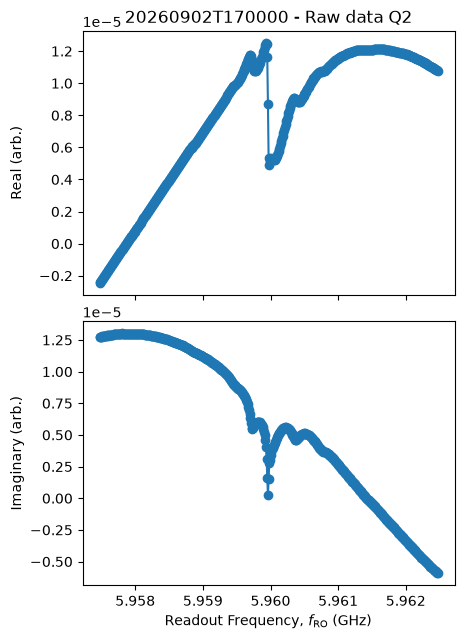

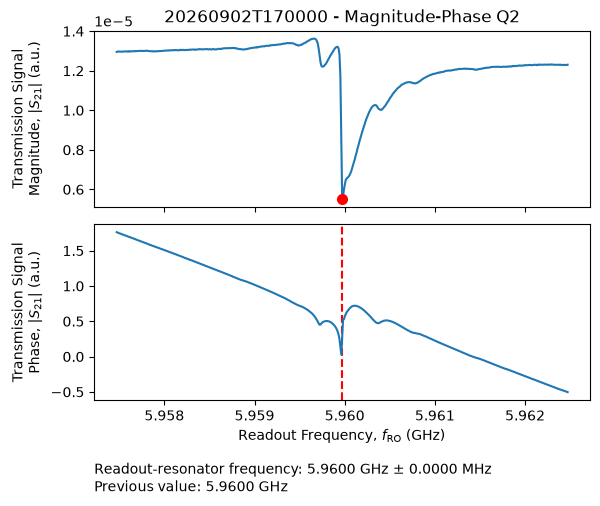

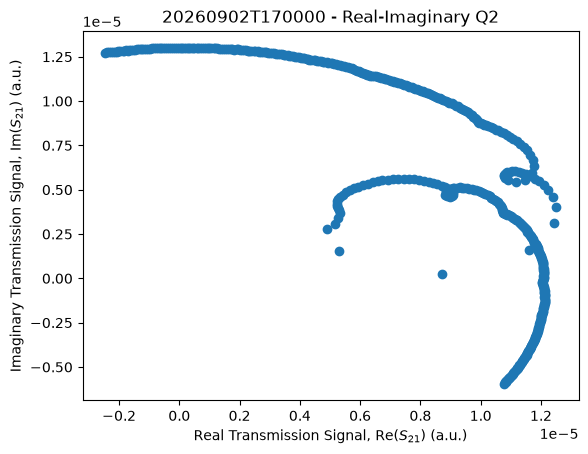

In [38]:
options = resonator_spectroscopy.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

qubit_to_measure = qubits[0]

frequencies = temporary_parameters[q.uid].readout_resonator_frequency + np.linspace(
    -freq_range / 2, freq_range / 2, n_points
)

exp_workflow = resonator_spectroscopy.experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    frequencies=frequencies,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [39]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

resonator_spectroscopy.update_qpu(qpu, qubit_parameters["new_parameter_values"])
print("\nReadout resonator frequency: ", qubit_to_measure.parameters.readout_resonator_frequency * 1e-9, ' GHz')

if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'readout_resonator_frequency': 5959972000.0+/-0}},
 'old_parameter_values': {'Q2': {'readout_resonator_frequency': 5959972000.0}}}

Readout resonator frequency:  5.9599720000000005  GHz

Updated global experiment parameters!



## Qubit Spectroscopy <a class="anchor" id="qubit-spectroscopy"></a>

#### Experiment Parameters

In [113]:
update_global_parameters = True

spectroscopy_length = 25e-6
spectroscopy_amplitude = 0.15
readout_amplitude = 0.2
readout_length = 2e-6
drive_range = 5
readout_range_out = -20
n_avg_exponent = 13

freq_range = 100e6
n_points = 251

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.spectroscopy_length = spectroscopy_length
temp_pars.spectroscopy_amplitude = spectroscopy_amplitude
temp_pars.readout_amplitude = readout_amplitude
temp_pars.readout_length = readout_length
temp_pars.drive_range = drive_range
temp_pars.readout_range_out = readout_range_out
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.09.02 18:12:40.151] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 18:12:40.151] INFO      Workflow 'qubit_spectroscopy': execution started at 2026-09-02                
[2026.09.02 18:12:40.151] INFO      15:12:40.151562Z                                                              
[2026.09.02 18:12:40.151] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 18:12:40.502] INFO    Task 'temporary_qpu': started at 2026-09-02 15:12:40.502884Z
[2026.09.02 18:12:40.582] INFO    Task 'temporary_qpu': ended at 2026-09-02 15:12:40.582652Z
[2026.09.02 18:12:40.726] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-02 
[2026.09.02 18:12:40.726] INFO    15:12:40.726189Z
[2026.09.02 18:12:40.790] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-02 15:12:40.790116Z
[2026.09.02 18:12:40.939] INFO    Task 'create_experiment': started at 2026-09-02 15:

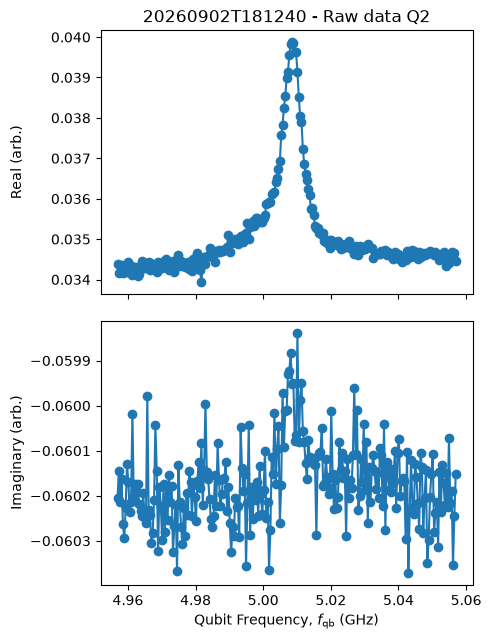

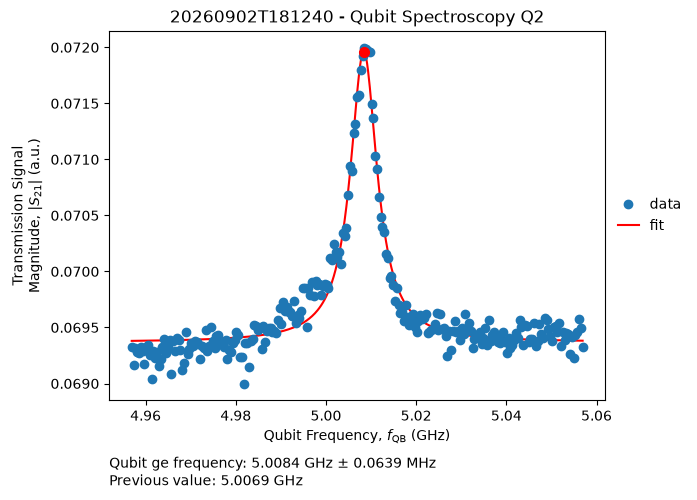

In [114]:
options = qubit_spectroscopy.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.update(False) 
options.close_figures(False)

qubits_to_measure = [qubits[0]]

frequencies = [
    temporary_parameters[q.uid].resonance_frequency_ge + np.linspace(- freq_range / 2, freq_range / 2, n_points)
    for q in qubits_to_measure
]
exp_workflow = qubit_spectroscopy.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    frequencies=frequencies,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [75]:
manual_center_frequency = 5.0048e9
temporary_parameters[qubit_to_measure.uid].resonance_frequency_ge = manual_center_frequency

In [115]:
analysis_workflow_result= workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

qubit_spectroscopy.update_qpu(qpu, qubit_parameters["new_parameter_values"])
print("\nReadout resonance frequency ge: ", qubit_to_measure.parameters.resonance_frequency_ge)

if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'resonance_frequency_ge': 5008376715.293567+/-63855.14410063903}},
 'old_parameter_values': {'Q2': {'resonance_frequency_ge': 5006919690.731945}}}

Readout resonance frequency ge:  5008376715.293567

Updated global experiment parameters!



# Control Pulses

## First Transision: g-e

### Amplitude Rabi <a class="anchor" id="amplitude-rabi-ge"></a>

#### Experiment Parameters

In [125]:
update_global_parameters = True

transition = set_transition('ge')

drive_range = 5
drive_length = 200e-9
readout_amplitude = 0.2
n_avg_exponent = 13

amp_min = 0
amp_max = 1
n_amp = 41

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.drive_range = drive_range
temp_pars.readout_amplitude = readout_amplitude
if transition == 'ge':
    temp_pars.ge_drive_length = drive_length
elif transition == 'ef':
    temp_pars.ef_drive_length = drive_length
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.09.02 18:19:27.680] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 18:19:27.680] INFO      Workflow 'amplitude_rabi': execution started at 2026-09-02 15:19:27.680419Z   
[2026.09.02 18:19:27.687] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 18:19:28.170] INFO    Task 'temporary_qpu': started at 2026-09-02 15:19:28.170495Z
[2026.09.02 18:19:28.221] INFO    Task 'temporary_qpu': ended at 2026-09-02 15:19:28.221734Z
[2026.09.02 18:19:28.346] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-02 
[2026.09.02 18:19:28.350] INFO    15:19:28.346014Z
[2026.09.02 18:19:28.399] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-02 15:19:28.399086Z
[2026.09.02 18:19:28.535] INFO    Task 'create_experiment': started at 2026-09-02 15:19:28.535766Z
[2026.09.02 18:19:28.695] INFO    Task 'create_experiment': ended at 2026-09-02 15:19:28.693624Z
[202

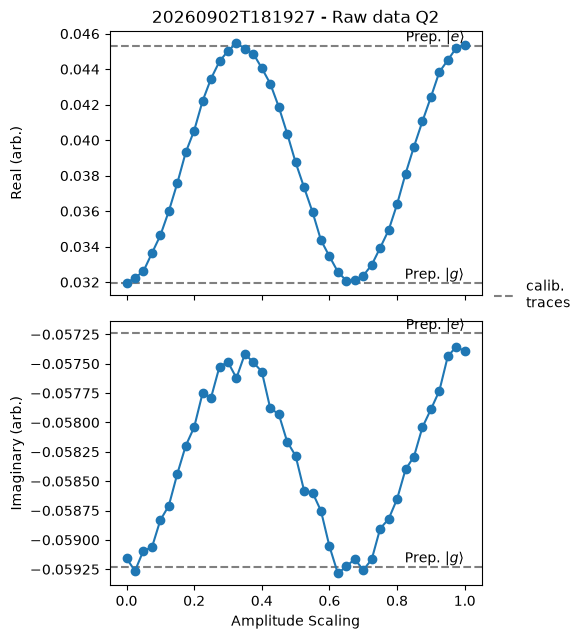

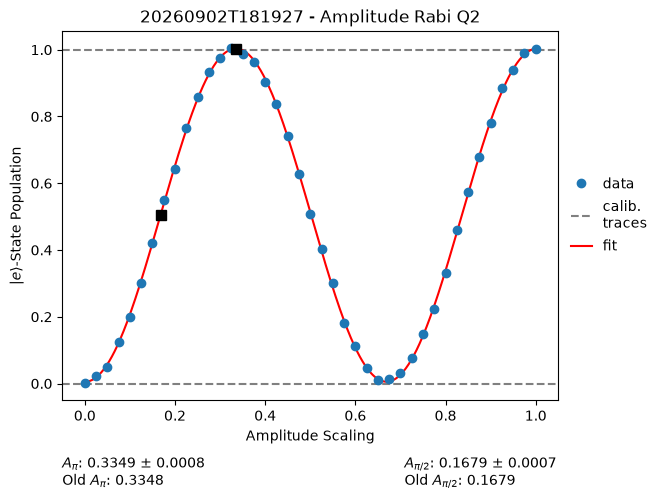

In [126]:
options = amplitude_rabi.experiment_workflow.options()

options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_rabi.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [127]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    
amplitude_rabi.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("\nDrive amplitude pi ge: ", qubit_to_measure.parameters.ge_drive_amplitude_pi)
    print("Drive amplitude pi2 ge: ", qubit_to_measure.parameters.ge_drive_amplitude_pi2)
elif transition == 'ef':
    print("\nDrive amplitude pi ef: ", qubit_to_measure.parameters.ef_drive_amplitude_pi)
    print("Drive amplitude pi2 ef: ", qubit_to_measure.parameters.ef_drive_amplitude_pi2)

if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ge_drive_amplitude_pi': 0.3349235811588707+/-0.0007903915768408473,
                                 'ge_drive_amplitude_pi2': 0.16787355028082324+/-0.0007121885770966544}},
 'old_parameter_values': {'Q2': {'ge_drive_amplitude_pi': 0.33476019951081337,
                                 'ge_drive_amplitude_pi2': 0.16793935728096304}}}

Drive amplitude pi ge:  0.3349235811588707
Drive amplitude pi2 ge:  0.16787355028082324

Updated global experiment parameters!



### Amplitude Rabi Chevron <a class="anchor" id="amplitude-rabi-chevron-ge"></a>

#### Experiment Paramters

In [ ]:
update_global_parameters = True

transition = set_transition('ge')

# drive_range = 10
# drive_length = 100e-9
# readout_amplitude = 0.2
n_avg_exponent = 13

freq_range = 100e6
n_points = 251

amp_min = 0
amp_max = 1
n_amp = 41

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
# temp_pars.drive_range = drive_range
# temp_pars.readout_amplitude = readout_amplitude
# if transition == 'ge':
#     temp_pars.ge_drive_length = drive_length
# elif transition == 'ef':
#     temp_pars.ef_drive_length = drive_length
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

In [ ]:
options = amplitude_rabi_chevron.experiment_workflow.options()

options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

frequencies = [
    temporary_parameters[q.uid].resonance_frequency_ge + np.linspace(- freq_range / 2, freq_range / 2, n_points)
    for q in qubits_to_measure
]

exp_workflow = amplitude_rabi_chevron.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    frequencies=frequencies,
    amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

### Rabi Chevron <a class="anchor" id="rabi-chevron-ge"></a>

#### Experiment Parameters

In [ ]:
# Rabi chevron is a diagnostic 2D scan (amplitude vs. detuning) - it is not expected
# to update the global qubit parameters directly, so we leave this False by default.
update_global_parameters = False

transition = set_transition('ge')

drive_range = 10
drive_length = 100e-9
readout_amplitude = 0.2
n_avg_exponent = 13

amp_min = 0
amp_max = 1
n_amp = 41

# frequency detuning range swept around the qubit's current resonance frequency
chevron_detuning_min = -6e6
chevron_detuning_max = 2e6
n_detuning = 9
chevron_detunings = np.linspace(chevron_detuning_min, chevron_detuning_max, n_detuning)

if transition == 'ge':
    base_resonance_frequency = qubits[0].parameters.resonance_frequency_ge
elif transition == 'ef':
    base_resonance_frequency = qubits[0].parameters.resonance_frequency_ef

#### Run Workflow

In [ ]:
options = amplitude_rabi.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(True)  # suppress per-detuning plots; we build one 2D map below

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

rabi_chevron_results = []

for detuning in chevron_detunings:
    print(f'Measuring chevron point at detuning: {detuning * 1e-6:.3f} MHz')

    temporary_parameters = {}
    temp_pars = deepcopy(qubits[0].parameters)
    temp_pars.drive_range = drive_range
    temp_pars.readout_amplitude = readout_amplitude
    if transition == 'ge':
        temp_pars.ge_drive_length = drive_length
        temp_pars.resonance_frequency_ge = base_resonance_frequency + detuning
    elif transition == 'ef':
        temp_pars.ef_drive_length = drive_length
        temp_pars.resonance_frequency_ef = base_resonance_frequency + detuning
    temporary_parameters[q.uid] = temp_pars

    exp_workflow = amplitude_rabi.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[q.uid for q in qubits_to_measure],
        amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
        options=options,
        temporary_parameters=temporary_parameters
    )
    workflow_result = exp_workflow.run()

    # Raw acquired signal for the qubit under test.
    # NOTE: adjust the accessor below if `get_data` does not match the acquire
    # handle used internally by the installed version of `amplitude_rabi`.
    raw_signal = workflow_result.tasks["run_experiment"].output.get_data(qubit_to_measure.uid+"/result")
    rabi_chevron_results.append(raw_signal)

rabi_chevron_arr = np.array(rabi_chevron_results)
rabi_chevron_amp = np.linspace(amp_min, amp_max, n_amp)

#### Plot Chevron Map

In [ ]:
X = rabi_chevron_amp
Y = chevron_detunings * 1e-6
Z = np.absolute(rabi_chevron_arr)

fig, ax = plt.subplots(figsize=(8, 6))
c = ax.pcolormesh(X, Y, Z, cmap='Reds', shading='auto')
fig.colorbar(c, ax=ax, label='Signal amplitude (a.u.)')
ax.set_xlabel('Drive amplitude (a.u.)')
ax.set_ylabel('Detuning (MHz)')
ax.set_title(f'Rabi chevron, {transition}-transition')

figname = f'Rabi_chevron_{transition}_'
file_path = get_path_to_file(figname, '.png')
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

#### Save Data 

In [ ]:
Data_rabi_chevron = {
    'rabi_chevron': rabi_chevron_arr,
    'detunings': chevron_detunings,
    'rabi_amp': rabi_chevron_amp,
}

file_name = f'Rabi_chevron_{transition}_'
file_path = get_path_to_file(file_name, '.mat')
savemat(file_path, Data_rabi_chevron)

### Rabi Frequency Calibration <a class="anchor" id="rabi-frequency-calibration-ge"></a>

#### Experiment Parameters

In [ ]:
# This experiment derives a slope/intercept relation between drive-pulse length and
# the required pi-pulse amplitude. It is diagnostic/informational (used to
# extrapolate the amplitude needed for a target pulse length or Rabi frequency), so
# it does not directly overwrite `qubit_to_measure.parameters` below.
update_global_parameters = False

transition = set_transition('ge')

drive_range = 10
readout_amplitude = 0.2
n_avg_exponent = 12

amp_min = 0
amp_max = 1.0
n_amp = 101

drive_length_min = 50e-9
drive_length_max = 400e-9
n_drive_length = 36
drive_lengths = np.linspace(drive_length_min, drive_length_max, n_drive_length)

#### Run Workflow

In [ ]:
options = amplitude_rabi.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(True)  # suppress per-length plots; we build one summary plot below

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

fitted_pi_amplitudes = []

for drive_length in drive_lengths:
    print(f'Measuring Rabi with drive length: {drive_length * 1e9:.1f} ns')

    temporary_parameters = {}
    temp_pars = deepcopy(qubits[0].parameters)
    temp_pars.drive_range = drive_range
    temp_pars.readout_amplitude = readout_amplitude
    if transition == 'ge':
        temp_pars.ge_drive_length = drive_length
    elif transition == 'ef':
        temp_pars.ef_drive_length = drive_length
    temporary_parameters[q.uid] = temp_pars

    exp_workflow = amplitude_rabi.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[q.uid for q in qubits_to_measure],
        amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
        options=options,
        temporary_parameters=temporary_parameters
    )
    workflow_result = exp_workflow.run()

    analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
    # NOTE: adjust the key names below to match the installed library version if
    # `new_parameter_values` is not nested exactly this way.
    new_parameter_values = analysis_workflow_result.output["new_parameter_values"]
    if transition == 'ge':
        fitted_pi_amplitude = new_parameter_values[qubit_to_measure.uid]["ge_drive_amplitude_pi"]
    elif transition == 'ef':
        fitted_pi_amplitude = new_parameter_values[qubit_to_measure.uid]["ef_drive_amplitude_pi"]
    fitted_pi_amplitudes.append(fitted_pi_amplitude)

fitted_pi_amplitudes = np.array(fitted_pi_amplitudes)

#### Fit and Plot Amplitude vs. Drive Length

In [ ]:
from uncertainties import unumpy as unp

x = (1 / drive_lengths).astype('float64')  # proxy for Rabi frequency scaling with drive length
y = unp.nominal_values(fitted_pi_amplitudes).astype('float64')

rabi_freq_calib_popt, rabi_freq_calib_pcov = np.polyfit(x, y, 1, cov=True)
rabi_slope, rabi_intercept = rabi_freq_calib_popt

print('Rabi amplitude-length slope:', rabi_slope)
print('Rabi amplitude-length intercept:', rabi_intercept)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x * 1e-6, y, '.k')
ax.plot(x * 1e-6, np.polyval(rabi_freq_calib_popt, x), '-r')
ax.set_xlabel('1 / drive length (1/us)')
ax.set_ylabel(f'{transition} pi-pulse amplitude (a.u.)')
ax.set_title('Rabi frequency calibration')

figname = f'Rabi_freq_calib_{transition}_'
file_path = get_path_to_file(figname, '.png')
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

#### Save Data

In [ ]:
Data_rabi_freq_calib = {
    'drive_lengths': drive_lengths,
    'fitted_pi_amplitudes':  unp.nominal_values(fitted_pi_amplitudes).astype('float64'),
    'rabi_slope': rabi_slope,
    'rabi_intercept': rabi_intercept,
}

file_name = f'Rabi_freq_calib_{transition}_'
file_path = get_path_to_file(file_name, '.mat')
savemat(file_path, Data_rabi_freq_calib)

### T1 Lifetime <a class="anchor" id="t1-lifetime-ge"></a>

#### Experiment Parameters

In [137]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

delay_min = 0
delay_max = 30e-6
n_delay = 51
log_spacing = True

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.09.02 18:28:23.242] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 18:28:23.242] INFO      Workflow 'lifetime_measurement': execution started at 2026-09-02              
[2026.09.02 18:28:23.242] INFO      15:28:23.242873Z                                                              
[2026.09.02 18:28:23.242] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 18:28:23.634] INFO    Task 'temporary_qpu': started at 2026-09-02 15:28:23.629263Z
[2026.09.02 18:28:23.690] INFO    Task 'temporary_qpu': ended at 2026-09-02 15:28:23.690191Z
[2026.09.02 18:28:23.849] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-02 
[2026.09.02 18:28:23.849] INFO    15:28:23.849693Z
[2026.09.02 18:28:23.944] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-02 15:28:23.944638Z
[2026.09.02 18:28:24.075] INFO    Task 'create_experiment': started at 2026-09-02 15:

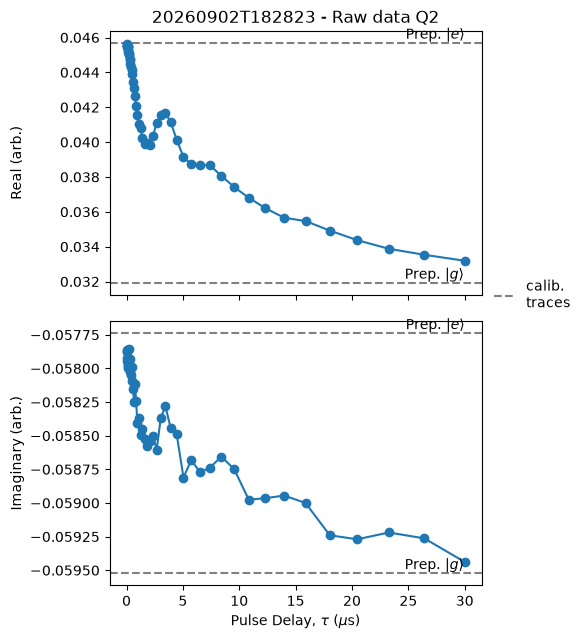

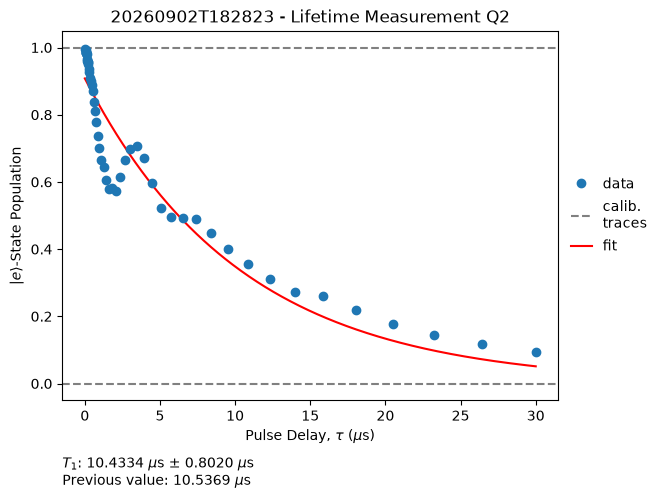

In [138]:
options = lifetime_measurement.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

if log_spacing:
    delays = [log_sweep_help(delay_min, delay_max, n_delay)]
else:
    delays = [np.linspace(delay_min, delay_max, n_delay)]

exp_workflow = lifetime_measurement.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    options=options,
    temporary_parameters=temporary_parameters 
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [139]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

lifetime_measurement.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("\nge_T1: ", qubit_to_measure.parameters.ge_T1)
elif transition == 'ef':
    print("\nef_T1: ", qubit_to_measure.parameters.ef_T1)

if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ge_T1': 1.0433416889865267e-05+/-8.020440077303272e-07}},
 'old_parameter_values': {'Q2': {'ge_T1': 1.0536881980934676e-05}}}

ge_T1:  1.0433416889865267e-05

Updated global experiment parameters!



In [140]:
qubits[0].parameters.reset_delay_length = 300e-6
# qubits[0].parameters.readout_range_in   = -20
# qubits[0].parameters.readout_range_out  = -30

### Ramsey <a class="anchor" id="ramsey-ge"></a>

#### Experiment Parameters

In [157]:
update_global_parameters = True

detuning = 0.2e6
transition = set_transition('ge')

n_avg_exponent = 13

delay_min = 0
delay_max = 35e-6
n_delay = 201

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.09.02 19:44:52.710] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 19:44:52.710] INFO      Workflow 'ramsey': execution started at 2026-09-02 16:44:52.710443Z           
[2026.09.02 19:44:52.710] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 19:44:53.101] INFO    Task 'temporary_qpu': started at 2026-09-02 16:44:53.101494Z
[2026.09.02 19:44:53.160] INFO    Task 'temporary_qpu': ended at 2026-09-02 16:44:53.160150Z
[2026.09.02 19:44:53.281] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-02 
[2026.09.02 19:44:53.281] INFO    16:44:53.281993Z
[2026.09.02 19:44:53.349] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-02 16:44:53.349900Z
[2026.09.02 19:44:53.515] INFO    Task 'create_experiment': started at 2026-09-02 16:44:53.513523Z
[2026.09.02 19:44:53.677] INFO    Task 'create_experiment': ended at 2026-09-02 16:44:53.677846Z
[202

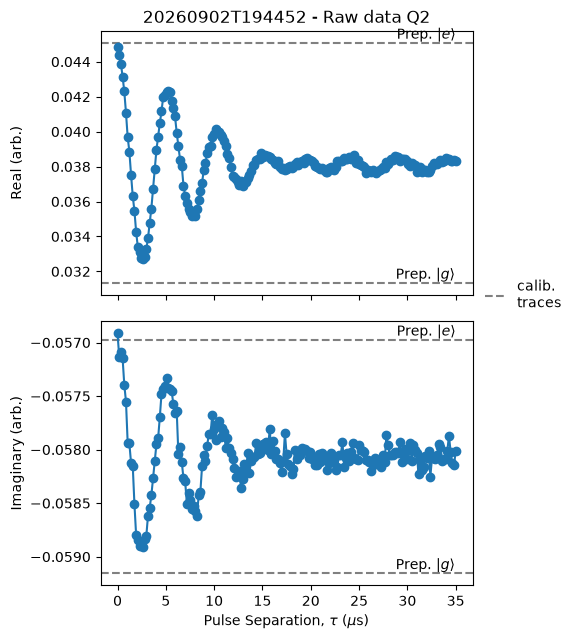

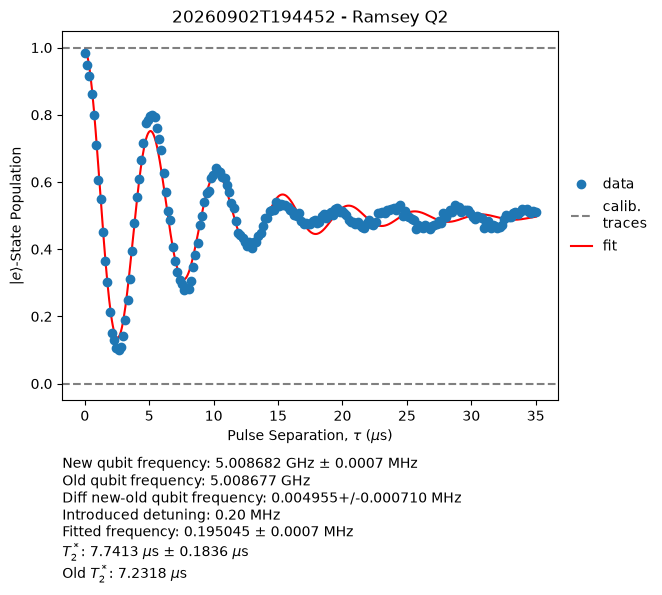

In [158]:
options = ramsey.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Ramsey in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
# qubits_to_measure = [qubits[0], qubits[2]]
qubits_to_measure = [qubits[0]]

delays = [
    np.linspace(delay_min, delay_max, n_delay)
]
detunings = [
    detuning
]

exp_workflow = ramsey.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    detunings=detunings,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [159]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("\nge_T2_star: ", qubit_to_measure.parameters.ge_T2_star)
    print("resonance_frequency_ge: ", qubit_to_measure.parameters.resonance_frequency_ge)
elif transition == 'ef':
    print("\nef_T2_star: ", qubit_to_measure.parameters.ef_T2_star)
    print("resonance_frequency_ef: ", qubit_to_measure.parameters.resonance_frequency_ef)

if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ge_T2_star': 7.741290835250325e-06+/-1.8359184480871462e-07,
                                 'resonance_frequency_ge': 5008681684.374855+/-710.1965912019789}},
 'old_parameter_values': {'Q2': {'ge_T2_star': 7.231840616572782e-06,
                                 'resonance_frequency_ge': 5008676729.760194}}}

ge_T2_star:  7.741290835250325e-06
resonance_frequency_ge:  5008681684.374855

Updated global experiment parameters!



### Rabi Error Amplification <a class="anchor" id="rabi-error-amplification-ge"></a>

#### x180 pulse

##### Experiment Parameters

In [165]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

x180_max_repetitions = 16
x180_repetitions = list(range(0, x180_max_repetitions + 1))

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

##### Run Workflow

[2026.09.02 19:56:32.915] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 19:56:32.915] INFO      Workflow 'experiment_workflow_x180': execution started at 2026-09-02          
[2026.09.02 19:56:32.915] INFO      16:56:32.915485Z                                                              
[2026.09.02 19:56:32.915] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 19:56:33.252] INFO    Task 'temporary_qpu': started at 2026-09-02 16:56:33.252024Z
[2026.09.02 19:56:33.302] INFO    Task 'temporary_qpu': ended at 2026-09-02 16:56:33.302820Z
[2026.09.02 19:56:33.399] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-02 
[2026.09.02 19:56:33.399] INFO    16:56:33.399498Z
[2026.09.02 19:56:33.509] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-02 16:56:33.509244Z
[2026.09.02 19:56:33.606] INFO    Task 'create_experiment': started at 2026-09-02 16:

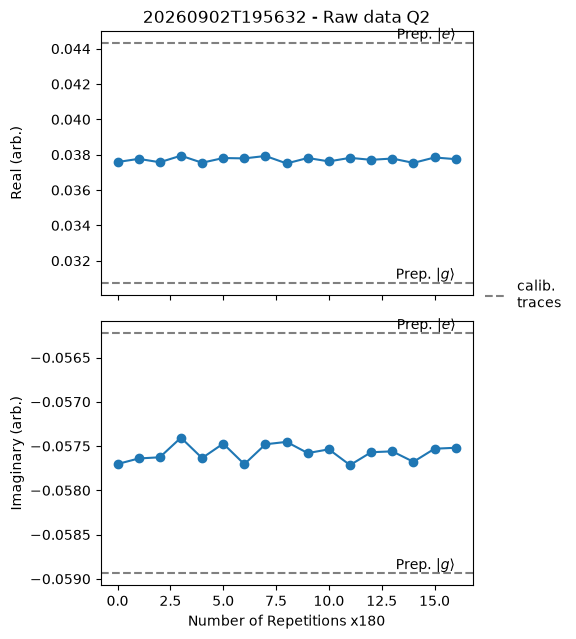

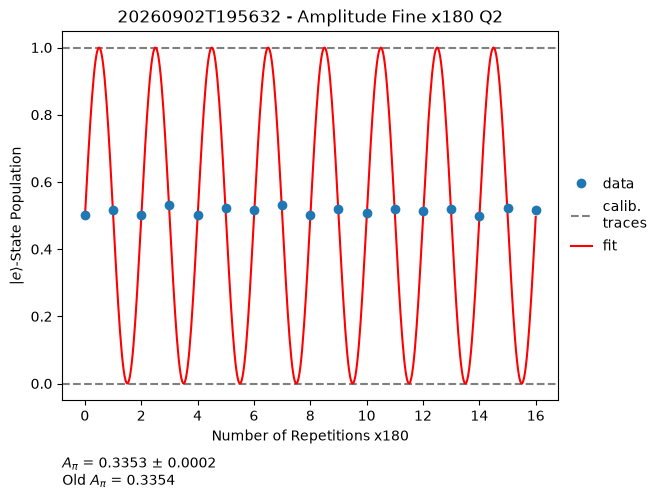

In [166]:
options = amplitude_fine.experiment_workflow_x180.options()
options.count(2**n_avg_exponent)
options.close_figures(False)  # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_fine.experiment_workflow_x180(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    repetitions=[x180_repetitions for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

##### Update Parameters

In [167]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

amplitude_fine.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("\nDrive amplitude pi ge (error-amplified): ", qubit_to_measure.parameters.ge_drive_amplitude_pi)
elif transition == 'ef':
    print("\nDrive amplitude pi ef (error-amplified): ", qubit_to_measure.parameters.ef_drive_amplitude_pi)

if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ge_drive_amplitude_pi': 0.3352897014347527+/-0.0001779219961663429}},
 'old_parameter_values': {'Q2': {'ge_drive_amplitude_pi': 0.33537351096376844}}}

Drive amplitude pi ge (error-amplified):  0.3352897014347527

Updated global experiment parameters!



#### x90 pulse

##### Experiment Parameters

In [408]:
update_global_parameters = False

transition = set_transition('ge')

# ge_drive_amplitude_pi2 = 0.16787355028082324

n_avg_exponent = 13

x90_max_repetitions = 40
x90_repetitions = list(range(2, x90_max_repetitions + 1, 2))

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
# temp_pars.ge_drive_amplitude_pi2 = ge_drive_amplitude_pi2
temporary_parameters[q.uid] = temp_pars

##### Run Workflow

[2026.09.03 12:38:02.860] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 12:38:02.860] INFO      Workflow 'experiment_workflow_x90': execution started at 2026-09-03           
[2026.09.03 12:38:02.860] INFO      09:38:02.860019Z                                                              
[2026.09.03 12:38:02.860] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 12:38:03.116] INFO    Task 'temporary_qpu': started at 2026-09-03 09:38:03.116332Z
[2026.09.03 12:38:03.164] INFO    Task 'temporary_qpu': ended at 2026-09-03 09:38:03.164185Z
[2026.09.03 12:38:03.284] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-03 
[2026.09.03 12:38:03.284] INFO    09:38:03.284065Z
[2026.09.03 12:38:03.311] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-03 09:38:03.311321Z
[2026.09.03 12:38:03.423] INFO    Task 'create_experiment': started at 2026-09-03 09:

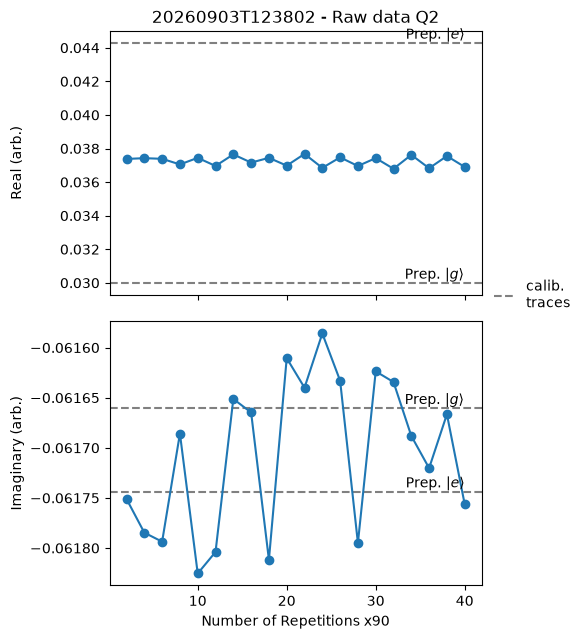

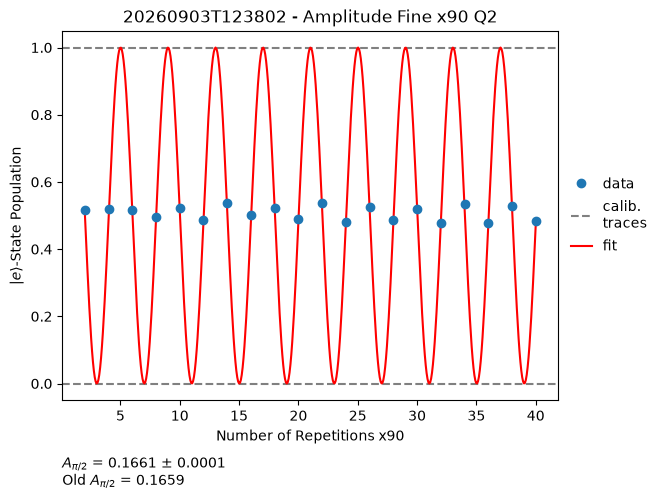

In [409]:
options = amplitude_fine.experiment_workflow_x90.options()
options.count(2**n_avg_exponent)
options.close_figures(False)  # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_fine.experiment_workflow_x90(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    repetitions=[x90_repetitions for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

##### Update Parameters

In [407]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

amplitude_fine.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("\nDrive amplitude pi2 ge (error-amplified): ", qubit_to_measure.parameters.ge_drive_amplitude_pi2)
elif transition == 'ef':
    print("\nDrive amplitude pi2 ef (error-amplified): ", qubit_to_measure.parameters.ef_drive_amplitude_pi2)

if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ge_drive_amplitude_pi2': 0.16594439910907385+/-0.0003438668849214097}},
 'old_parameter_values': {'Q2': {'ge_drive_amplitude_pi2': 0.165745015700424}}}

Drive amplitude pi2 ge (error-amplified):  0.16594439910907385

Updated global experiment parameters!



### DRAG Calibration <a class="anchor" id="drag-calibration-ge"></a>

#### Experiment Parameters

In [205]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

q_min = -0.1
q_max = 0.1
n_q = 61

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.09.02 21:00:52.847] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 21:00:52.847] INFO      Workflow 'drag_q_scaling': execution started at 2026-09-02 18:00:52.842309Z   
[2026.09.02 21:00:52.847] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 21:00:53.144] INFO    Task 'temporary_qpu': started at 2026-09-02 18:00:53.139976Z
[2026.09.02 21:00:53.199] INFO    Task 'temporary_qpu': ended at 2026-09-02 18:00:53.199966Z
[2026.09.02 21:00:53.305] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-02 
[2026.09.02 21:00:53.308] INFO    18:00:53.305953Z
[2026.09.02 21:00:53.363] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-02 18:00:53.363186Z
[2026.09.02 21:00:53.522] INFO    Task 'create_experiment': started at 2026-09-02 18:00:53.522350Z
[2026.09.02 21:00:53.642] INFO    Task 'create_experiment': ended at 2026-09-02 18:00:53.630937Z
[202

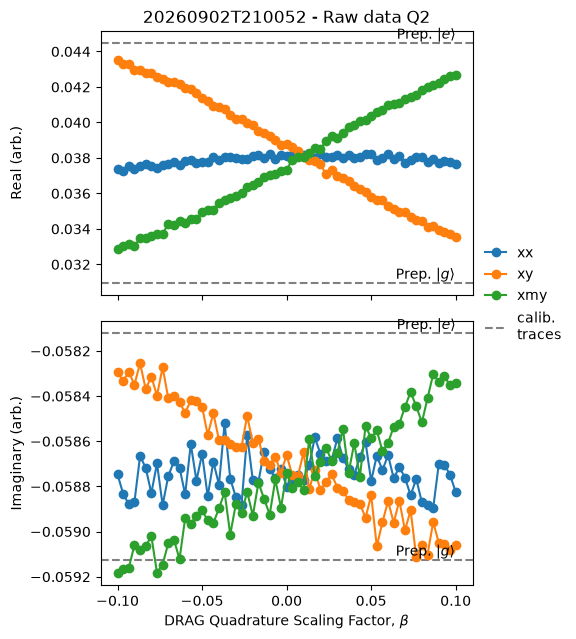

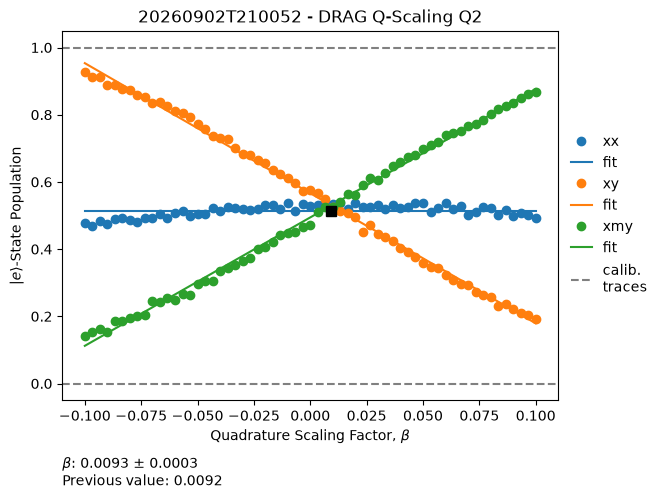

In [206]:
options = drag_q_scaling.experiment_workflow.options()
# options.update(True)  # updates the qubit parameter 'ge_drive_pulse["beta"]'
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = drag_q_scaling.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    q_scalings=[np.linspace(q_min, q_max, n_q) for _ in qubits_to_measure],
    options=options,
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [207]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

drag_q_scaling.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("\nge_drive_pulse[beta]: ", qubit_to_measure.parameters.ge_drive_pulse["beta"])
elif transition == 'ef':
    print("\nef_drive_pulse[beta]: ", qubit_to_measure.parameters.ef_drive_pulse["beta"])

if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ge_drive_pulse.beta': 0.009337457823820674+/-0.00029384648720692563}},
 'old_parameter_values': {'Q2': {'ge_drive_pulse.beta': 0.009165185926410592}}}

ge_drive_pulse[beta]:  0.009337457823820674

Updated global experiment parameters!



### Hahn-Echo <a class="anchor" id="hahn-echo-ge"></a>

#### Experiment Parameters

In [214]:
update_global_parameters = True

transition = set_transition('ge')

n_avg_exponent = 13

delay_min = 0
delay_max = 50e-6
n_delay = 51
log_spacing = True

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.09.02 21:26:53.124] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 21:26:53.124] INFO      Workflow 'echo': execution started at 2026-09-02 18:26:53.124502Z             
[2026.09.02 21:26:53.124] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 21:26:53.559] INFO    Task 'temporary_qpu': started at 2026-09-02 18:26:53.551329Z
[2026.09.02 21:26:53.627] INFO    Task 'temporary_qpu': ended at 2026-09-02 18:26:53.627551Z
[2026.09.02 21:26:53.769] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-02 
[2026.09.02 21:26:53.769] INFO    18:26:53.769668Z
[2026.09.02 21:26:53.849] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-02 18:26:53.849780Z
[2026.09.02 21:26:54.018] INFO    Task 'create_experiment': started at 2026-09-02 18:26:54.018569Z
[2026.09.02 21:26:54.181] INFO    Task 'create_experiment': ended at 2026-09-02 18:26:54.181051Z
[202

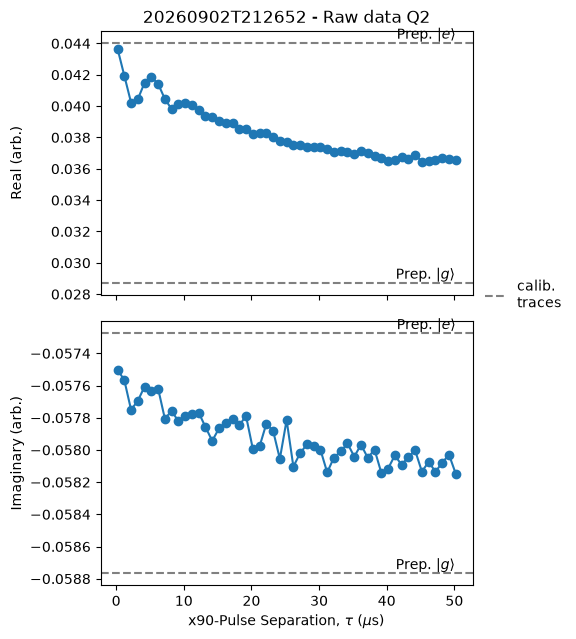

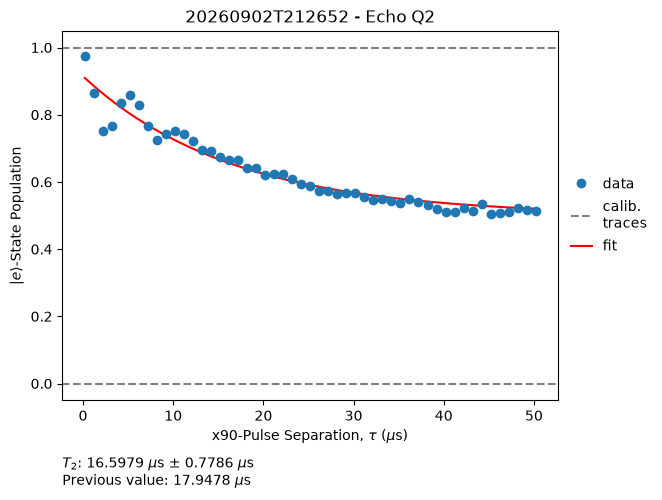

In [215]:
options = echo.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

options.transition(transition)
options.cal_states(transition)

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Echo in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
qubits_to_measure = [qubits[0]]

delays = [
    np.linspace(delay_min, delay_max, n_delay)
]

exp_workflow = echo.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [216]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

echo.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("\nge_T2: ", qubit_to_measure.parameters.ge_T2)
elif transition == 'ef':
    print("\nef_T2: ", qubit_to_measure.parameters.ef_T2)

if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ge_T2': 1.659788521169252e-05+/-7.786470657095453e-07}},
 'old_parameter_values': {'Q2': {'ge_T2': 1.7947759254376285e-05}}}

ge_T2:  1.659788521169252e-05

Updated global experiment parameters!



In [217]:
qpu.quantum_elements

[TunableTransmonQubit(
│   uid='Q2',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=1.0433416889865267e-05,
│   │   ge_T2=1.659788521169252e-05,
│   │   ge_T2_star=7.741290835250325e-06,
│   │   ef_T1=0,
│   │   ef_T2=0,
│   │   ef_T2_star=0,
│   │   drive_lo_frequency=4800000000.0,
│   │   readout_lo_frequency=6000000000.0,
│   │   resonance_frequency_ge=5008681684.374855,
│   │   resonance_frequency_ef=4800000000.0,
│   │   readout_resonator_frequency=5959972000.0,
│   │   ge_drive_amplitude_pi=0.3352897014347527,
│   │   ge_drive_amplitude_pi2=0.1647637202464873,
│   │   ge_drive_length=2e-07,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0.009337457823820674,
│   │   │   'sigma': 0.25
│   │   },
│   │   ef_drive_amplitude_pi=0.2,
│   │   ef_drive_amplitude_pi2=0.1,
│   │ 

## Second Transition: e-f

### Amplitude Rabi <a class="anchor" id="amplitude-rabi-ef"></a>

#### Experiment Parameters

In [228]:
update_global_parameters = True

transition = set_transition('ef')

# drive_range = 5
drive_length = 100e-9
readout_amplitude = 0.2
n_avg_exponent = 13

amp_min = 0
amp_max = 1
n_amp = 41

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
# temp_pars.drive_range = drive_range
temp_pars.readout_amplitude = readout_amplitude
if transition == 'ge':
    temp_pars.ge_drive_length = drive_length
elif transition == 'ef':
    temp_pars.ef_drive_length = drive_length
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.09.02 21:51:45.371] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 21:51:45.373] INFO      Workflow 'amplitude_rabi': execution started at 2026-09-02 18:51:45.371153Z   
[2026.09.02 21:51:45.375] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 21:51:45.736] INFO    Task 'temporary_qpu': started at 2026-09-02 18:51:45.736713Z
[2026.09.02 21:51:45.814] INFO    Task 'temporary_qpu': ended at 2026-09-02 18:51:45.814668Z
[2026.09.02 21:51:45.981] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-02 
[2026.09.02 21:51:45.983] INFO    18:51:45.981490Z
[2026.09.02 21:51:46.039] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-02 18:51:46.039579Z
[2026.09.02 21:51:46.209] INFO    Task 'create_experiment': started at 2026-09-02 18:51:46.209905Z
[2026.09.02 21:51:46.395] INFO    Task 'create_experiment': ended at 2026-09-02 18:51:46.395722Z
[202

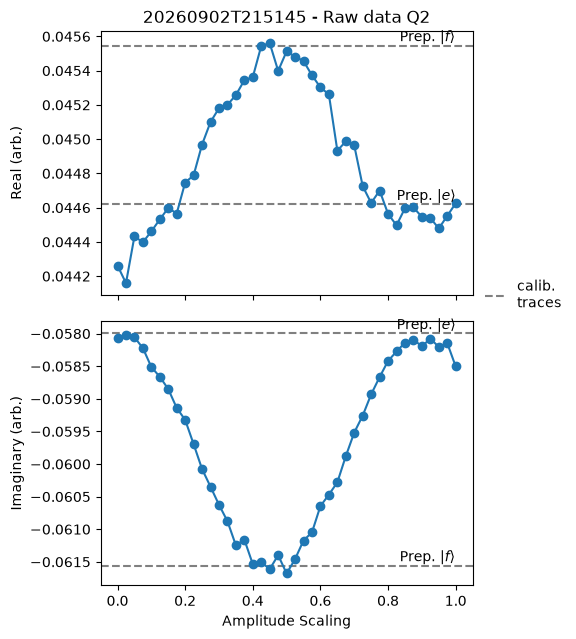

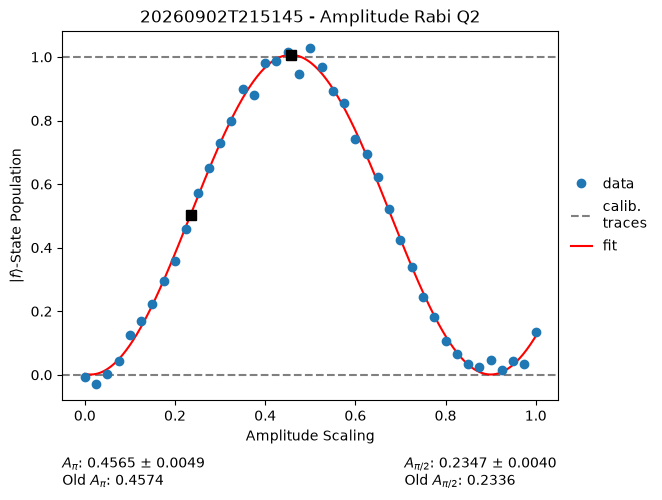

In [229]:
options = amplitude_rabi.experiment_workflow.options()

options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_rabi.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [230]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

amplitude_rabi.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("\nDrive amplitude pi ge: ", qubit_to_measure.parameters.ge_drive_amplitude_pi)
    print("Drive amplitude pi2 ge: ", qubit_to_measure.parameters.ge_drive_amplitude_pi2)
elif transition == 'ef':
    print("\nDrive amplitude pi ef: ", qubit_to_measure.parameters.ef_drive_amplitude_pi)
    print("Drive amplitude pi2 ef: ", qubit_to_measure.parameters.ef_drive_amplitude_pi2)

if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ef_drive_amplitude_pi': 0.45650225253952953+/-0.00486680431596746,
                                 'ef_drive_amplitude_pi2': 0.2346864870171335+/-0.004033823973253597}},
 'old_parameter_values': {'Q2': {'ef_drive_amplitude_pi': 0.45741010762813317,
                                 'ef_drive_amplitude_pi2': 0.23363508803763777}}}

Drive amplitude pi ef:  0.45650225253952953
Drive amplitude pi2 ef:  0.2346864870171335

Updated global experiment parameters!



### Amplitude Rabi Chevron <a class="anchor" id="amplitude-rabi-chevron-ef"></a>

#### Experiment Paramters

In [ ]:
update_global_parameters = True

transition = set_transition('ef')

drive_range = 10
drive_length = 100e-9
readout_amplitude = 0.2
n_avg_exponent = 13

freq_range = 100e6
n_points = 251

amp_min = 0
amp_max = 1
n_amp = 41

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temp_pars.drive_range = drive_range
temp_pars.readout_amplitude = readout_amplitude
if transition == 'ge':
    temp_pars.ge_drive_length = drive_length
elif transition == 'ef':
    temp_pars.ef_drive_length = drive_length
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

In [ ]:
options = amplitude_rabi_chevron.experiment_workflow.options()

options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

frequencies = [
    temporary_parameters[q.uid].resonance_frequency_ge + np.linspace(- freq_range / 2, freq_range / 2, n_points)
    for q in qubits_to_measure
]

exp_workflow = amplitude_rabi_chevron.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    frequencies=frequencies,
    amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

### Rabi Chevron <a class="anchor" id="rabi-chevron-ef"></a>

#### Experiment Parameters

In [ ]:
update_global_parameters = False

transition = set_transition('ef')

drive_range = 10
drive_length = 100e-9
readout_amplitude = 0.2
n_avg_exponent = 12

amp_min = 0
amp_max = 1
n_amp = 31

chevron_detuning_min = -3.0e6
chevron_detuning_max = 3.0e6
n_detuning = 7
chevron_detunings = np.linspace(chevron_detuning_min, chevron_detuning_max, n_detuning)

if transition == 'ge':
    base_resonance_frequency = qubit_to_measure.parameters.resonance_frequency_ge
elif transition == 'ef':
    base_resonance_frequency = qubit_to_measure.parameters.resonance_frequency_ef

#### Run Workflow

In [ ]:
options = amplitude_rabi.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(True)

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

rabi_chevron_results = []

for detuning in chevron_detunings:
    print(f'Measuring chevron point at detuning: {detuning * 1e-6:.3f} MHz')

    temporary_parameters = {}
    temp_pars = deepcopy(qubits[0].parameters)
    temp_pars.drive_range = drive_range
    temp_pars.readout_amplitude = readout_amplitude
    if transition == 'ge':
        temp_pars.ge_drive_length = drive_length
        temp_pars.resonance_frequency_ge = base_resonance_frequency + detuning
    elif transition == 'ef':
        temp_pars.ef_drive_length = drive_length
        temp_pars.resonance_frequency_ef = base_resonance_frequency + detuning
    temporary_parameters[q.uid] = temp_pars

    exp_workflow = amplitude_rabi.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[q.uid for q in qubits_to_measure],
        amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
        options=options,
        temporary_parameters=temporary_parameters
    )
    workflow_result = exp_workflow.run()

    raw_signal = workflow_result.tasks["run_experiment"].output.get_data(qubit_to_measure.uid+"/result")
    rabi_chevron_results.append(raw_signal)

rabi_chevron_arr = np.array(rabi_chevron_results)
rabi_chevron_amp = np.linspace(amp_min, amp_max, n_amp)

#### Plot Chevron Map

In [ ]:
X = rabi_chevron_amp
Y = chevron_detunings * 1e-6
Z = np.absolute(rabi_chevron_arr)

fig, ax = plt.subplots(figsize=(8, 6))
c = ax.pcolormesh(X, Y, Z, cmap='Reds', shading='auto')
fig.colorbar(c, ax=ax, label='Signal amplitude (a.u.)')
ax.set_xlabel('Drive amplitude (a.u.)')
ax.set_ylabel('Detuning (MHz)')
ax.set_title(f'Rabi chevron, {transition}-transition')

figname = f'Rabi_chevron_{transition}_'
file_path = get_path_to_file(figname, '.png')
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

#### Save Data

In [ ]:
Data_rabi_chevron = {
    'rabi_chevron': rabi_chevron_arr,
    'detunings': chevron_detunings,
    'rabi_amp': rabi_chevron_amp,
}

file_name = f'Rabi_chevron_{transition}_'
file_path = get_path_to_file(file_name, '.mat')
savemat(file_path, Data_rabi_chevron)

### Rabi Frequency Calibration <a class="anchor" id="rabi-frequency-calibration-ef"></a>

#### Experiment Parameters

In [ ]:
update_global_parameters = False

transition = set_transition('ef')

drive_range = 10
readout_amplitude = 0.1
n_avg_exponent = 12

amp_min = 0
amp_max = 1.0
n_amp = 101

drive_length_min = 50e-9
drive_length_max = 400e-9
n_drive_length = 36
drive_lengths = np.linspace(drive_length_min, drive_length_max, n_drive_length)

#### Run Workflow

In [ ]:
options = amplitude_rabi.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(True)

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

fitted_pi_amplitudes = []

for drive_length in drive_lengths:
    print(f'Measuring Rabi with drive length: {drive_length * 1e9:.1f} ns')

    temporary_parameters = {}
    temp_pars = deepcopy(qubits[0].parameters)
    temp_pars.drive_range = drive_range
    temp_pars.readout_amplitude = readout_amplitude
    if transition == 'ge':
        temp_pars.ge_drive_length = drive_length
    elif transition == 'ef':
        temp_pars.ef_drive_length = drive_length
    temporary_parameters[q.uid] = temp_pars

    exp_workflow = amplitude_rabi.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[q.uid for q in qubits_to_measure],
        amplitudes=[np.linspace(amp_min, amp_max, n_amp) for q in qubits_to_measure],
        options=options,
        temporary_parameters=temporary_parameters
    )
    workflow_result = exp_workflow.run()

    analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
    new_parameter_values = analysis_workflow_result.output["new_parameter_values"]
    if transition == 'ge':
        fitted_pi_amplitude = new_parameter_values[qubit_to_measure.uid]["ge_drive_amplitude_pi"]
    elif transition == 'ef':
        fitted_pi_amplitude = new_parameter_values[qubit_to_measure.uid]["ef_drive_amplitude_pi"]
    fitted_pi_amplitudes.append(fitted_pi_amplitude)

fitted_pi_amplitudes = np.array(fitted_pi_amplitudes)

#### Fit and Plot Amplitude vs. Drive Length

In [ ]:
from uncertainties import unumpy as unp

x = (1 / drive_lengths).astype('float64')  # proxy for Rabi frequency scaling with drive length
y = unp.nominal_values(fitted_pi_amplitudes).astype('float64')

rabi_freq_calib_popt, rabi_freq_calib_pcov = np.polyfit(x, y, 1, cov=True)
rabi_slope, rabi_intercept = rabi_freq_calib_popt

print('Rabi amplitude-length slope:', rabi_slope)
print('Rabi amplitude-length intercept:', rabi_intercept)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x * 1e-6, y, '.k')
ax.plot(x * 1e-6, np.polyval(rabi_freq_calib_popt, x), '-r')
ax.set_xlabel('1 / drive length (1/us)')
ax.set_ylabel(f'{transition} pi-pulse amplitude (a.u.)')
ax.set_title('Rabi frequency calibration')

figname = f'Rabi_freq_calib_{transition}_'
file_path = get_path_to_file(figname, '.png')
plt.savefig(file_path, dpi=600, format='png', metadata=None,
        bbox_inches=None, pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None,
       )

#### Save Data

In [ ]:
Data_rabi_freq_calib = {
    'drive_lengths': drive_lengths,
    'fitted_pi_amplitudes': unp.nominal_values(fitted_pi_amplitudes).astype('float64'),
    'rabi_slope': rabi_slope,
    'rabi_intercept': rabi_intercept,
}

file_name = f'Rabi_freq_calib_{transition}_'
file_path = get_path_to_file(file_name, '.mat')
savemat(file_path, Data_rabi_freq_calib)

### T1 Lifetime <a class="anchor" id="t1-lifetime-ef"></a>

#### Experiment Parameters

In [240]:
update_global_parameters = True

transition = set_transition('ef')

n_avg_exponent = 13

delay_min = 0
delay_max = 20e-6
n_delay = 71
log_spacing = True

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.09.02 22:03:40.287] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 22:03:40.296] INFO      Workflow 'lifetime_measurement': execution started at 2026-09-02              
[2026.09.02 22:03:40.298] INFO      19:03:40.287796Z                                                              
[2026.09.02 22:03:40.299] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.02 22:03:40.537] INFO    Task 'temporary_qpu': started at 2026-09-02 19:03:40.537036Z
[2026.09.02 22:03:40.568] INFO    Task 'temporary_qpu': ended at 2026-09-02 19:03:40.568533Z
[2026.09.02 22:03:40.657] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-02 
[2026.09.02 22:03:40.657] INFO    19:03:40.650554Z
[2026.09.02 22:03:40.696] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-02 19:03:40.696620Z
[2026.09.02 22:03:40.814] INFO    Task 'create_experiment': started at 2026-09-02 19:

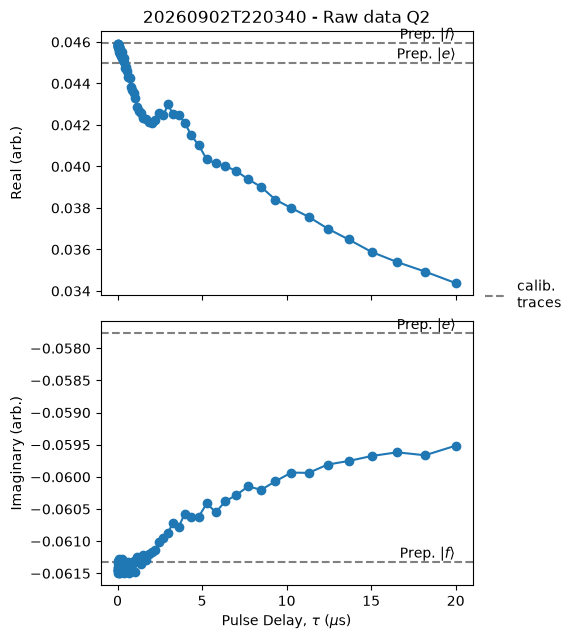

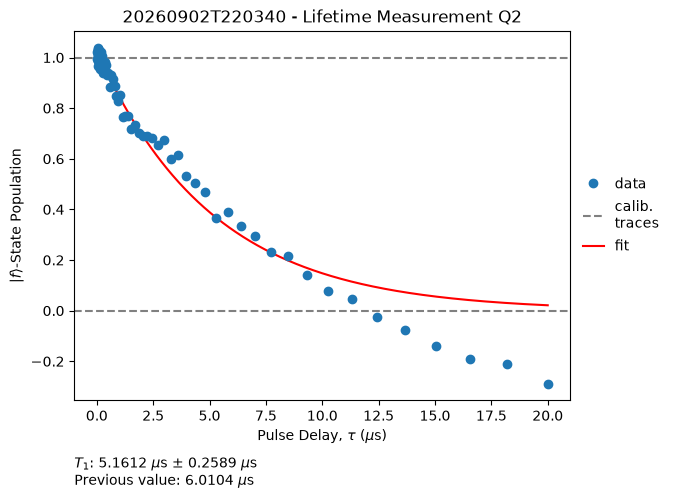

In [241]:
options = lifetime_measurement.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

if log_spacing:
    delays = [log_sweep_help(delay_min, delay_max, n_delay)]
else:
    delays = [np.linspace(delay_min, delay_max, n_delay)]

exp_workflow = lifetime_measurement.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    options=options,
    temporary_parameters=temporary_parameters 
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [242]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

lifetime_measurement.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("\nge_T1: ", qubit_to_measure.parameters.ge_T1)
elif transition == 'ef':
    print("\nef_T1: ", qubit_to_measure.parameters.ef_T1)
    
if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ef_T1': 5.161184727745047e-06+/-2.5885315234666434e-07}},
 'old_parameter_values': {'Q2': {'ef_T1': 6.010408529011249e-06}}}

ef_T1:  5.161184727745047e-06

Updated global experiment parameters!



### Ramsey <a class="anchor" id="ramsey-ef"></a>

#### Experiment Parameters

In [299]:
update_global_parameters = True

detuning = 0.5e6
transition = set_transition('ef')

# resonance_frequency_ef = 4.788785e9

n_avg_exponent = 13

delay_min = 0
delay_max = 15e-6
n_delay = 251

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
# temp_pars.resonance_frequency_ef = resonance_frequency_ef
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.09.03 01:43:06.646] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 01:43:06.646] INFO      Workflow 'ramsey': execution started at 2026-09-02 22:43:06.646891Z           
[2026.09.03 01:43:06.646] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 01:43:07.048] INFO    Task 'temporary_qpu': started at 2026-09-02 22:43:07.048346Z
[2026.09.03 01:43:07.112] INFO    Task 'temporary_qpu': ended at 2026-09-02 22:43:07.112138Z
[2026.09.03 01:43:07.244] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-02 
[2026.09.03 01:43:07.244] INFO    22:43:07.244702Z
[2026.09.03 01:43:07.308] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-02 22:43:07.308707Z
[2026.09.03 01:43:07.449] INFO    Task 'create_experiment': started at 2026-09-02 22:43:07.449470Z
[2026.09.03 01:43:07.695] INFO    Task 'create_experiment': ended at 2026-09-02 22:43:07.695712Z
[202

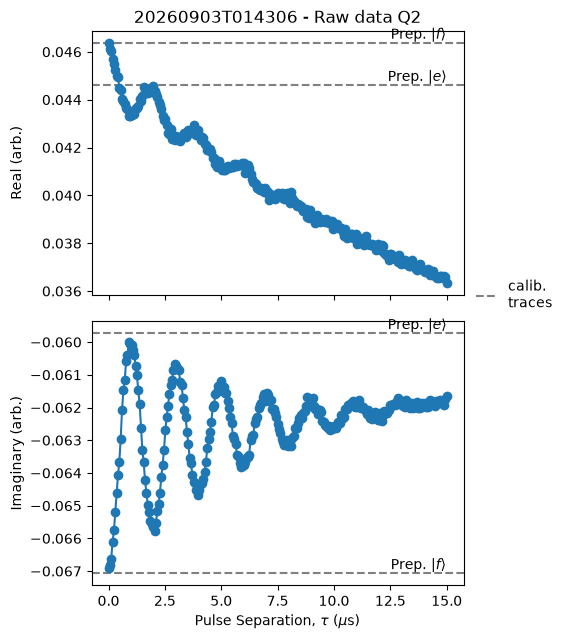

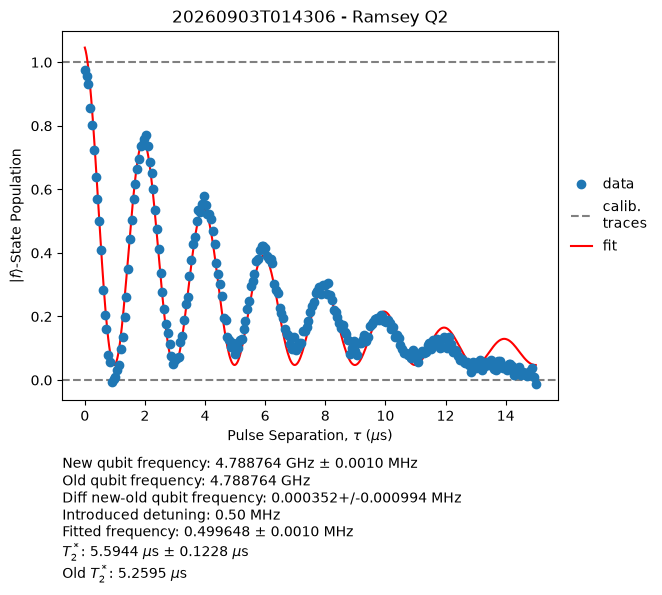

In [300]:
options = ramsey.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Ramsey in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
# qubits_to_measure = [qubits[0], qubits[2]]
qubits_to_measure = [qubits[0]]

delays = [
    np.linspace(delay_min, delay_max, n_delay)
]
detunings = [
    detuning
]

exp_workflow = ramsey.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    detunings=detunings,
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [301]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

ramsey.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("\nge_T2_star: ", qubit_to_measure.parameters.ge_T2_star)
    print("resonance_frequency_ge: ", qubit_to_measure.parameters.resonance_frequency_ge)
elif transition == 'ef':
    print("\nef_T2_star: ", qubit_to_measure.parameters.ef_T2_star)
    print("resonance_frequency_ef: ", qubit_to_measure.parameters.resonance_frequency_ef)
    
if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ef_T2_star': 5.594394899111066e-06+/-1.2276582555167267e-07,
                                 'resonance_frequency_ef': 4788764299.046252+/-993.9455761217711}},
 'old_parameter_values': {'Q2': {'ef_T2_star': 5.259528680356951e-06,
                                 'resonance_frequency_ef': 4788763947.087763}}}

ef_T2_star:  5.594394899111066e-06
resonance_frequency_ef:  4788764299.046252

Updated global experiment parameters!



### Rabi Error Amplification <a class="anchor" id="rabi-error-amplification-ef"></a>

#### x180 pulse

##### Experiment Parameters

In [313]:
update_global_parameters = True

transition = set_transition('ef')

n_avg_exponent = 13

x180_max_repetitions = 16
x180_repetitions = list(range(0, x180_max_repetitions + 1))

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

##### Run Workflow

[2026.09.03 02:16:17.896] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 02:16:17.909] INFO      Workflow 'experiment_workflow_x180': execution started at 2026-09-02          
[2026.09.03 02:16:17.912] INFO      23:16:17.896476Z                                                              
[2026.09.03 02:16:17.915] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 02:16:18.460] INFO    Task 'temporary_qpu': started at 2026-09-02 23:16:18.460420Z
[2026.09.03 02:16:18.602] INFO    Task 'temporary_qpu': ended at 2026-09-02 23:16:18.602376Z
[2026.09.03 02:16:18.825] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-02 
[2026.09.03 02:16:18.827] INFO    23:16:18.825012Z
[2026.09.03 02:16:18.945] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-02 23:16:18.945315Z
[2026.09.03 02:16:19.182] INFO    Task 'create_experiment': started at 2026-09-02 23:

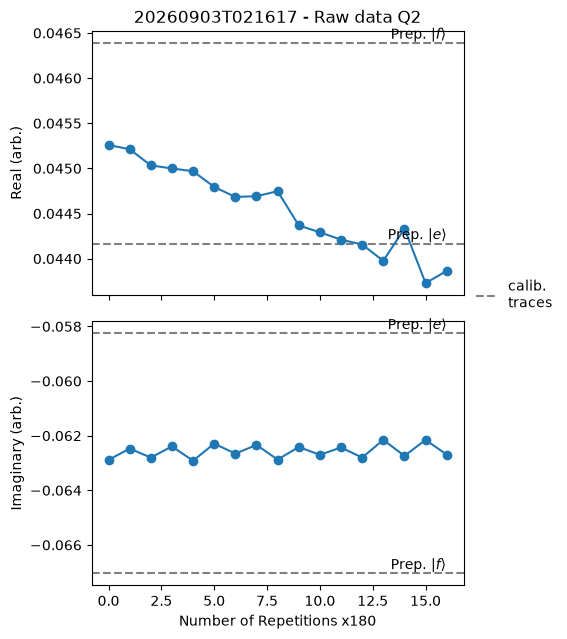

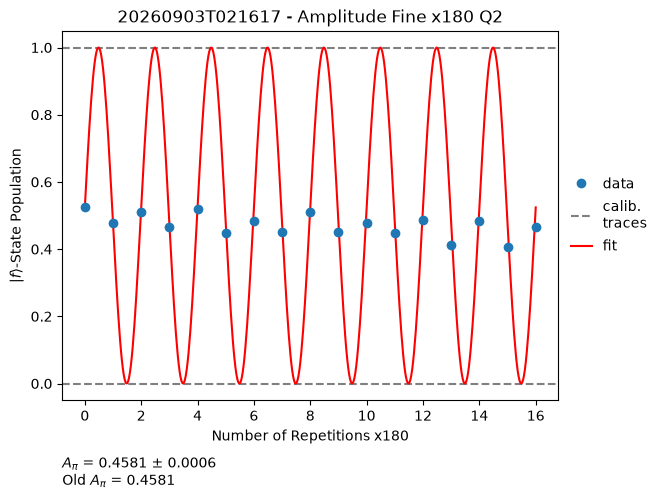

In [314]:
options = amplitude_fine.experiment_workflow_x180.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_fine.experiment_workflow_x180(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    repetitions=[x180_repetitions for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

##### Update Parameters

In [315]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

amplitude_fine.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("\nDrive amplitude pi ge (error-amplified): ", qubit_to_measure.parameters.ge_drive_amplitude_pi)
elif transition == 'ef':
    print("\nDrive amplitude pi ef (error-amplified): ", qubit_to_measure.parameters.ef_drive_amplitude_pi)
    
if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ef_drive_amplitude_pi': 0.45806870360167845+/-0.0005626409950191324}},
 'old_parameter_values': {'Q2': {'ef_drive_amplitude_pi': 0.458080194050972}}}

Drive amplitude pi ef (error-amplified):  0.45806870360167845

Updated global experiment parameters!



#### x90 pulse

##### Experiment Parameters

In [419]:
update_global_parameters = True

transition = set_transition('ef')

n_avg_exponent = 13

x90_max_repetitions = 16
x90_repetitions = list(range(0, x90_max_repetitions + 1, 2))

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

##### Run Workflow

[2026.09.03 12:45:10.094] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 12:45:10.095] INFO      Workflow 'experiment_workflow_x90': execution started at 2026-09-03           
[2026.09.03 12:45:10.095] INFO      09:45:10.094751Z                                                              
[2026.09.03 12:45:10.095] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 12:45:10.311] INFO    Task 'temporary_qpu': started at 2026-09-03 09:45:10.311310Z
[2026.09.03 12:45:10.350] INFO    Task 'temporary_qpu': ended at 2026-09-03 09:45:10.350146Z
[2026.09.03 12:45:10.430] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-03 
[2026.09.03 12:45:10.431] INFO    09:45:10.427855Z
[2026.09.03 12:45:10.465] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-03 09:45:10.465771Z
[2026.09.03 12:45:10.537] INFO    Task 'create_experiment': started at 2026-09-03 09:

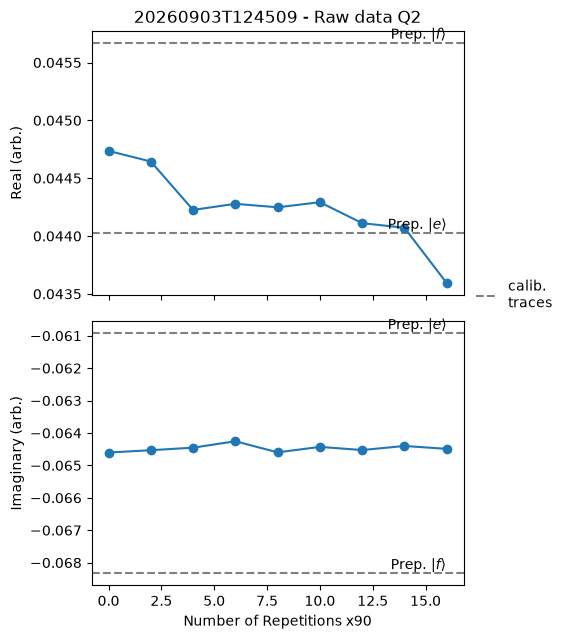

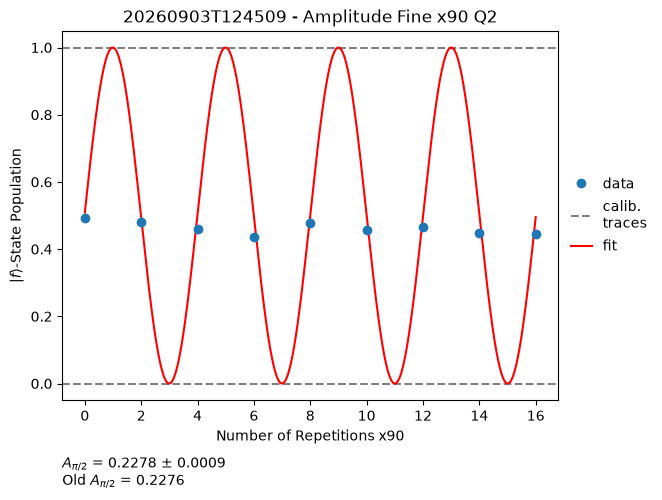

In [420]:
options = amplitude_fine.experiment_workflow_x90.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = amplitude_fine.experiment_workflow_x90(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    repetitions=[x90_repetitions for q in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters
)
workflow_result = exp_workflow.run()

##### Update Parameters

In [421]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

amplitude_fine.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("\nDrive amplitude pi2 ge (error-amplified): ", qubit_to_measure.parameters.ge_drive_amplitude_pi2)
elif transition == 'ef':
    print("\nDrive amplitude pi2 ef (error-amplified): ", qubit_to_measure.parameters.ef_drive_amplitude_pi2)
    
if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ef_drive_amplitude_pi2': 0.2278262819593706+/-0.0008715242575224341}},
 'old_parameter_values': {'Q2': {'ef_drive_amplitude_pi2': 0.22758370573182768}}}

Drive amplitude pi2 ef (error-amplified):  0.2278262819593706

Updated global experiment parameters!



### DRAG Calibration <a class="anchor" id="drag-calibration-ef"></a>

#### Experiment Parameters

In [362]:
update_global_parameters = True

transition = set_transition('ef')

# readout_range_out = -30

n_avg_exponent = 13

q_min = -0.1
q_max = 0.1
n_q = 61

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
# temp_pars.readout_range_out = readout_range_out
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.09.03 03:20:03.006] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 03:20:03.006] INFO      Workflow 'drag_q_scaling': execution started at 2026-09-03 00:20:03.006494Z   
[2026.09.03 03:20:03.006] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 03:20:03.353] INFO    Task 'temporary_qpu': started at 2026-09-03 00:20:03.353349Z
[2026.09.03 03:20:03.412] INFO    Task 'temporary_qpu': ended at 2026-09-03 00:20:03.412431Z
[2026.09.03 03:20:03.534] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-03 
[2026.09.03 03:20:03.537] INFO    00:20:03.534129Z
[2026.09.03 03:20:03.600] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-03 00:20:03.600083Z
[2026.09.03 03:20:03.719] INFO    Task 'create_experiment': started at 2026-09-03 00:20:03.719758Z
[2026.09.03 03:20:03.897] INFO    Task 'create_experiment': ended at 2026-09-03 00:20:03.897180Z
[202

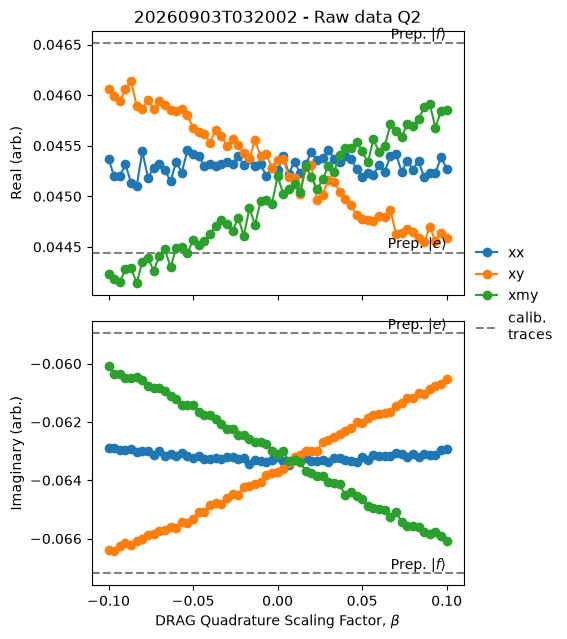

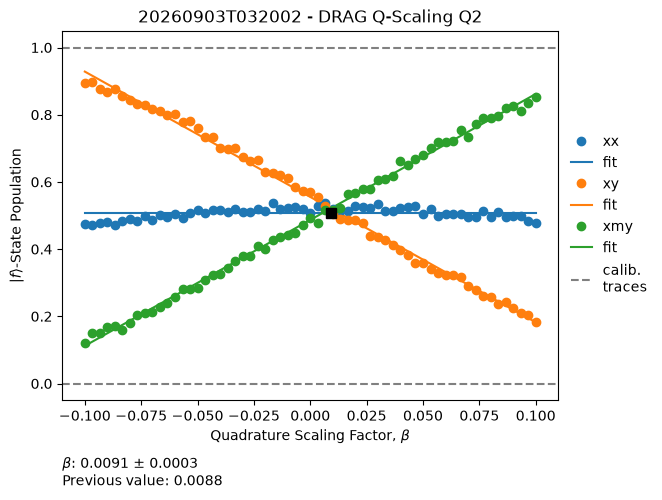

In [363]:
options = drag_q_scaling.experiment_workflow.options()
# options.update(True)  # updates the qubit parameter 'ge_drive_pulse["beta"]'
options.count(2**n_avg_exponent)
options.close_figures(False) # Plot figures

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubits[0]]

exp_workflow = drag_q_scaling.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    q_scalings=[np.linspace(q_min, q_max, n_q) for _ in qubits_to_measure],
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

#### Update Parameters

In [364]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

drag_q_scaling.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("\nge_drive_pulse[beta]: ", qubit_to_measure.parameters.ge_drive_pulse["beta"])
elif transition == 'ef':
    print("\nef_drive_pulse[beta]: ", qubit_to_measure.parameters.ef_drive_pulse["beta"])
    
if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ef_drive_pulse.beta': 0.00913759889208687+/-0.00030054635725385053}},
 'old_parameter_values': {'Q2': {'ef_drive_pulse.beta': 0.008814800159816056}}}

ef_drive_pulse[beta]:  0.00913759889208687

Updated global experiment parameters!



### Hahn-Echo <a class="anchor" id="hahn-echo-ef"></a>

#### Experiment Parameters

In [373]:
update_global_parameters = True

transition = set_transition('ef')

n_avg_exponent = 13

delay_min = 0
delay_max = 15e-6
n_delay = 51
log_spacing = True

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
temporary_parameters[q.uid] = temp_pars

#### Run Workflow

[2026.09.03 03:39:04.727] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 03:39:04.727] INFO      Workflow 'echo': execution started at 2026-09-03 00:39:04.727453Z             
[2026.09.03 03:39:04.727] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 03:39:05.068] INFO    Task 'temporary_qpu': started at 2026-09-03 00:39:05.068398Z
[2026.09.03 03:39:05.146] INFO    Task 'temporary_qpu': ended at 2026-09-03 00:39:05.146688Z
[2026.09.03 03:39:05.229] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-03 
[2026.09.03 03:39:05.229] INFO    00:39:05.229528Z
[2026.09.03 03:39:05.278] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-03 00:39:05.277047Z
[2026.09.03 03:39:05.371] INFO    Task 'create_experiment': started at 2026-09-03 00:39:05.369608Z
[2026.09.03 03:39:05.487] INFO    Task 'create_experiment': ended at 2026-09-03 00:39:05.487296Z
[202

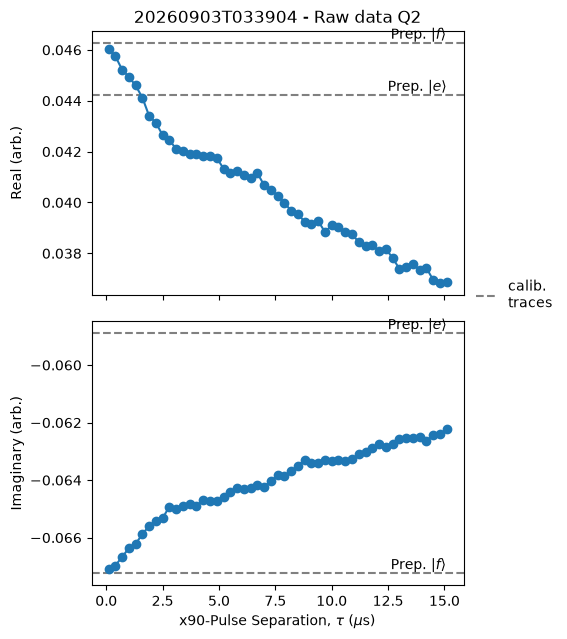

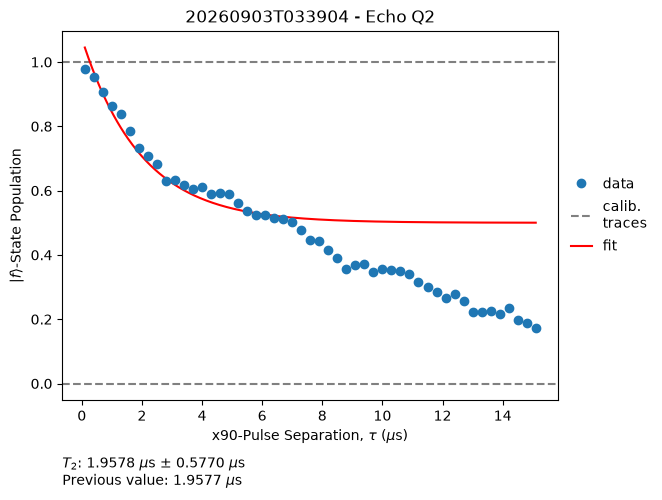

In [374]:
options = echo.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False)

options.transition(transition)
options.cal_states(transition)

# Note: if neighbouring qubits are physically coupled by a resonator,
# you usually don't want to run Echo in parallel on them because
# your result will be skewed by strong residual-ZZ coupling.
# Next-nearest neighbours is typically okay.
qubits_to_measure = [qubits[0]]

delays = [
    np.linspace(delay_min, delay_max, n_delay)
]

exp_workflow = echo.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[q.uid for q in qubits_to_measure],
    delays=delays,
    options=options,
    temporary_parameters=temporary_parameters
)

workflow_result = exp_workflow.run()

#### Update Parameters

In [375]:
analysis_workflow_result = workflow_result.tasks["analysis_workflow"]
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])

echo.update_qpu(qpu, qubit_parameters["new_parameter_values"])
if transition == 'ge':
    print("\nge_T2: ", qubit_to_measure.parameters.ge_T2)
elif transition == 'ef':
    print("\nef_T2: ", qubit_to_measure.parameters.ef_T2)
    
if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'ef_T2': 1.957837104913142e-06+/-5.770277092807093e-07}},
 'old_parameter_values': {'Q2': {'ef_T2': 1.9576717091472246e-06}}}

ef_T2:  1.957837104913142e-06

Updated global experiment parameters!



In [376]:
qpu.quantum_elements

[TunableTransmonQubit(
│   uid='Q2',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=1.0433416889865267e-05,
│   │   ge_T2=1.659788521169252e-05,
│   │   ge_T2_star=7.741290835250325e-06,
│   │   ef_T1=5.161184727745047e-06,
│   │   ef_T2=1.957837104913142e-06,
│   │   ef_T2_star=5.594394899111066e-06,
│   │   drive_lo_frequency=4800000000.0,
│   │   readout_lo_frequency=6000000000.0,
│   │   resonance_frequency_ge=5008681684.374855,
│   │   resonance_frequency_ef=4788764299.046252,
│   │   readout_resonator_frequency=5959972000.0,
│   │   ge_drive_amplitude_pi=0.3352897014347527,
│   │   ge_drive_amplitude_pi2=0.1647637202464873,
│   │   ge_drive_length=2e-07,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0.009337457823820674,
│   │   │   'sigma': 0.25
│   │   },
│   │   ef_d

# Readout Optimisation <a class="anchor" id="readout-optimisation"></a>

Optimization of the readout pulse amplitude and of the readout (resonator)
frequency.

1. **Readout Amplitude Optimization** — sweep the readout amplitude and run an
   amplitude-Rabi experiment at each amplitude. The readout amplitude with the
   smallest relative Rabi-fit errors gives the best signal-to-noise ratio.
2. **Dispersive Shift** — resonator spectroscopy with the qubit prepared in
   g, e (and f). The optimal readout frequency is the frequency of the largest
   distance between the transmission signals of the different states.
3. **Readout Settings Summary** — write the optimized readout parameters into
   the QPU and save them.

## Readout Amplitude Optimisation

#### Experiment Parameters

In [422]:
update_global_parameters = False

transition = set_transition('ge')

n_avg_exponent = 13

# readout setting used during the sweep
# readout_range_out = -30
# readout_range_in = -40
readout_length = 2e-6
readout_integration_length = 2e-6
readout_integration_delay = 80e-9
reset_delay_length = 300e-6

# length and amplitude are taken from readout_length / readout_amplitude
readout_pulse = {
    'function': 'gaussian_square',
    'width': readout_length * 0.95,
}

# readout amplitude sweep
ro_amp_min = 0.0
ro_amp_max = 1.0
n_ro_amp = 21
ro_amp_arr = np.linspace(ro_amp_min, ro_amp_max, n_ro_amp)

# rabi sweep used to benchmark each readout amplitude
drive_range = 5
amp_min = 0
amp_max = 1
n_amp = 21
drive_amplitudes = np.linspace(amp_min, amp_max, n_amp)

qubit_to_measure = qubits[0]

#### Run Workflow

In [423]:
options = amplitude_rabi.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.update(False) # never update the qubit parameters during the sweep
options.close_figures(True) # one Rabi figure per readout amplitude

options.transition(transition)
options.cal_states(transition)

qubits_to_measure = [qubit_to_measure]

rabi_ro_sweep_results = []
fit_values_ro_sweep = []
fit_errors_ro_sweep = []
# same order as the old popt/pcov of fit_Rabi
fit_parameter_names = ['frequency', 'phase', 'amplitude', 'offset']

for ro_amp in ro_amp_arr:
    print('Measure at readout amplitude:', round(ro_amp, 5))

    temporary_parameters = {}
    temp_pars = deepcopy(qubits[0].parameters)
    temp_pars.readout_amplitude = round(ro_amp, 5)
    temp_pars.readout_length = readout_length
    temp_pars.readout_pulse = readout_pulse
    temp_pars.readout_integration_length = readout_integration_length
    temp_pars.readout_integration_delay = readout_integration_delay
    # temp_pars.readout_range_out = readout_range_out
    # temp_pars.readout_range_in = readout_range_in
    temp_pars.reset_delay_length = reset_delay_length
    temp_pars.drive_range = drive_range
    temporary_parameters[qubit_to_measure.uid] = temp_pars

    exp_workflow = amplitude_rabi.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[q.uid for q in qubits_to_measure],
        amplitudes=[drive_amplitudes for q in qubits_to_measure],
        options=options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result = exp_workflow.run()
    rabi_ro_sweep_results.append(workflow_result)

    # rotates/projects the raw data and fits a cosine model to the population
    fit_results = get_analysis_task_output(workflow_result, 'fit_data')
    fit_res = fit_results.get(qubit_to_measure.uid)
    if fit_res is None:
        print(f'  Rabi fit failed at readout amplitude {round(ro_amp, 5)}.')
        fit_values_ro_sweep.append([np.nan] * len(fit_parameter_names))
        fit_errors_ro_sweep.append([np.nan] * len(fit_parameter_names))
        continue

    fit_values_ro_sweep.append([fit_res.params[p].value for p in fit_parameter_names])
    fit_errors_ro_sweep.append([fit_res.params[p].stderr for p in fit_parameter_names])

popt_rabi_arr = np.array(fit_values_ro_sweep, dtype=float)
err_arr = np.array(fit_errors_ro_sweep, dtype=float)

Measure at readout amplitude: 0.0
[2026.09.03 12:54:06.540] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 12:54:06.540] INFO      Workflow 'amplitude_rabi': execution started at 2026-09-03 09:54:06.540865Z   
[2026.09.03 12:54:06.540] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 12:54:06.820] INFO    Task 'temporary_qpu': started at 2026-09-03 09:54:06.814249Z
[2026.09.03 12:54:06.886] INFO    Task 'temporary_qpu': ended at 2026-09-03 09:54:06.886899Z
[2026.09.03 12:54:06.991] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-03 
[2026.09.03 12:54:06.997] INFO    09:54:06.991693Z
[2026.09.03 12:54:07.053] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-03 09:54:07.039113Z
[2026.09.03 12:54:07.167] INFO    Task 'create_experiment': started at 2026-09-03 09:54:07.167608Z
[2026.09.03 12:54:07.303] INFO    Task 'create_experiment': ended a

#### Update Parameters

Optimal readout amplitude: 0.2


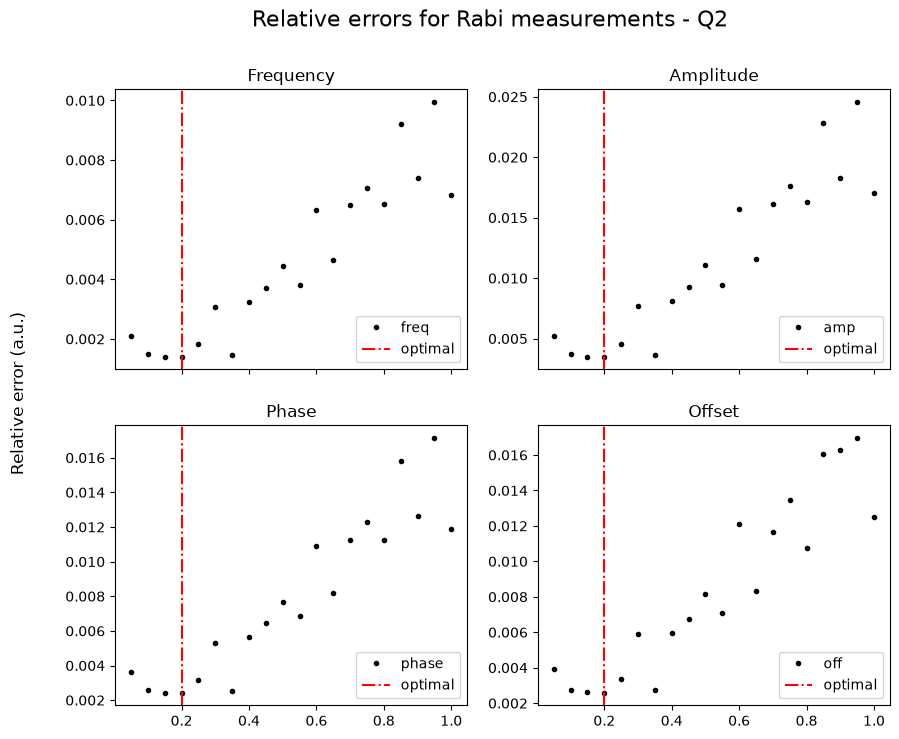

In [424]:
ll = 1 # skip readout amplitude 0 (no s"ignal)
ul = None
sweep_slice = slice(ll, ul)

# lmfit reports stderr = 0 when the covariance matrix could not be estimated;
# treat those points as invalid instead of "perfect".
err_arr[err_arr == 0] = np.nan
rel_err_arr = np.abs(err_arr / popt_rabi_arr)
fig, ax = plt.subplots(2, 2, sharex=True, figsize=(10, 8))
fig.suptitle(f'Relative errors for Rabi measurements - {qubit_to_measure.uid}', fontsize=16)
fig.supylabel('Relative error (a.u.)')

ax[0, 0].plot(ro_amp_arr[sweep_slice], rel_err_arr[sweep_slice, 0], '.k', label='freq')
ax[1, 0].plot(ro_amp_arr[sweep_slice], rel_err_arr[sweep_slice, 1], '.k', label='phase')
ax[0, 1].plot(ro_amp_arr[sweep_slice], rel_err_arr[sweep_slice, 2], '.k', label='amp')
ax[1, 1].plot(ro_amp_arr[sweep_slice], rel_err_arr[sweep_slice, 3], '.k', label='off')

ax[0, 0].set_title('Frequency')
ax[1, 0].set_title('Phase')
ax[0, 1].set_title('Amplitude')
ax[1, 1].set_title('Offset')

# optimal readout amplitude: smallest mean relative fit error.
mean_rel_err = np.nanmean(rel_err_arr, axis=1)
masked_rel_err = np.full(mean_rel_err.shape, np.nan)
masked_rel_err[sweep_slice] = mean_rel_err[sweep_slice]
optimal_index = int(np.nanargmin(masked_rel_err))
readout_amplitude_opt = float(ro_amp_arr[optimal_index])

for axis in ax.flatten():
    axis.axvline(x=readout_amplitude_opt, ls='-.', color='r', label='optimal')
    axis.legend()

print('Optimal readout amplitude:', round(readout_amplitude_opt, 5))

figname = f'Rabi_optimiz_{readout_range_out}dBm_'
file_path = get_path_to_file(figname, '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [380]:
# set to a value != None to override the value extracted above.
manual_readout_amplitude = None
if manual_readout_amplitude is not None:
    readout_amplitude_opt = float(manual_readout_amplitude)

if update_global_parameters:
    temporary_parameters[qubit_to_measure.uid].readout_amplitude = readout_amplitude_opt
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

print('Readout amplitude: ', qubit_to_measure.parameters.readout_amplitude)
print('Readout length: ', qubit_to_measure.parameters.readout_length)
print('Readout pulse: ', qubit_to_measure.parameters.readout_pulse)
print('Readout integration length: ', qubit_to_measure.parameters.readout_integration_length)
print('Readout integration delay: ', qubit_to_measure.parameters.readout_integration_delay)
print('Readout range out / in: ', qubit_to_measure.parameters.readout_range_out,
      '/', qubit_to_measure.parameters.readout_range_in)

Readout amplitude:  0.2
Readout length:  2e-06
Readout pulse:  {'function': 'const'}
Readout integration length:  2e-06
Readout integration delay:  8e-08
Readout range out / in:  -20 / -40


In [381]:
qpu.quantum_elements

[TunableTransmonQubit(
│   uid='Q2',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=1.0433416889865267e-05,
│   │   ge_T2=1.659788521169252e-05,
│   │   ge_T2_star=7.741290835250325e-06,
│   │   ef_T1=5.161184727745047e-06,
│   │   ef_T2=1.957837104913142e-06,
│   │   ef_T2_star=5.594394899111066e-06,
│   │   drive_lo_frequency=4800000000.0,
│   │   readout_lo_frequency=6000000000.0,
│   │   resonance_frequency_ge=5008681684.374855,
│   │   resonance_frequency_ef=4788764299.046252,
│   │   readout_resonator_frequency=5959972000.0,
│   │   ge_drive_amplitude_pi=0.3352897014347527,
│   │   ge_drive_amplitude_pi2=0.1647637202464873,
│   │   ge_drive_length=2e-07,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0.009337457823820674,
│   │   │   'sigma': 0.25
│   │   },
│   │   ef_d

## Dispersive Shift

#### Experiment Parameters

In [425]:
update_global_parameters = True

states = 'gef'

n_avg_exponent = 13

freq_range = 2e6
n_points = 201

# TODO
# readout_amplitude = 0.2
# readout_range_out = -30
# readout_range_in = -35
# reset_delay_length = 150e-6

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
# temp_pars.readout_amplitude = readout_amplitude
# temp_pars.readout_range_out = readout_range_out
# temp_pars.readout_range_in = readout_range_in
# temp_pars.reset_delay_length = reset_delay_length
temporary_parameters[qubits[0].uid] = temp_pars

#### Run Workflow

[2026.09.03 13:17:04.858] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 13:17:04.858] INFO      Workflow 'dispersive_shift': execution started at 2026-09-03                  
[2026.09.03 13:17:04.858] INFO      10:17:04.858369Z                                                              
[2026.09.03 13:17:04.858] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 13:17:05.147] INFO    Task 'temporary_qpu': started at 2026-09-03 10:17:05.147920Z
[2026.09.03 13:17:05.199] INFO    Task 'temporary_qpu': ended at 2026-09-03 10:17:05.199583Z
[2026.09.03 13:17:05.322] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-03 
[2026.09.03 13:17:05.322] INFO    10:17:05.322684Z
[2026.09.03 13:17:05.354] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-03 10:17:05.354573Z
[2026.09.03 13:17:05.419] INFO    Task 'create_experiment': started at 2026-09-03 10:

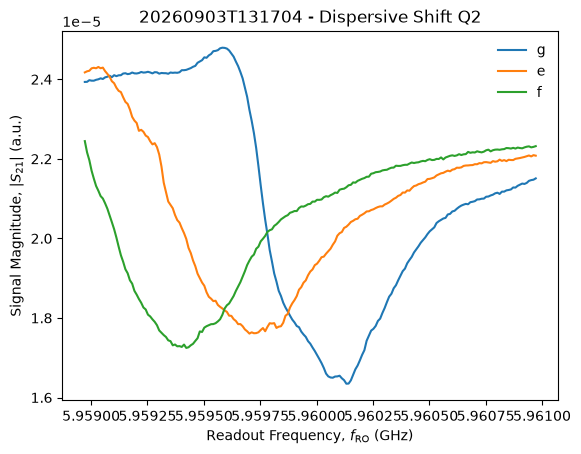

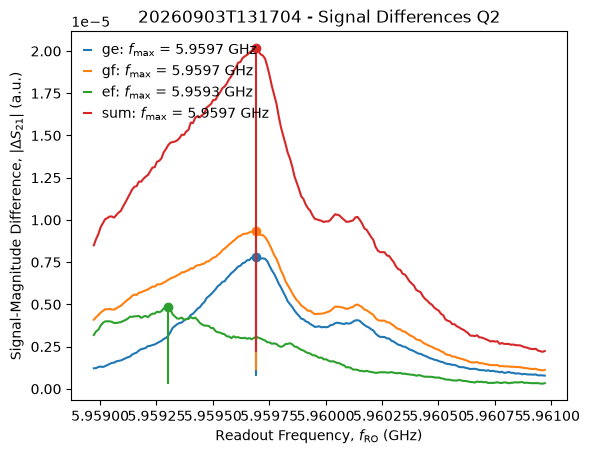

In [426]:
options = dispersive_shift.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.update(False)  # updated explicitly below
options.close_figures(False)

qubit_to_measure = qubits[0]

frequencies = temporary_parameters[
    qubit_to_measure.uid
].readout_resonator_frequency + np.linspace(-freq_range / 2, freq_range / 2, n_points)

exp_workflow = dispersive_shift.experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    frequencies=frequencies,
    states=states,
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

#### Analysis Plots

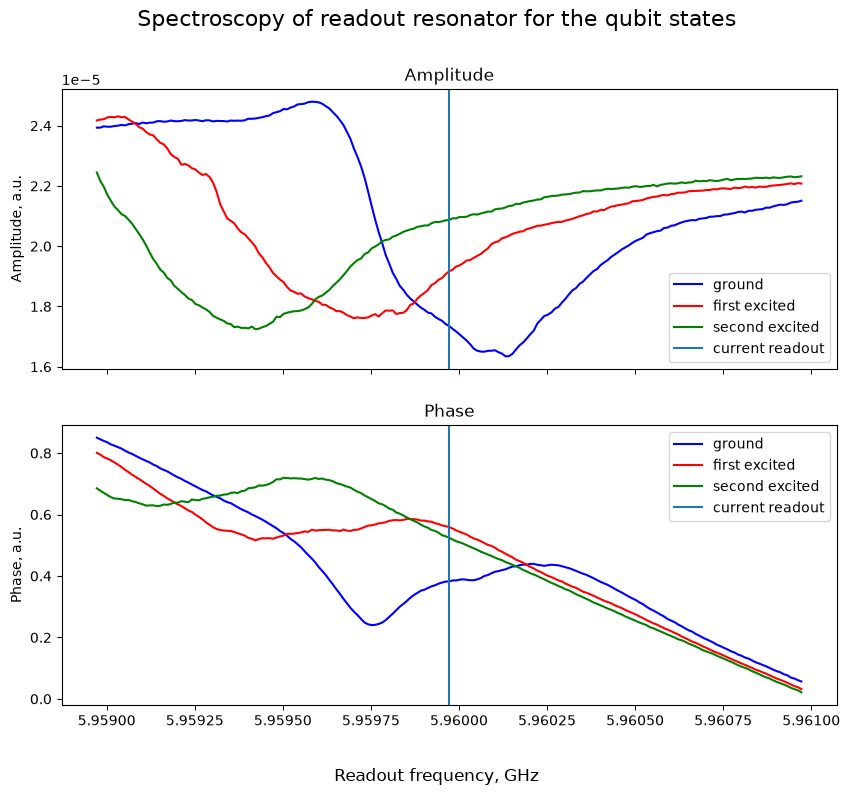

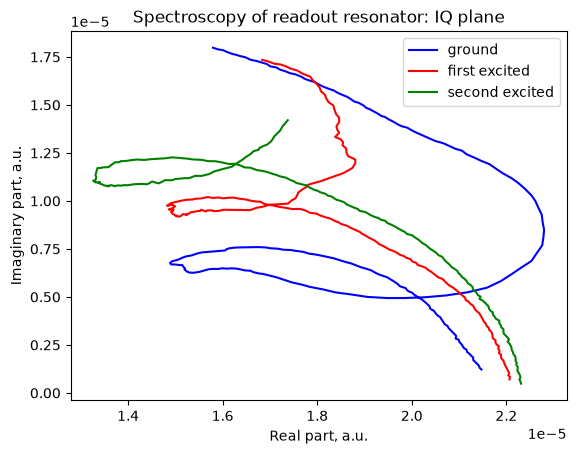

In [427]:
result = workflow_result.output
res_data = {
    state: result[dsl.handles.result_handle(qubit_to_measure.uid, suffix=state)].data
    for state in states
}
res_freq = frequencies

state_labels = {'g': 'ground', 'e': 'first excited', 'f': 'second excited'}
state_colors = {'g': 'b', 'e': 'r', 'f': 'g'}

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
fig.suptitle('Spectroscopy of readout resonator for the qubit states', fontsize=16)
fig.supxlabel('Readout frequency, GHz')

ax[0].set_title('Amplitude')
ax[1].set_title('Phase')

for state, data in res_data.items():
    ax[0].plot(res_freq * 1e-9, np.abs(data), state_colors[state], label=state_labels[state])
    ax[1].plot(res_freq * 1e-9, np.unwrap(np.angle(data)), state_colors[state],
               label=state_labels[state])

for axis, ylabel in zip(ax, ['Amplitude, a.u.', 'Phase, a.u.']):
    axis.axvline(x=qubit_to_measure.parameters.readout_resonator_frequency * 1e-9,
                 label='current readout')
    axis.set_ylabel(ylabel)
    axis.legend()

file_path = get_path_to_file('Readout_spec_for_g_e', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

fig_iq, ax_iq = plt.subplots()
ax_iq.set_title('Spectroscopy of readout resonator: IQ plane')
for state, data in res_data.items():
    ax_iq.plot(data.real, data.imag, state_colors[state], label=state_labels[state])
ax_iq.set_xlabel('Real part, a.u.')
ax_iq.set_ylabel('Imaginary part, a.u.')
ax_iq.legend()

file_path = get_path_to_file('Readout_spec_for_g_e_IQ', '.png')
fig_iq.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

ge: max distance 7.792e-06 at 5.959692 GHz
gf: max distance 9.316e-06 at 5.959692 GHz
ef: max distance 4.838e-06 at 5.959302 GHz
sum: max distance 2.02e-05 at 5.959692 GHz


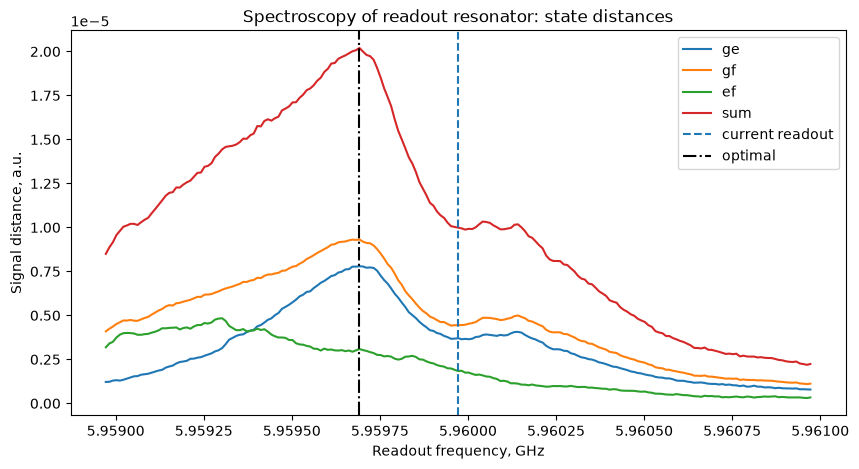

In [428]:
processed_data_dict = get_analysis_task_output(workflow_result, 'calculate_signal_differences')

fig_dist, ax_dist = plt.subplots(figsize=(10, 5))
ax_dist.set_title('Spectroscopy of readout resonator: state distances')
for state_pair, (distance, max_distance, freq_at_max) in processed_data_dict.items():
    ax_dist.plot(res_freq * 1e-9, distance, label=state_pair)
    print(f'{state_pair}: max distance {max_distance:.4g} at '
          f'{freq_at_max * 1e-9:.6f} GHz')

ax_dist.axvline(x=qubit_to_measure.parameters.readout_resonator_frequency * 1e-9,
                ls='--', label='current readout')
ax_dist.axvline(x=processed_data_dict['sum' if 'sum' in processed_data_dict else
                                      next(iter(processed_data_dict))][2] * 1e-9,
                ls='-.', color='k', label='optimal')
ax_dist.set_xlabel('Readout frequency, GHz')
ax_dist.set_ylabel('Signal distance, a.u.')
ax_dist.legend()

file_path = get_path_to_file('Readout_spec_for_g_e_distance', '.png')
fig_dist.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [429]:
analysis_workflow_result = workflow_result.tasks['analysis_workflow']
qubit_parameters = analysis_workflow_result.output
pprint(qubit_parameters)

readout_resonator_frequency_opt = float(
    qubit_parameters['new_parameter_values'][qubit_to_measure.uid][
        'readout_resonator_frequency'
    ]
)

manual_readout_resonator_frequency = None
if manual_readout_resonator_frequency is not None:
    readout_resonator_frequency_opt = float(manual_readout_resonator_frequency)
    qubit_parameters['new_parameter_values'][qubit_to_measure.uid][
        'readout_resonator_frequency'
    ] = readout_resonator_frequency_opt

print(f'ro freq opt: {readout_resonator_frequency_opt * 1e-9:.6f} GHz')

if update_global_parameters:
    temporary_parameters[qubit_to_measure.uid].readout_resonator_frequency = (
        readout_resonator_frequency_opt
    )
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    dispersive_shift.update_qpu(qpu, qubit_parameters['new_parameter_values'])

print('Readout resonator frequency: ',
      qubit_to_measure.parameters.readout_resonator_frequency * 1e-9, ' GHz')

if update_global_parameters:
    save(qpu, qpu_file_path)
    print('\nUpdated global experiment parameters!\n')

{'new_parameter_values': {'Q2': {'readout_resonator_frequency': np.float64(5959692000.0)}},
 'old_parameter_values': {'Q2': {'readout_resonator_frequency': 5959972000.0}}}
ro freq opt: 5.959692 GHz

Updated global experiment parameters!

Readout resonator frequency:  5.959692  GHz


In [430]:
data_gef_spec = {'freq': res_freq}
for state, data in res_data.items():
    data_gef_spec[f'{state}_res'] = data
    data_gef_spec[f'{state}_freq'] = res_freq
data_gef_spec.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_gef_spec['sample_name'] = sample_name
data_gef_spec['qubit_name'] = qubit_name
data_gef_spec['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('ge_spec_readout_', '.mat')
savemat(file_path, data_gef_spec)
print(f'Saved gef readout spectroscopy to: {file_path}')

Saved gef readout spectroscopy to: N:\xld\qubit_thermometry_v2\ES-009-DE_1-2_9150\COOLDOWN_2026-09-02\Q2\20260903_141346_ge_spec_readout_.mat


In [431]:
readout_opt = {
    'readout_amplitude': qubit_to_measure.parameters.readout_amplitude,
    'readout_length': qubit_to_measure.parameters.readout_length,
    'readout_pulse': qubit_to_measure.parameters.readout_pulse,
    'readout_integration_length': qubit_to_measure.parameters.readout_integration_length,
    'readout_integration_delay': qubit_to_measure.parameters.readout_integration_delay,
    'readout_integration_kernels_type':
        qubit_to_measure.parameters.readout_integration_kernels_type,
    'readout_resonator_frequency': qubit_to_measure.parameters.readout_resonator_frequency,
    'readout_lo_frequency': qubit_to_measure.parameters.readout_lo_frequency,
    'readout_range_out': qubit_to_measure.parameters.readout_range_out,
    'readout_range_in': qubit_to_measure.parameters.readout_range_in,
    'reset_delay_length': qubit_to_measure.parameters.reset_delay_length,
}
pprint(readout_opt)

{'readout_amplitude': 0.2,
 'readout_integration_delay': 8e-08,
 'readout_integration_kernels_type': 'default',
 'readout_integration_length': 2e-06,
 'readout_length': 2e-06,
 'readout_lo_frequency': 6000000000.0,
 'readout_pulse': {'function': 'const'},
 'readout_range_in': -40,
 'readout_range_out': -20,
 'readout_resonator_frequency': np.float64(5959692000.0),
 'reset_delay_length': 0.0003}


In [432]:
qpu.quantum_elements

[TunableTransmonQubit(
│   uid='Q2',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=1.0433416889865267e-05,
│   │   ge_T2=1.659788521169252e-05,
│   │   ge_T2_star=7.741290835250325e-06,
│   │   ef_T1=5.161184727745047e-06,
│   │   ef_T2=1.957837104913142e-06,
│   │   ef_T2_star=5.594394899111066e-06,
│   │   drive_lo_frequency=4800000000.0,
│   │   readout_lo_frequency=6000000000.0,
│   │   resonance_frequency_ge=5008681684.374855,
│   │   resonance_frequency_ef=4788764299.046252,
│   │   readout_resonator_frequency=np.float64(5959692000.0),
│   │   ge_drive_amplitude_pi=0.3352897014347527,
│   │   ge_drive_amplitude_pi2=0.16594439910907385,
│   │   ge_drive_length=2e-07,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0.009337457823820674,
│   │   │   'sigma': 0.25
│   │   },

# Single Shot 0 and 1 Measurements <a class="anchor" id="single-shot-0-and-1-measurements"></a>

Single-shot (unaveraged) readout of the qubit prepared in g, e (and f).

1. **One Single Shot Measurement** — acquire the single shots for each prepared
   state, classify them with a linear discriminant, and quantify the readout
   with the state distance, the relative shot noise and the correct-state
   assignment fidelity.
2. **Single Shot vs. Drive Pulse Length** — repeat the measurement for a range
   of pi-pulse lengths (i.e. Rabi frequencies).
3. **Single Shot vs. Integration Length and Delay** — repeat the measurement
   for a range of integration delays and integration lengths at a fixed
   readout pulse.
4. **Single Shot vs. Readout Amplitude and Length** — repeat the measurement
   for a range of readout amplitudes and readout lengths.

The readout parameters optimized in `# Readout Optimization` are the starting
point here; the best settings found below are written back into the QPU.

## One Single Shot Measurement

#### Experiment Parameters

In [433]:
update_global_parameters = True

states = 'gef'

n_avg_exponent = 17

# TODO
# readout settings for the single shots
# readout_length = 2e-6
# readout_integration_length = 2e-6
# readout_amplitude = 0.2
# readout_integration_delay = 80e-9
# readout_range_out = -30
# readout_range_in = -40
# use a long value only if you want to see the thermal population;
# 500e-3 makes 2**17 shots per state extremely slow
# reset_delay_length = 300e-6

# length and amplitude come from readout_length / readout_amplitude.
# readout_pulse = {
#     'function': 'const',
# }

qubit_to_measure = qubits[0]

temporary_parameters = {}
temp_pars = deepcopy(qubits[0].parameters)
# temp_pars.readout_amplitude = readout_amplitude
# temp_pars.readout_length = readout_length
# temp_pars.readout_pulse = readout_pulse
# temp_pars.readout_integration_length = readout_integration_length
# temp_pars.readout_integration_delay = readout_integration_delay
# temp_pars.readout_range_out = readout_range_out
# temp_pars.readout_range_in = readout_range_in
# temp_pars.reset_delay_length = reset_delay_length
temporary_parameters[qubit_to_measure.uid] = temp_pars

print('Readout length:             ', temp_pars.readout_length)
print('Readout integration length: ', temp_pars.readout_integration_length)
print('Readout integration delay:  ', temp_pars.readout_integration_delay)
print('Readout amplitude:          ', temp_pars.readout_amplitude)
print('Reset delay length:         ', temp_pars.reset_delay_length)
print('Readout resonator frequency:', temp_pars.readout_resonator_frequency)
print('Number of shots per state:  ', 2**n_avg_exponent)

Readout length:              2e-06
Readout integration length:  2e-06
Readout integration delay:   8e-08
Readout amplitude:           0.2
Reset delay length:          0.0003
Readout resonator frequency: 5959692000.0
Number of shots per state:   131072


#### Run Workflow

[2026.09.03 14:14:29.769] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 14:14:29.769] INFO      Workflow 'iq_blobs': execution started at 2026-09-03 11:14:29.769331Z         
[2026.09.03 14:14:29.769] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 14:14:29.996] INFO    Task 'temporary_qpu': started at 2026-09-03 11:14:29.985510Z
[2026.09.03 14:14:30.049] INFO    Task 'temporary_qpu': ended at 2026-09-03 11:14:30.049932Z
[2026.09.03 14:14:30.150] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-03 
[2026.09.03 14:14:30.155] INFO    11:14:30.150259Z
[2026.09.03 14:14:30.210] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-03 11:14:30.210091Z
[2026.09.03 14:14:30.323] INFO    Task 'create_experiment': started at 2026-09-03 11:14:30.321515Z
[2026.09.03 14:14:30.454] INFO    Task 'create_experiment': ended at 2026-09-03 11:14:30.454054Z
[202

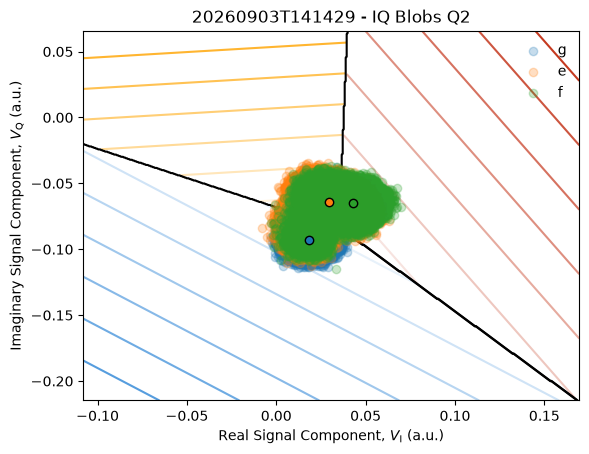

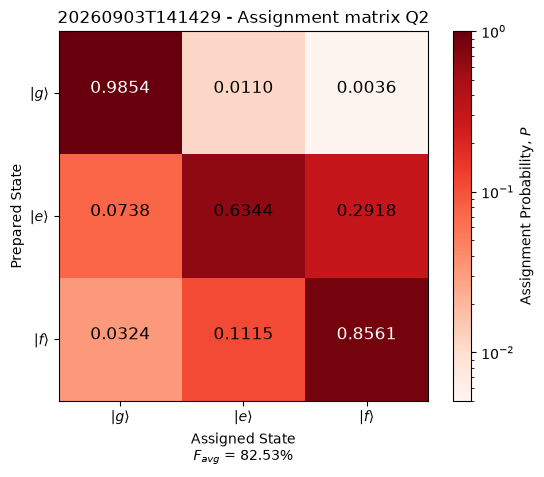

In [434]:
options = iq_blobs.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(False)
# the analysis classifies the shots with sklearn LinearDiscriminantAnalysis,
# replacing the manual LDA/PCA cells of the old notebook.
options.do_analysis(True)

exp_workflow = iq_blobs.experiment_workflow(
    session=session,
    qpu=qpu,
    qubits=[qubit_to_measure.uid],
    states=states,
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

#### Analysis Plots

In [435]:
result = workflow_result.output
shots_per_state = collect_shots_from_result(result, qubit_to_measure.uid, states)

# convenience aliases matching the old variable names
zero_data = shots_per_state['g']
one_data = shots_per_state['e']
two_data = shots_per_state.get('f')

shots_arr = np.array([shots_per_state[s] for s in states])
print('Shots array shape (states, shots):', shots_arr.shape)

state_labels = {'g': 'ground', 'e': 'first excited', 'f': 'second excited'}
state_colors = {'g': 'b', 'e': 'r', 'f': 'y'}
state_alphas = {'g': 0.1, 'e': 0.1, 'f': 0.01}

Shots array shape (states, shots): (3, 131072)


In [578]:
states = 'gef'

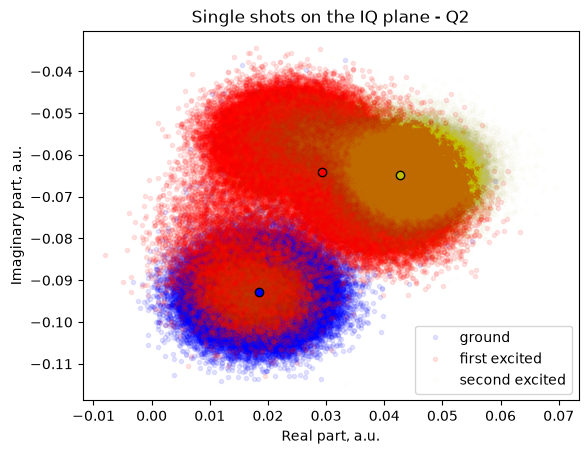

In [579]:
# plot measurement data on IQ, plus the state means
fig, ax = plt.subplots()
ax.set_title(f'Single shots on the IQ plane - {qubit_to_measure.uid}')
for s in states:
    data = shots_per_state[s]
    ax.plot(data.real, data.imag, '.', color=state_colors[s],
            alpha=state_alphas[s], label=state_labels[s])
for s in states:
    data = shots_per_state[s]
    ax.plot(np.mean(data.real), np.mean(data.imag), 'o',
            mfc=state_colors[s], mec='k')
ax.set_xlabel('Real part, a.u.')
ax.set_ylabel('Imaginary part, a.u.')
ax.legend()

# plt.xlim(-0.1, 0.12); plt.ylim(-0.25, 0.05) - set manually if needed
# ax.set_xlim(-0.1, 0.12)
# ax.set_ylim(-0.25, 0.05)

figname = 'Single_shot_points_'
file_path = get_path_to_file(figname, '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

State distance:           0.015419
Relative STD state 0:     0.4106
Relative STD state 1:     0.6847
Misassigned state-0 shots: 1917 / 131072
Assignment fidelity:      82.53 %
{'distance': np.float64(0.015419242410054261),
 'mean_0': np.complex128(-0.015419242410054258+8.222995851944748e-18j),
 'mean_1': np.complex128(0.01541924241005426-7.48099499014998e-18j),
 'n_assigned_0': 129155,
 'n_misassigned_0': 1917,
 'rel_std_0': np.float64(0.4106216850604293),
 'rel_std_1': np.float64(0.6846806556557913),
 'std_x_0': np.float64(0.006331475300771715),
 'std_x_1': np.float64(0.010557257003031536),
 'std_y_0': np.float64(0.005289488231881539),
 'std_y_1': np.float64(0.011018446812365195)}


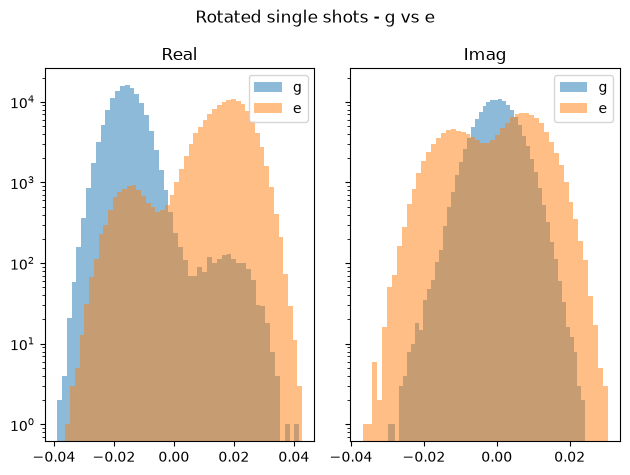

In [437]:
# analize_Single_Shots(SS_results, plot=True)
res_ss = analyze_single_shots(shots_per_state, state_0='g', state_1='e', plot=True)

# assignment matrix / fidelity are new: they come from the iq_blobs analysis
assignment_fidelities = workflow_result.tasks['analysis_workflow'].output
assignment_matrices = get_analysis_task_output(
    workflow_result, 'calculate_assignment_matrices'
)
assignment_fidelity = assignment_fidelities.get(qubit_to_measure.uid)

summarize_single_shot_metrics(res_ss, assignment_fidelity)
pprint({k: v for k, v in res_ss.items()
        if not isinstance(v, np.ndarray) and k != 'figure'})

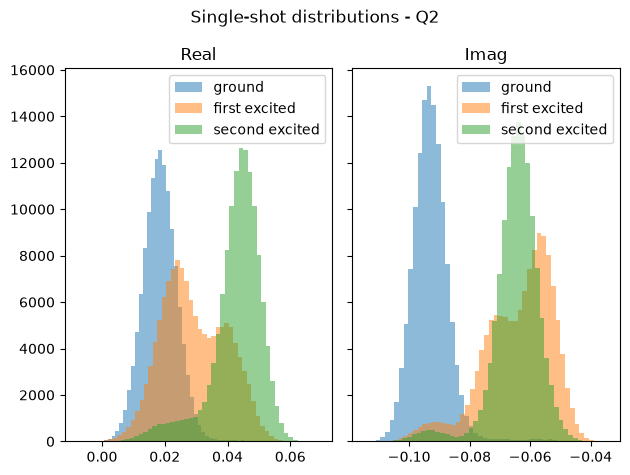

In [438]:
# plot the raw (unrotated) distributions
n_bins = 50

fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)
fig.suptitle(f'Single-shot distributions - {qubit_to_measure.uid}')

axs[0].set_title('Real')
axs[1].set_title('Imag')
for s in states:
    data = shots_per_state[s]
    axs[0].hist(data.real, bins=n_bins, alpha=0.5, label=state_labels[s])
    axs[1].hist(data.imag, bins=n_bins, alpha=0.5, label=state_labels[s])
axs[0].legend()
axs[1].legend()

figname = 'Single_shot_hist_'
file_path = get_path_to_file(figname, '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

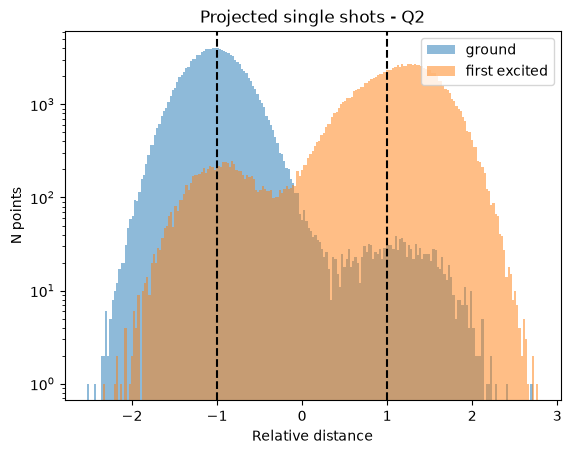

In [439]:
# relative-distance histogram of the projected shots
zero_data_proj = res_ss['shots_0_proj']
one_data_proj = res_ss['shots_1_proj']
r = res_ss['distance']

n_bins = 200

fig, ax = plt.subplots()
ax.set_title(f'Projected single shots - {qubit_to_measure.uid}')
ax.hist(zero_data_proj / r, bins=n_bins, alpha=0.5, label=state_labels['g'])
ax.hist(one_data_proj / r, bins=n_bins, alpha=0.5, label=state_labels['e'])
ax.axvline(1, color='k', ls='--')
ax.axvline(-1, color='k', ls='--')
ax.set_yscale('log')
ax.set_ylabel('N points')
ax.set_xlabel('Relative distance')
ax.legend()

mu: -0.9999999999999997  sigma: 0.4106201186600224


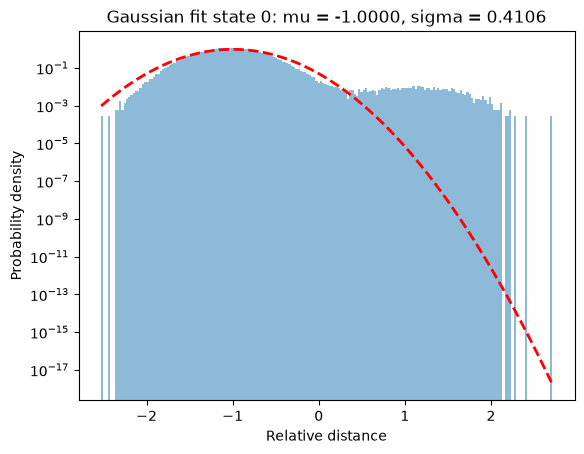

In [440]:
# single Gaussian fit of the projected state-0 shots
data = zero_data_proj / r

fig, ax = plt.subplots()
n, bins, patches = ax.hist(data, bins=n_bins, alpha=0.5, density=True)

(mu, sigma) = norm.fit(data)

# add a 'best fit' line
y = norm.pdf(bins, mu, sigma)
ax.plot(bins, y, 'r--', linewidth=2)
ax.set_yscale('log')
ax.set_ylabel('Probability density')
ax.set_xlabel('Relative distance')
ax.set_title(f'Gaussian fit state 0: mu = {mu:.4f}, sigma = {sigma:.4f}')
print('mu:', mu, ' sigma:', sigma)

             params      sigma
mu1       -0.302191   0.240376
sigma1    -0.938405   0.202301
A1       189.699111  14.866999
mu2        1.199874   0.005882
sigma2     0.449823   0.006831
A2      2635.738937  49.495358


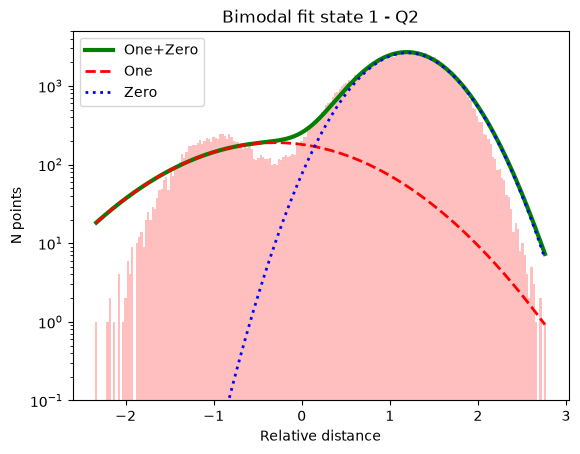

Area ratio: -6.660218972588408


In [443]:
# bimodal fit of the projected state-1 shots -> residual ground pop.
data = one_data_proj / r

fig, ax = plt.subplots()
y, x, patches = ax.hist(data, bins=n_bins, color='red', alpha=0.25)
x = (x[1:] + x[:-1]) / 2

expected = (-1, .2, y.max()*0.5, 1, .2, y.max()*0.5)
params, cov = curve_fit(bimodal, x, y, expected)
sigma = np.sqrt(np.diag(cov))
x_fit = np.linspace(x.min(), x.max(), 500)
# plot combined...
ax.plot(x_fit, bimodal(x_fit, *params), color='green', lw=3, label='One+Zero')
# ...and individual Gauss curves
ax.plot(x_fit, gauss(x_fit, *params[:3]), color='red', lw=2, ls='--', label='One')
ax.plot(x_fit, gauss(x_fit, *params[3:]), color='b', lw=2, ls=':', label='Zero')
ax.set_yscale('log')
ax.set_ylabel('N points')
ax.set_xlabel('Relative distance')
ax.set_ylim(1e-1, 5e3)
ax.set_title(f'Bimodal fit state 1 - {qubit_to_measure.uid}')
ax.legend()
print(pd.DataFrame(data={'params': params, 'sigma': sigma},
                   index=bimodal.__code__.co_varnames[1:]))
plt.show()

print('Area ratio:', params[4] * params[5] / (params[1] * params[2]))

             params      sigma
mu1       -1.031834   0.000742
sigma1     0.333688   0.001039
A1      3987.374539  10.705419
mu2        0.052735   0.281323
sigma2     1.100345   0.186310
A2        36.553023   5.179928


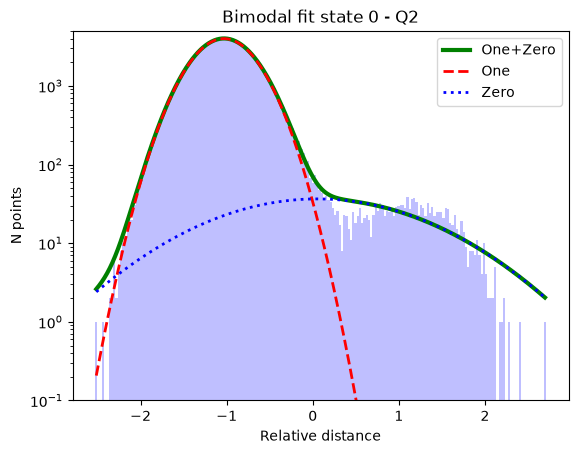

Area ratio: 33.08074431840509


In [444]:
# bimodal fit of the projected state-0 shots -> residual excited pop.
data = zero_data_proj / r

fig, ax = plt.subplots()
y, x, patches = ax.hist(data, bins=n_bins, color='blue', alpha=0.25)
x = (x[1:] + x[:-1]) / 2

expected = (-1.5, 1.0, y.max()*0.5, 1, 1.0, y.max()*0.5)
params, cov = curve_fit(bimodal, x, y, expected)
sigma = np.sqrt(np.diag(cov))
x_fit = np.linspace(x.min(), x.max(), 500)
# plot combined...
ax.plot(x_fit, bimodal(x_fit, *params), color='green', lw=3, label='One+Zero')
# ...and individual Gauss curves
ax.plot(x_fit, gauss(x_fit, *params[:3]), color='red', lw=2, ls='--', label='One')
ax.plot(x_fit, gauss(x_fit, *params[3:]), color='blue', lw=2, ls=':', label='Zero')
ax.set_yscale('log')
ax.set_ylabel('N points')
ax.set_xlabel('Relative distance')
ax.set_ylim(1e-1, 5e3)
ax.set_title(f'Bimodal fit state 0 - {qubit_to_measure.uid}')
ax.legend()
print(pd.DataFrame(data={'params': params, 'sigma': sigma},
                   index=bimodal.__code__.co_varnames[1:]))
plt.show()

print('Area ratio:', params[1] * params[2] / (params[4] * params[5]))

Text(0, 0.5, 'Imaginary part, a.u.')

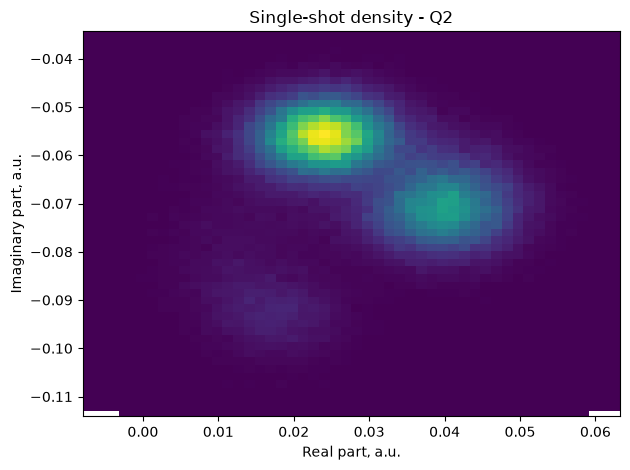

In [445]:
# 2D histogram of the shots
n_bins = 50

fig, ax = plt.subplots(tight_layout=True)
ax.set_title(f'Single-shot density - {qubit_to_measure.uid}')
ax.hist2d(zero_data.real, zero_data.imag, n_bins)
ax.hist2d(one_data.real, one_data.imag, n_bins)
ax.set_xlabel('Real part, a.u.')
ax.set_ylabel('Imaginary part, a.u.')

In [446]:
# the assignment matrix produced by the iq_blobs analysis replaces the manual
# LinearDiscriminantAnalysis / compute_pca cells.
if qubit_to_measure.uid in assignment_matrices:
    print('Correct-state-assignment matrix:')
    print(np.round(assignment_matrices[qubit_to_measure.uid], 4))
    print('Assignment fidelity:', f'{assignment_fidelity * 100:0.2f} %')

Correct-state-assignment matrix:
[[0.9854 0.011  0.0036]
 [0.0738 0.6344 0.2918]
 [0.0324 0.1115 0.8561]]
Assignment fidelity: 82.53 %


#### Update Parameters

In [447]:
# Data_SS = {...}; Data_SS.update(qubit_parameters._params);
# savemat(get_path_to_file('Single_shots_all_unsh_', '.mat'), Data_SS)
data_ss = {f'shots_{s}': shots_per_state[s] for s in states}
data_ss['states'] = list(states)
data_ss['shot_index'] = np.arange(shots_arr.shape[-1])
data_ss['n_shots'] = 2**n_avg_exponent
data_ss.update({k: v for k, v in res_ss.items()
                if isinstance(v, (int, float, complex))})
if qubit_to_measure.uid in assignment_matrices:
    data_ss['assignment_matrix'] = assignment_matrices[qubit_to_measure.uid]
    data_ss['assignment_fidelity'] = assignment_fidelity

data_ss.update(
    {k: v for k, v in attrs.asdict(temporary_parameters[qubit_to_measure.uid]).items()
     if isinstance(v, (int, float, str))}
)
data_ss['sample_name'] = sample_name
data_ss['qubit_name'] = qubit_name
data_ss['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Single_shots_all_unsh_', '.mat')
savemat(file_path, data_ss)
print(f'Saved single shots to: {file_path}')

Saved single shots to: N:\xld\qubit_thermometry_v2\ES-009-DE_1-2_9150\COOLDOWN_2026-09-02\Q2\20260903_142945_Single_shots_all_unsh_.mat


In [450]:
if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(temporary_parameters[qubit_to_measure.uid])
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

print('Readout amplitude: ', qubit_to_measure.parameters.readout_amplitude)
print('Readout length: ', qubit_to_measure.parameters.readout_length)
print('Readout integration length: ',
      qubit_to_measure.parameters.readout_integration_length)
print('Readout integration delay: ',
      qubit_to_measure.parameters.readout_integration_delay)
print('Reset delay length: ', qubit_to_measure.parameters.reset_delay_length)

Updated global experiment parameters!

Readout amplitude:  0.2
Readout length:  2e-06
Readout integration length:  2e-06
Readout integration delay:  8e-08
Reset delay length:  0.0003


In [451]:
qpu.quantum_elements

[TunableTransmonQubit(
│   uid='Q2',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=1.0433416889865267e-05,
│   │   ge_T2=1.659788521169252e-05,
│   │   ge_T2_star=7.741290835250325e-06,
│   │   ef_T1=5.161184727745047e-06,
│   │   ef_T2=1.957837104913142e-06,
│   │   ef_T2_star=5.594394899111066e-06,
│   │   drive_lo_frequency=4800000000.0,
│   │   readout_lo_frequency=6000000000.0,
│   │   resonance_frequency_ge=5008681684.374855,
│   │   resonance_frequency_ef=4788764299.046252,
│   │   readout_resonator_frequency=np.float64(5959692000.0),
│   │   ge_drive_amplitude_pi=0.3352897014347527,
│   │   ge_drive_amplitude_pi2=0.16594439910907385,
│   │   ge_drive_length=2e-07,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0.009337457823820674,
│   │   │   'sigma': 0.25
│   │   },

## Single Shot Measurement for Different Rabi Frequencies

#### Experiment Parameters

In [452]:
update_global_parameters = False

n_avg_exponent = 15  # reduce: this is a sweep over 36 pi-pulse lengths

states = 'ge'

drive_length_arr = np.linspace(60e-9, 400e-9, 36)
rabi_freq_arr = 1 / drive_length_arr

# ge_drive_pulse = {
#     'function': 'gaussian',
#     'sigma': 0.25,
# }

# The old notebook extrapolated the pi amplitude from a linear
# rabi_slope / rabi_intercept calibration. With the workflow structure the pi
# amplitude for the *current* drive length is a qubit parameter, so scale it
# instead of re-deriving it (or set `ge_drive_amplitude_pi_arr` manually).
rabi_slope = qubit_to_measure.parameters.ge_drive_amplitude_pi * \
    qubit_to_measure.parameters.ge_drive_length
ge_drive_amplitude_pi_arr = np.clip(rabi_slope / drive_length_arr, 0.0, 1.0)

print(pd.DataFrame({
    'ge_drive_length': drive_length_arr,
    'rabi_freq_MHz': rabi_freq_arr * 1e-6,
    'ge_drive_amplitude_pi': ge_drive_amplitude_pi_arr,
}))

qubit_to_measure = qubits[0]

    ge_drive_length  rabi_freq_MHz  ge_drive_amplitude_pi
0      6.000000e-08      16.666667               1.000000
1      6.971429e-08      14.344262               0.961897
2      7.942857e-08      12.589928               0.844255
3      8.914286e-08      11.217949               0.752253
4      9.885714e-08      10.115607               0.678332
5      1.085714e-07       9.210526               0.617639
6      1.182857e-07       8.454106               0.566915
7      1.280000e-07       7.812500               0.523890
8      1.377143e-07       7.261411               0.486935
9      1.474286e-07       6.782946               0.454850
10     1.571429e-07       6.363636               0.426732
11     1.668571e-07       5.993151               0.401888
12     1.765714e-07       5.663430               0.379778
13     1.862857e-07       5.368098               0.359974
14     1.960000e-07       5.102041               0.342132
15     2.057143e-07       4.861111               0.325976
16     2.15428

#### Run Workflow

In [453]:
options = iq_blobs.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(True)  # one IQ-blob figure per drive length
options.do_analysis(True)

ss_drive_length_sweep_shots = []
ss_drive_length_sweep_metrics = []
ss_drive_length_sweep_fidelities = []

for drive_length, drive_amplitude_pi in zip(drive_length_arr,
                                            ge_drive_amplitude_pi_arr):
    print('Drive length:', round(drive_length * 1e9, 3), 'ns',
          '| pi amplitude:', round(float(drive_amplitude_pi), 5))

    temporary_parameters = {}
    temp_pars = deepcopy(qubit_to_measure.parameters)
    temp_pars.ge_drive_length = float(drive_length)
    temp_pars.ge_drive_amplitude_pi = float(drive_amplitude_pi)
    # temp_pars.ge_drive_pulse = ge_drive_pulse
    temporary_parameters[qubit_to_measure.uid] = temp_pars

    exp_workflow = iq_blobs.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[qubit_to_measure.uid],
        states=states,
        options=options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result = exp_workflow.run()

    shots = collect_shots_from_result(
        workflow_result.output, qubit_to_measure.uid, states
    )
    ss_drive_length_sweep_shots.append(np.array([shots[s] for s in states]))

    res = analyze_single_shots(shots, state_0='g', state_1='e', plot=False)
    ss_drive_length_sweep_metrics.append(
        {k: v for k, v in res.items() if isinstance(v, (int, float, complex))}
    )
    ss_drive_length_sweep_fidelities.append(
        workflow_result.tasks['analysis_workflow'].output.get(
            qubit_to_measure.uid, np.nan
        )
    )

ss_drive_length_sweep_arr = np.array(ss_drive_length_sweep_shots)
print('Sweep array shape (drive lengths, states, shots):',
      ss_drive_length_sweep_arr.shape)

Drive length: 60.0 ns | pi amplitude: 1.0
[2026.09.03 14:31:05.767] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 14:31:05.767] INFO      Workflow 'iq_blobs': execution started at 2026-09-03 11:31:05.767056Z         
[2026.09.03 14:31:05.767] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 14:31:06.024] INFO    Task 'temporary_qpu': started at 2026-09-03 11:31:06.024689Z
[2026.09.03 14:31:06.081] INFO    Task 'temporary_qpu': ended at 2026-09-03 11:31:06.081263Z
[2026.09.03 14:31:06.207] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-03 
[2026.09.03 14:31:06.207] INFO    11:31:06.207986Z
[2026.09.03 14:31:06.254] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-03 11:31:06.254706Z
[2026.09.03 14:31:06.364] INFO    Task 'create_experiment': started at 2026-09-03 11:31:06.364336Z
[2026.09.03 14:31:06.489] INFO    Task 'create_experiment':

#### Analysis Plots

Best drive length: 137.714 ns | Rabi frequency: 7.261 MHz | rel_std_0: 0.3757


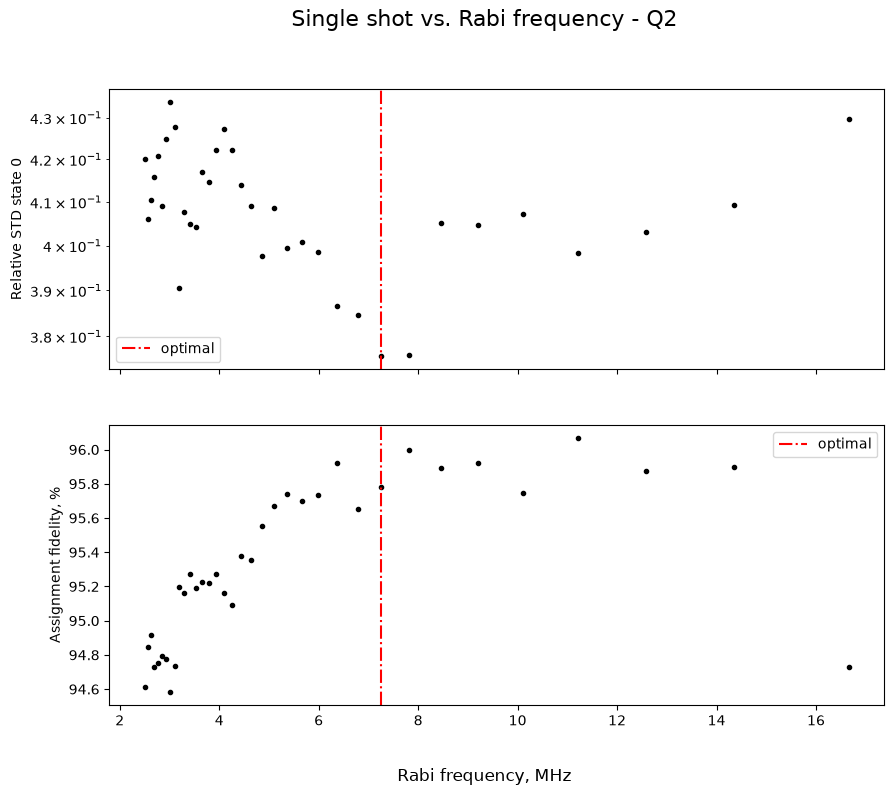

In [454]:
rel_std_0_arr = np.array([m['rel_std_0'] for m in ss_drive_length_sweep_metrics])
fidelity_arr = np.array(ss_drive_length_sweep_fidelities, dtype=float)

optimal_index = int(np.nanargmin(rel_std_0_arr))
print('Best drive length:', round(drive_length_arr[optimal_index] * 1e9, 3), 'ns',
      '| Rabi frequency:', round(rabi_freq_arr[optimal_index] * 1e-6, 3), 'MHz',
      '| rel_std_0:', round(float(rel_std_0_arr[optimal_index]), 4))

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
fig.suptitle(f'Single shot vs. Rabi frequency - {qubit_to_measure.uid}', fontsize=16)
fig.supxlabel('Rabi frequency, MHz')

ax[0].plot(rabi_freq_arr * 1e-6, rel_std_0_arr, '.k')
ax[0].set_ylabel('Relative STD state 0')
ax[0].set_yscale('log')

ax[1].plot(rabi_freq_arr * 1e-6, fidelity_arr * 100, '.k')
ax[1].set_ylabel('Assignment fidelity, %')

for axis in ax:
    axis.axvline(x=rabi_freq_arr[optimal_index] * 1e-6, ls='-.', color='r',
                 label='optimal')
    axis.legend()

file_path = get_path_to_file('Single_shots_vs_rabi_freq_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [455]:
data_ss = {
    'ss_drive_length_sweep_arr': ss_drive_length_sweep_arr,
    'states': list(states),
    'ge_drive_length': drive_length_arr,
    'rabi_freq': rabi_freq_arr,
    'ge_drive_amplitude_pi': ge_drive_amplitude_pi_arr,
    'rel_std_0': rel_std_0_arr,
    'assignment_fidelity': fidelity_arr,
    'n_shots': 2**n_avg_exponent,
    'comment': 'Sweep of the pi-pulse length, array dim [drive_length, state, shot]',
}
data_ss.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_ss['sample_name'] = sample_name
data_ss['qubit_name'] = qubit_name
data_ss['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Single_shots_0_pi_diff_pipulses_', '.mat')
savemat(file_path, data_ss)
print(f'Saved drive-length sweep to: {file_path}')

Saved drive-length sweep to: N:\xld\qubit_thermometry_v2\ES-009-DE_1-2_9150\COOLDOWN_2026-09-02\Q2\20260903_145238_Single_shots_0_pi_diff_pipulses_.mat


In [456]:
if update_global_parameters:
    temp_pars = deepcopy(qubit_to_measure.parameters)
    temp_pars.ge_drive_length = float(drive_length_arr[optimal_index])
    temp_pars.ge_drive_amplitude_pi = float(ge_drive_amplitude_pi_arr[optimal_index])
    # temp_pars.ge_drive_pulse = ge_drive_pulse
    qubit_to_measure.parameters = temp_pars
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

print('ge drive length: ', qubit_to_measure.parameters.ge_drive_length)
print('ge drive amplitude pi: ', qubit_to_measure.parameters.ge_drive_amplitude_pi)

ge drive length:  2e-07
ge drive amplitude pi:  0.3352897014347527


In [457]:
float(drive_length_arr[optimal_index])

1.377142857142857e-07

In [458]:
float(ge_drive_amplitude_pi_arr[optimal_index])

0.48693525104632135

In [463]:
qpu.quantum_elements

[TunableTransmonQubit(
│   uid='Q2',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=1.0433416889865267e-05,
│   │   ge_T2=1.659788521169252e-05,
│   │   ge_T2_star=7.741290835250325e-06,
│   │   ef_T1=5.161184727745047e-06,
│   │   ef_T2=1.957837104913142e-06,
│   │   ef_T2_star=5.594394899111066e-06,
│   │   drive_lo_frequency=4800000000.0,
│   │   readout_lo_frequency=6000000000.0,
│   │   resonance_frequency_ge=5008681684.374855,
│   │   resonance_frequency_ef=4788764299.046252,
│   │   readout_resonator_frequency=np.float64(5959692000.0),
│   │   ge_drive_amplitude_pi=0.3352897014347527,
│   │   ge_drive_amplitude_pi2=0.16594439910907385,
│   │   ge_drive_length=2e-07,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0.009337457823820674,
│   │   │   'sigma': 0.25
│   │   },

## Single Shot Measurement for Different Integration Lengths and Delays

#### Experiment Parameters

In [467]:
update_global_parameters = True

n_avg_exponent = 16

states = 'ge'

print('Readout length:            ', qubit_to_measure.parameters.readout_length)
print('Readout integration length:',
      qubit_to_measure.parameters.readout_integration_length)
print('Readout integration delay: ',
      qubit_to_measure.parameters.readout_integration_delay)

# TODO
# Here the readout pulse amplitude and length are fixed and we vary the
# integration delay and integration (weighting) length.
readout_length = qubit_to_measure.parameters.readout_length
readout_integration_delay_arr = np.linspace(60, 200, 10) * 1e-9
readout_integration_length_arr = np.array([readout_length])
# to sweep the integration length as well (old commented-out line
# `ro_len = np.arange(100, 2100 - port_delay_sw[k], 100)*1e-9`):
# readout_integration_length_arr = np.arange(100, 2100, 200) * 1e-9

qubit_to_measure = qubits[0]

Readout length:             2e-06
Readout integration length: 2e-06
Readout integration delay:  1.0000000000000001e-07


#### Run Workflow

In [468]:
options = iq_blobs.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(True)
options.do_analysis(False)  # only the projected statistics are needed here

ss_delay_sweep_metrics = []
ss_delay_sweep_shots = []

for integration_delay in readout_integration_delay_arr:
    print('Integration delay:', round(integration_delay * 1e9, 3), 'ns')

    metrics_inner = []
    shots_inner = []

    for integration_length in readout_integration_length_arr:
        print('  Integration length:', round(integration_length * 1e9, 3), 'ns')

        temporary_parameters = {}
        temp_pars = deepcopy(qubit_to_measure.parameters)
        temp_pars.readout_length = readout_length
        temp_pars.readout_integration_delay = float(integration_delay)
        temp_pars.readout_integration_length = float(integration_length)
        temporary_parameters[qubit_to_measure.uid] = temp_pars

        exp_workflow = iq_blobs.experiment_workflow(
            session=session,
            qpu=qpu,
            qubits=[qubit_to_measure.uid],
            states=states,
            options=options,
            temporary_parameters=temporary_parameters,
        )
        workflow_result = exp_workflow.run()

        shots = collect_shots_from_result(
            workflow_result.output, qubit_to_measure.uid, states
        )
        shots_inner.append(np.array([shots[s] for s in states]))

        res = analyze_single_shots(shots, state_0='g', state_1='e', plot=False)
        metrics_inner.append(
            {k: v for k, v in res.items() if isinstance(v, (int, float, complex))}
        )

    ss_delay_sweep_metrics.append(metrics_inner)
    ss_delay_sweep_shots.append(shots_inner)

ss_delay_sweep_arr = np.array(ss_delay_sweep_shots)
print('Sweep array shape (delays, integration lengths, states, shots):',
      ss_delay_sweep_arr.shape)

Integration delay: 60.0 ns
  Integration length: 2000.0 ns
[2026.09.03 15:08:30.885] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 15:08:30.885] INFO      Workflow 'iq_blobs': execution started at 2026-09-03 12:08:30.885859Z         
[2026.09.03 15:08:30.901] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 15:08:31.176] INFO    Task 'temporary_qpu': started at 2026-09-03 12:08:31.176321Z
[2026.09.03 15:08:31.247] INFO    Task 'temporary_qpu': ended at 2026-09-03 12:08:31.247268Z
[2026.09.03 15:08:31.360] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-03 
[2026.09.03 15:08:31.360] INFO    12:08:31.360125Z
[2026.09.03 15:08:31.423] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-03 12:08:31.423661Z
[2026.09.03 15:08:31.544] INFO    Task 'create_experiment': started at 2026-09-03 12:08:31.544834Z
[2026.09.03 15:08:31.708] INFO    Task 'cr

#### Analysis Plots

Readout length is 2e-06
Minimal relative error value is 0.38 for delay 75.556 ns (index 1 ) and integration length 2e-06 (index 0 ).
Optimal integration delay is between 60.0 and 91.111 ns


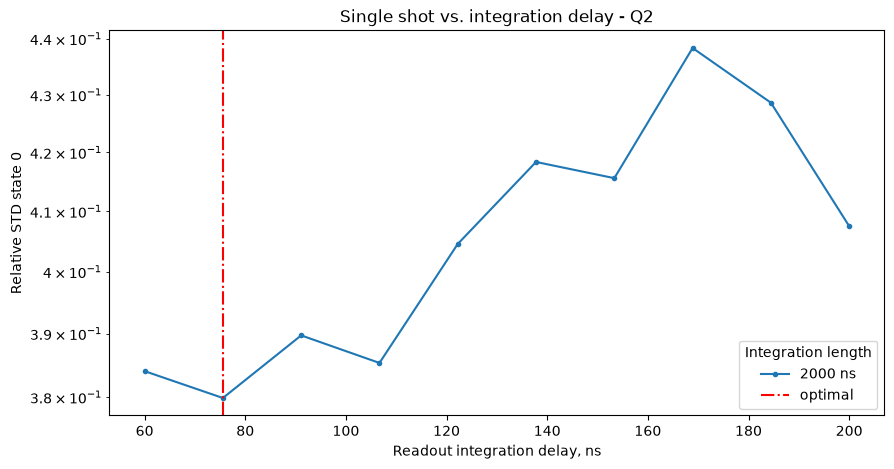

In [469]:
# min / argmin of Rel_STD_0 over the nested sweep
min_val = []
argmin_val = []

for metrics_inner in ss_delay_sweep_metrics:
    rel_std_0 = np.array([m['rel_std_0'] for m in metrics_inner])
    min_val.append(np.nanmin(rel_std_0))
    argmin_val.append(int(np.nanargmin(rel_std_0)))

optimal_delay_index = int(np.nanargmin(np.array(min_val)))
optimal_length_index = argmin_val[optimal_delay_index]

readout_integration_delay_opt = float(
    readout_integration_delay_arr[optimal_delay_index]
)
readout_integration_length_opt = float(
    readout_integration_length_arr[optimal_length_index]
)

print('Readout length is', readout_length)
print('Minimal relative error value is', np.round(min_val[optimal_delay_index], 3),
      'for delay', np.round(readout_integration_delay_opt * 1e9, 3),
      'ns (index', optimal_delay_index, ') and integration length',
      readout_integration_length_opt, '(index', optimal_length_index, ').')
if 0 < optimal_delay_index < len(readout_integration_delay_arr) - 1:
    print('Optimal integration delay is between',
          np.round(readout_integration_delay_arr[optimal_delay_index - 1] * 1e9, 3),
          'and',
          np.round(readout_integration_delay_arr[optimal_delay_index + 1] * 1e9, 3),
          'ns')

rel_std_0_arr = np.array(
    [[m['rel_std_0'] for m in metrics_inner]
     for metrics_inner in ss_delay_sweep_metrics]
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title(f'Single shot vs. integration delay - {qubit_to_measure.uid}')
for k, integration_length in enumerate(readout_integration_length_arr):
    ax.plot(readout_integration_delay_arr * 1e9, rel_std_0_arr[:, k], '.-',
            label=f'{integration_length * 1e9:.0f} ns')
ax.axvline(x=readout_integration_delay_opt * 1e9, ls='-.', color='r', label='optimal')
ax.set_xlabel('Readout integration delay, ns')
ax.set_ylabel('Relative STD state 0')
ax.set_yscale('log')
ax.legend(title='Integration length')

file_path = get_path_to_file('Single_shots_vs_delay_and_int_len_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [470]:
# set to a value != None to override the values extracted above.
manual_readout_integration_delay = None
manual_readout_integration_length = None
if manual_readout_integration_delay is not None:
    readout_integration_delay_opt = float(manual_readout_integration_delay)
if manual_readout_integration_length is not None:
    readout_integration_length_opt = float(manual_readout_integration_length)

if update_global_parameters:
    temp_pars = deepcopy(qubit_to_measure.parameters)
    temp_pars.readout_integration_delay = readout_integration_delay_opt
    temp_pars.readout_integration_length = readout_integration_length_opt
    qubit_to_measure.parameters = temp_pars
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

print('Readout integration delay: ',
      qubit_to_measure.parameters.readout_integration_delay)
print('Readout integration length: ',
      qubit_to_measure.parameters.readout_integration_length)

Updated global experiment parameters!

Readout integration delay:  7.555555555555556e-08
Readout integration length:  2e-06


In [471]:
data_ss = {
    'ss_delay_sweep_arr': ss_delay_sweep_arr,
    'states': list(states),
    'readout_integration_delay_sweep': readout_integration_delay_arr,
    'readout_integration_length_sweep': readout_integration_length_arr,
    'readout_length': readout_length,
    'rel_std_0': rel_std_0_arr,
    'n_shots': 2**n_avg_exponent,
    'comment': ('Sweep integration delay and integration length, array dim '
                '[delay, integration_length, state, shot]'),
}
data_ss.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_ss['sample_name'] = sample_name
data_ss['qubit_name'] = qubit_name
data_ss['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Single_shots_0_pi_sweep_delay_and_ro_len_', '.mat')
savemat(file_path, data_ss)
print(f'Saved delay/integration-length sweep to: {file_path}')

Saved delay/integration-length sweep to: N:\xld\qubit_thermometry_v2\ES-009-DE_1-2_9150\COOLDOWN_2026-09-02\Q2\20260903_151801_Single_shots_0_pi_sweep_delay_and_ro_len_.mat


In [472]:
qpu.quantum_elements

[TunableTransmonQubit(
│   uid='Q2',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=1.0433416889865267e-05,
│   │   ge_T2=1.659788521169252e-05,
│   │   ge_T2_star=7.741290835250325e-06,
│   │   ef_T1=5.161184727745047e-06,
│   │   ef_T2=1.957837104913142e-06,
│   │   ef_T2_star=5.594394899111066e-06,
│   │   drive_lo_frequency=4800000000.0,
│   │   readout_lo_frequency=6000000000.0,
│   │   resonance_frequency_ge=5008681684.374855,
│   │   resonance_frequency_ef=4788764299.046252,
│   │   readout_resonator_frequency=np.float64(5959692000.0),
│   │   ge_drive_amplitude_pi=0.3352897014347527,
│   │   ge_drive_amplitude_pi2=0.16594439910907385,
│   │   ge_drive_length=2e-07,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0.009337457823820674,
│   │   │   'sigma': 0.25
│   │   },

## Single Shot Measurement for Different Readout Amplitudes and Lengths

#### Experiment Parameters

In [473]:
update_global_parameters = False

n_avg_exponent = 16

states = 'ge'

# TODO
# Sweep power and length of the readout pulse. The integration delay is fixed
# and the integration window is equal to the readout pulse length.
readout_amplitude_arr = np.linspace(0.05, 1, 20)
readout_length_arr = np.linspace(1900, 2000, 11) * 1e-9

readout_integration_delay = qubit_to_measure.parameters.readout_integration_delay

qubit_to_measure = qubits[0]

#### Run Workflow

In [474]:
options = iq_blobs.experiment_workflow.options()
options.count(2**n_avg_exponent)
options.close_figures(True)
options.do_analysis(False)

ss_ro_sweep_metrics = []

for readout_amplitude in readout_amplitude_arr:
    print('Readout amplitude:', round(float(readout_amplitude), 5))

    metrics_inner = []

    for readout_length in readout_length_arr:
        print('  Readout length:', round(readout_length * 1e9, 3), 'ns')

        temporary_parameters = {}
        temp_pars = deepcopy(qubit_to_measure.parameters)
        temp_pars.readout_amplitude = float(readout_amplitude)
        temp_pars.readout_length = float(readout_length)
        # old: readout_weighting_function_i = pulse_library.const(length=ro_len_sw[i])
        temp_pars.readout_integration_length = float(readout_length)
        temp_pars.readout_integration_delay = readout_integration_delay
        temporary_parameters[qubit_to_measure.uid] = temp_pars

        exp_workflow = iq_blobs.experiment_workflow(
            session=session,
            qpu=qpu,
            qubits=[qubit_to_measure.uid],
            states=states,
            options=options,
            temporary_parameters=temporary_parameters,
        )
        workflow_result = exp_workflow.run()

        shots = collect_shots_from_result(
            workflow_result.output, qubit_to_measure.uid, states
        )
        res = analyze_single_shots(shots, state_0='g', state_1='e', plot=False)
        metrics_inner.append(
            {k: v for k, v in res.items() if isinstance(v, (int, float, complex))}
        )

    ss_ro_sweep_metrics.append(metrics_inner)

Readout amplitude: 0.05
  Readout length: 1900.0 ns
[2026.09.03 15:19:48.805] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 15:19:48.805] INFO      Workflow 'iq_blobs': execution started at 2026-09-03 12:19:48.805742Z         
[2026.09.03 15:19:48.805] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 15:19:48.998] INFO    Task 'temporary_qpu': started at 2026-09-03 12:19:48.998796Z
[2026.09.03 15:19:49.030] INFO    Task 'temporary_qpu': ended at 2026-09-03 12:19:49.030871Z
[2026.09.03 15:19:49.095] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-03 
[2026.09.03 15:19:49.101] INFO    12:19:49.095624Z
[2026.09.03 15:19:49.127] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-03 12:19:49.127384Z
[2026.09.03 15:19:49.180] INFO    Task 'create_experiment': started at 2026-09-03 12:19:49.180050Z
[2026.09.03 15:19:49.292] INFO    Task 'create_ex

#### Analysis Plots

Minimal relative error value is 0.388 for amplitude 0.22 (index 5 ) and length 1.977777777777778e-06 (index 7 ).


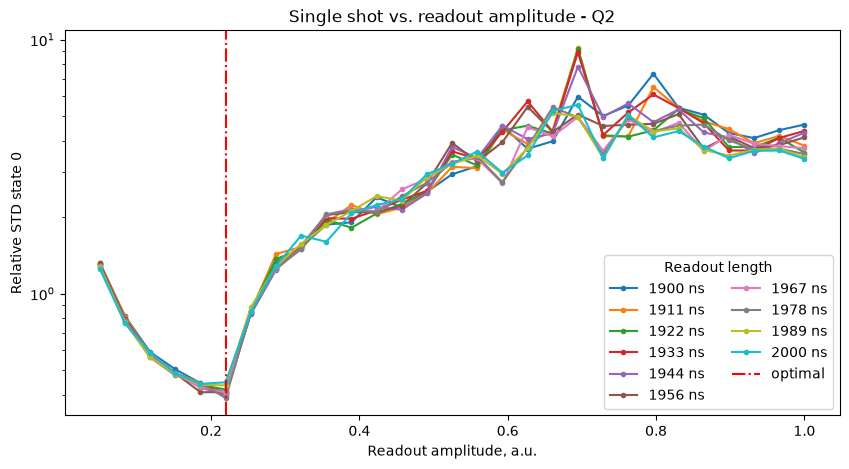

In [475]:
# min / argmin of Rel_STD_0 and the Rel_STD_0 vs. amplitude plot
rel_std_0_arr = np.array(
    [[m['rel_std_0'] for m in metrics_inner] for metrics_inner in ss_ro_sweep_metrics]
)

optimal_amp_index = int(np.nanargmin(np.nanmin(rel_std_0_arr, axis=1)))
optimal_len_index = int(np.nanargmin(rel_std_0_arr[optimal_amp_index, :]))

readout_amplitude_opt = float(readout_amplitude_arr[optimal_amp_index])
readout_length_opt = float(readout_length_arr[optimal_len_index])

print('Minimal relative error value is',
      np.round(rel_std_0_arr[optimal_amp_index, optimal_len_index], 3),
      'for amplitude', np.round(readout_amplitude_opt, 3),
      '(index', optimal_amp_index, ') and length', readout_length_opt,
      '(index', optimal_len_index, ').')

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title(f'Single shot vs. readout amplitude - {qubit_to_measure.uid}')
for k, readout_length in enumerate(readout_length_arr):
    ax.plot(readout_amplitude_arr, rel_std_0_arr[:, k], '.-',
            label=f'{readout_length * 1e9:.0f} ns')
ax.axvline(x=readout_amplitude_opt, ls='-.', color='r', label='optimal')
ax.set_xlabel('Readout amplitude, a.u.')
ax.set_ylabel('Relative STD state 0')
ax.set_yscale('log')
ax.legend(title='Readout length', ncol=2)

file_path = get_path_to_file('Single_shots_vs_ro_amp_and_ro_len_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

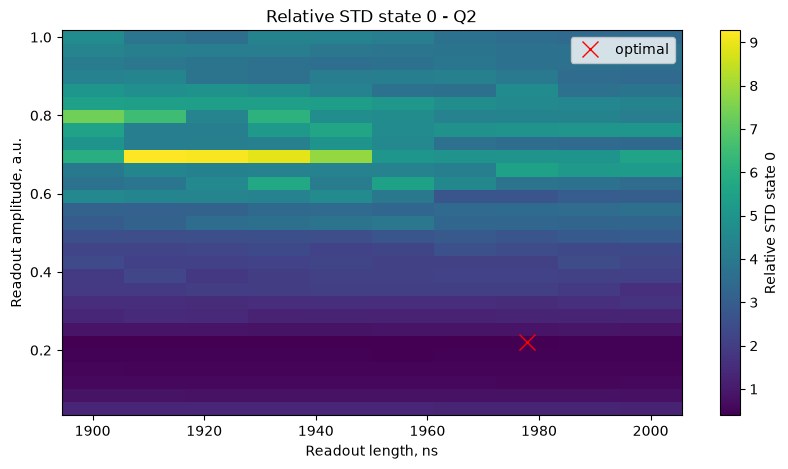

In [476]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title(f'Relative STD state 0 - {qubit_to_measure.uid}')
im = ax.pcolormesh(readout_length_arr * 1e9, readout_amplitude_arr, rel_std_0_arr,
                   shading='nearest')
cb = fig.colorbar(im)
cb.set_label('Relative STD state 0')
ax.plot(readout_length_opt * 1e9, readout_amplitude_opt, 'rx', ms=12, label='optimal')
ax.set_xlabel('Readout length, ns')
ax.set_ylabel('Readout amplitude, a.u.')
ax.legend()

file_path = get_path_to_file('Single_shots_ro_amp_ro_len_map_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [479]:
# set to a value != None to override the values extracted above.
manual_readout_amplitude = None
manual_readout_length = None
if manual_readout_amplitude is not None:
    readout_amplitude_opt = float(manual_readout_amplitude)
if manual_readout_length is not None:
    readout_length_opt = float(manual_readout_length)

if update_global_parameters:
    temp_pars = deepcopy(qubit_to_measure.parameters)
    temp_pars.readout_amplitude = readout_amplitude_opt
    temp_pars.readout_length = readout_length_opt
    temp_pars.readout_integration_length = readout_length_opt
    qubit_to_measure.parameters = temp_pars
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

print('Readout amplitude: ', qubit_to_measure.parameters.readout_amplitude)
print('Readout length: ', qubit_to_measure.parameters.readout_length)
print('Readout integration length: ',
      qubit_to_measure.parameters.readout_integration_length)

Updated global experiment parameters!

Readout amplitude:  0.21964285714285714
Readout length:  1.977777777777778e-06
Readout integration length:  1.977777777777778e-06


In [480]:
data_ss = {
    'states': list(states),
    'readout_amplitude_sweep': readout_amplitude_arr,
    'readout_length_sweep': readout_length_arr,
    'readout_integration_delay': readout_integration_delay,
    'rel_std_0': rel_std_0_arr,
    'n_shots': 2**n_avg_exponent,
    'comment': ('Sweep readout amplitude and readout length, array dim '
                '[readout_amplitude, readout_length]'),
}
data_ss.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_ss['sample_name'] = sample_name
data_ss['qubit_name'] = qubit_name
data_ss['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Single_shots_0_pi_sweep_ro_amp_and_ro_len_', '.mat')
savemat(file_path, data_ss)
print(f'Saved readout amplitude/length sweep to: {file_path}')

Saved readout amplitude/length sweep to: N:\xld\qubit_thermometry_v2\ES-009-DE_1-2_9150\COOLDOWN_2026-09-02\Q2\20260903_190657_Single_shots_0_pi_sweep_ro_amp_and_ro_len_.mat


In [481]:
readout_opt = {
    'readout_amplitude': qubit_to_measure.parameters.readout_amplitude,
    'readout_length': qubit_to_measure.parameters.readout_length,
    'readout_pulse': qubit_to_measure.parameters.readout_pulse,
    'readout_integration_length': qubit_to_measure.parameters.readout_integration_length,
    'readout_integration_delay': qubit_to_measure.parameters.readout_integration_delay,
    'readout_integration_kernels_type':
        qubit_to_measure.parameters.readout_integration_kernels_type,
    'readout_resonator_frequency': qubit_to_measure.parameters.readout_resonator_frequency,
    'readout_lo_frequency': qubit_to_measure.parameters.readout_lo_frequency,
    'readout_range_out': qubit_to_measure.parameters.readout_range_out,
    'readout_range_in': qubit_to_measure.parameters.readout_range_in,
    'reset_delay_length': qubit_to_measure.parameters.reset_delay_length,
}
pprint(readout_opt)

{'readout_amplitude': 0.21964285714285714,
 'readout_integration_delay': 7.555555555555556e-08,
 'readout_integration_kernels_type': 'default',
 'readout_integration_length': 1.977777777777778e-06,
 'readout_length': 1.977777777777778e-06,
 'readout_lo_frequency': 6000000000.0,
 'readout_pulse': {'function': 'const'},
 'readout_range_in': -40,
 'readout_range_out': -20,
 'readout_resonator_frequency': np.float64(5959692000.0),
 'reset_delay_length': 0.0003}


In [482]:
qpu.quantum_elements

[TunableTransmonQubit(
│   uid='Q2',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=1.0433416889865267e-05,
│   │   ge_T2=1.659788521169252e-05,
│   │   ge_T2_star=7.741290835250325e-06,
│   │   ef_T1=5.161184727745047e-06,
│   │   ef_T2=1.957837104913142e-06,
│   │   ef_T2_star=5.594394899111066e-06,
│   │   drive_lo_frequency=4800000000.0,
│   │   readout_lo_frequency=6000000000.0,
│   │   resonance_frequency_ge=5008681684.374855,
│   │   resonance_frequency_ef=4788764299.046252,
│   │   readout_resonator_frequency=np.float64(5959692000.0),
│   │   ge_drive_amplitude_pi=0.3352897014347527,
│   │   ge_drive_amplitude_pi2=0.16594439910907385,
│   │   ge_drive_length=2e-07,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0.009337457823820674,
│   │   │   'sigma': 0.25
│   │   },

# Population Measurements <a class="anchor" id="population-measurements"></a>

Effective-temperature measurements of the qubit.

1. **Rabi Population Measurements (RPM)** — compare the ef-Rabi amplitude with
   and without a ge pre-pulse. The ratio of the two oscillation amplitudes
   gives the residual excited-state population `p_e` and thus the effective
   temperature. The ef pi-pulse used for the fast (two-point) version is
   calibrated in `### Setup`.
2. **Three Level Population Measurements** — the six-sequence protocol
   (`x0`, `x1`, `x2`, `y0`, `y1`, `y2`) that yields the nine `A`/`B`/`C`
   estimators of `p_e/p_g` and the corresponding temperatures `TA1 ... TC3`,
   including the repeated (statistics) version, the projection-phase
   optimization and a variant with a ge pre-pulse of swept amplitude.
3. **Population Measurements for Different Readout Frequencies** — the same
   six-sequence protocol repeated for a range of readout resonator
   frequencies (slow!).

The readout parameters optimized in `# Readout Optimization` and
`# Single Shot 0 and 1 Measurements` are the starting point here.

`laboneq_applications` has no population experiment, so the experiments and
workflows are defined in `## Custom Experiment Workflows` below.

## Helpers

#### Additional Imports

In [483]:
# Needed by the custom population workflows.
from laboneq.workflow.tasks import compile_experiment, run_experiment

from laboneq_applications.core import validation
from laboneq_applications.experiments.options import BaseExperimentOptions
from laboneq_applications.tasks.parameter_updating import (
    temporary_qpu,
    temporary_quantum_elements_from_qpu,
)

from scipy.optimize import fsolve

#### Fit Helpers

In [484]:
# Old `lib.helpers.fitting_helper.func_osc` / `fit_Rabi` / `normalize_1d_osc`.DS_Store
def func_osc(x, freq, phase, amp=1, off=0):
    """Old `lib.helpers.fitting_helper.func_osc`, unchanged."""
    return amp * np.cos(freq * x + phase) + off


def fit_rabi_osc(x, y, freq, phase, amp=None, off=None, plot=False, bounds=None):
    """New-structure replacement for the old `fit_Rabi`.

    Same maths (scipy `curve_fit` of `func_osc`), snake_case name. The RPM
    section fits the *raw* magnitude/phase traces, so this stays a manual fit
    instead of the lmfit result of an `analysis_workflow`.
    """
    p0 = [freq, phase]
    if amp is not None:
        p0.append(amp)
        if off is not None:
            p0.append(off)

    kwargs = {} if bounds is None else {'bounds': bounds}
    popt, pcov = curve_fit(func_osc, x, y, p0=p0, **kwargs)

    if plot:
        plt.plot(x, y, '.k')
        plt.plot(x, func_osc(x, *popt), '-r')
        plt.xlabel('Amplitude, a.u.')
        plt.ylabel('Signal, a.u.')
        plt.show()

    return popt, pcov


def normalize_1d_osc(osc, offset=None, norm=None):
    """Old `lib.helpers.fitting_helper.normalize_1d_osc`, unchanged."""
    if offset is None:
        offset = np.mean(osc)
    if norm is None:
        norm = 1 / np.abs(osc.max() - osc.min())

    return 2 * (osc - offset) * norm, offset, norm


def qrpm_dict_from_results(results):
    """New-structure replacement for `get_qrpm_dict_from_list_of_results`.

    Takes a list of `rpm_res` dicts (as built in `#### Analysis Plots` of
    `### Population Measurement`) and flattens them into one dict of arrays,
    with the same keys as the old helper.
    """
    keys = ['I_max', 'I_min', 'Q_max', 'Q_min',
            'mag_max', 'mag_min', 'pha_max', 'pha_min']
    out = {}
    for key in keys:
        for pre_pulse in ['with', 'wo']:
            out[f'{key}_{pre_pulse}'] = np.array(
                [np.mean(res[pre_pulse][key]) for res in results]
            )
    return out

#### Temperature Helpers

In [485]:
# Old `lib.helpers.pop_temp_helper_v2`: populations -> pe/pg -> temperature.
# The six population labels of the three-level protocol.
pop_label_list = ['x0', 'x1', 'x2', 'y0', 'y1', 'y2']


def T_calc(C, f_q):
    """Old `T_calc`, unchanged: pe/pg (= C) and f_q in GHz -> temperature in K."""
    h = 6.628e-2
    k = 1.381
    return -(h * f_q / k) / np.log(C)


def A_temp(T, A, f_q, anharm):
    """Old `A_temp`, unchanged. `f_q` and `anharm` in GHz."""
    h = 6.628e-2
    k = 1.381
    f_g2 = 2 * f_q - anharm
    num = 1 - np.exp(-h * f_q / k / T)
    denum = 1 - np.exp(-h * f_g2 / k / T)
    return A - num / denum


def B_temp(T, B, f_q, anharm):
    """Old `B_temp`, unchanged."""
    h = 6.628e-2
    k = 1.381
    f_g2 = 2 * f_q - anharm
    num = np.exp(-h * f_q / k / T) - np.exp(-h * f_g2 / k / T)
    denum = 1 - np.exp(-h * f_q / k / T)
    return B - num / denum


def C_temp(T, C, f_q, anharm):
    """Old `C_temp`, unchanged."""
    h = 6.628e-2
    k = 1.381
    f_g2 = 2 * f_q - anharm
    num = np.exp(-h * f_q / k / T) - np.exp(-h * f_g2 / k / T)
    denum = 1 - np.exp(-h * f_g2 / k / T)
    return C - num / denum


def get_qubit_temperature_parameters(qubit):
    """`f_q` and `anharm` (both in GHz) of the new qubit parameters.

    New-structure replacement for
    `f_q = (lo_settings["qb_lo"] + qubit_parameters["qb_freq"]) * 1e-9` and
    `anharm = qubit_parameters['qb_anharm'] * 1e-9`: both resonance frequencies
    are absolute now, so the anharmonicity is their difference.
    """
    f_q = qubit.parameters.resonance_frequency_ge * 1e-9
    anharm = (
        qubit.parameters.resonance_frequency_ge
        - qubit.parameters.resonance_frequency_ef
    ) * 1e-9
    return f_q, anharm

In [486]:
def get_ABC(pop_proj):
    """Old `get_ABC`, unchanged: the nine estimators from projected data."""
    x0 = pop_proj['x0']
    x1 = pop_proj['x1']
    x2 = pop_proj['x2']
    y0 = pop_proj['y0']
    y1 = pop_proj['y1']
    y2 = pop_proj['y2']

    result = {}
    result['A1'] = (x0 - x1) / (y0 - y1)
    result['B1'] = (x2 - y2) / (x0 - x1)
    result['C1'] = result['A1'] * result['B1']

    result['A2'] = (y0 - x2) / (x0 - y2)
    result['B2'] = (x1 - y1) / (y0 - x2)
    result['C2'] = result['A2'] * result['B2']

    result['A3'] = (y1 - y2) / (x1 - x2)
    result['B3'] = (x0 - y0) / (y1 - y2)
    result['C3'] = result['A3'] * result['B3']

    return result


def make_projection(pop_full_results, phase):
    """Old `make_projection`, unchanged: rotate and project onto I and Q."""
    res_I = {}
    res_Q = {}
    for k in pop_full_results:
        rot = pop_full_results[k] * np.exp(1j * phase)
        res_I[k] = rot.real
        res_Q[k] = rot.imag

    return res_I, res_Q


def get_temperature(ABC, f_q, anharm=None, three_levels=False):
    """Old `get_temperature`, with `anharm` now optional.

    N.B: with `three_levels=False` the simple low-temperature limit is used and
    `anharm` is ignored (the old notebook called
    `get_temperature(ABC_I, f_q)`, which used to raise a TypeError).
    """
    if three_levels and anharm is None:
        raise ValueError("`anharm` is required when `three_levels=True`.")

    def _pick(val, index):
        """Scalar for this element, whether `val` is a single scalar
        or an array shaped like ABC[k]."""
        arr = np.asarray(val)
        if arr.ndim == 0:
            return arr.item()
        return float(arr[index])

    result = {}
    for k in ABC:
        new_k = 'T' + k
        if k[0] == 'A':
            result[new_k] = T_calc(1 - ABC[k], f_q) * 1e3
            solve_fn = A_temp
        elif k[0] == 'B':
            result[new_k] = T_calc(ABC[k] / (ABC[k] + 1), f_q) * 1e3
            solve_fn = B_temp
        elif k[0] == 'C':
            result[new_k] = T_calc(ABC[k], f_q) * 1e3
            solve_fn = C_temp
        else:
            print('Wrong key in ABC dictionary!')
            continue

        if three_levels:
            for index, x in np.ndenumerate(ABC[k]):
                x0 = float(result[new_k][index]) * 1e-3
                f_q_i = _pick(f_q, index)
                anharm_i = _pick(anharm, index)
                root = fsolve(solve_fn, x0, args=(float(x), f_q_i, anharm_i))
                result[new_k][index] = float(root[0]) * 1e3
                
    return result


def get_stat(data):
    """Old `get_stat`, unchanged: [mean, std, relative error] per key."""
    stat = {}
    for k in data:
        arr = np.asarray(data[k], dtype=float)
        M = np.nanmean(arr)
        V = np.sqrt(np.var(arr, ddof=1))
        stat[k] = np.array([M, V, V / M], dtype=float)
        if stat[k].shape != (3,):
            raise RuntimeError(f"Unexpected stat shape for key {k!r}: "
                               f"{stat[k].shape}, data shape was {arr.shape}")
    return stat


def get_stat_nan(data):
    """Old `get_stat_nan`, unchanged: same as `get_stat` but nan-aware."""
    stat = {}
    for k in data:
        M = np.nanmean(data[k])
        V = np.sqrt(np.nanvar(data[k], ddof=1))
        stat[k] = np.array([M, V, V / M])
    return stat


def make_all_temperatures(pop_full_results, f_q, anharm, phase=0,
                          three_levels=True):
    """Old `make_all_temperatures`, unchanged."""
    proj_I, proj_Q = make_projection(pop_full_results, phase)

    ABC_I = get_ABC(proj_I)
    ABC_Q = get_ABC(proj_Q)

    TABC_I = get_temperature(ABC_I, f_q, anharm, three_levels=three_levels)
    TABC_Q = get_temperature(ABC_Q, f_q, anharm, three_levels=three_levels)
    return TABC_I, TABC_Q

In [487]:
# Old `get_diff` / `get_axes_and_rotate` / `get_ABC_parallel` / `get_C_from_ABC`:
# the 'parallel' way of processing the data (rotation per difference vector).
def get_diff(pop_proj):
    """Old `get_diff`, unchanged."""
    x0 = pop_proj['x0']
    x1 = pop_proj['x1']
    x2 = pop_proj['x2']
    y0 = pop_proj['y0']
    y1 = pop_proj['y1']
    y2 = pop_proj['y2']
    diff_dict = {}
    # parallel to ge, index 1
    diff_dict['x0x1'] = x0 - x1  # order1, mid
    diff_dict['y0y1'] = y0 - y1  # order1, max
    diff_dict['x2y2'] = x2 - y2  # order0, min

    # parallel to gf, index 2
    diff_dict['y0x2'] = y0 - x2  # order1, mid
    diff_dict['x0y2'] = x0 - y2  # order1, max
    diff_dict['x1y1'] = x1 - y1  # order0, min

    # parallel to ef, index 3
    diff_dict['y1y2'] = y1 - y2  # order1, mid
    diff_dict['x1x2'] = x1 - x2  # order1, max
    diff_dict['x0y0'] = x0 - y0  # order0, min
    return diff_dict


def get_axes_and_rotate(D1, D2, D3):
    """Old `get_axes_and_rotate`, unchanged."""
    Angle1 = np.angle(D1)
    Angle2 = np.angle(D2)
    angle = (Angle1 + Angle2) / 2
    D1_rot = D1 * np.exp(-1j * angle)
    D2_rot = D2 * np.exp(-1j * angle)
    D3_rot = D3 * np.exp(-1j * angle)

    A = D1_rot.real / D2_rot.real
    B = D3_rot.real / D1_rot.real
    C = D3_rot.real / D2_rot.real

    return A, B, C


def get_ABC_parallel(pop_full_results):
    """Old `get_ABC_parallel`, unchanged."""
    diff_dict = get_diff(pop_full_results)

    result = {}
    result['A1'], result['B1'], result['C1'] = get_axes_and_rotate(
        diff_dict['x0x1'], diff_dict['y0y1'], diff_dict['x2y2']
    )
    result['A2'], result['B2'], result['C2'] = get_axes_and_rotate(
        diff_dict['y0x2'], diff_dict['x0y2'], diff_dict['x1y1']
    )
    result['A3'], result['B3'], result['C3'] = get_axes_and_rotate(
        diff_dict['y1y2'], diff_dict['x1x2'], diff_dict['x0y0']
    )
    return result


def get_C_from_ABC(ABC_dict):
    """Old `get_C_from_ABC`, unchanged: every estimator expressed as pe/pg."""
    CCC_dict = {}
    for k in ABC_dict:
        kn = 'C' + k
        if 'A' in k:
            CCC_dict[kn] = 1 - ABC_dict[k]
        elif 'B' in k:
            CCC_dict[kn] = ABC_dict[k] / (1 + ABC_dict[k])
        else:
            CCC_dict[kn] = ABC_dict[k]
    return CCC_dict

In [488]:
# Old `make_rotation_temperature` / `make_optimal_temperature` /
# `find_optimal_temperature`: projection-phase optimization.
def make_rotation_temperature(data, phase_arr, f_q, anharm, three_levels=True):
    """Old `make_rotation_temperature`, unchanged."""
    STAT_I = {}
    STAT_Q = {}

    for i in range(len(phase_arr)):
        proj_I, proj_Q = make_projection(data, phase_arr[i])

        ABC_I = get_ABC(proj_I)
        ABC_Q = get_ABC(proj_Q)

        TABC_I = get_temperature(ABC_I, f_q, anharm, three_levels=three_levels)
        TABC_Q = get_temperature(ABC_Q, f_q, anharm, three_levels=three_levels)

        stat_TABC_I = get_stat(TABC_I)
        stat_TABC_Q = get_stat(TABC_Q)
        for k in stat_TABC_I:
            if i == 0:
                STAT_I[k] = [stat_TABC_I[k]]
                STAT_Q[k] = [stat_TABC_Q[k]]
            else:
                STAT_I[k].append(stat_TABC_I[k])
                STAT_Q[k].append(stat_TABC_Q[k])

    for k in stat_TABC_I:
        STAT_I[k] = np.array(STAT_I[k])
        STAT_Q[k] = np.array(STAT_Q[k])

    return STAT_I, STAT_Q


def make_optimal_temperature(data, phase_arr, f_q, anharm, skip=(),
                             info_type='rel_err', three_levels=True):
    """Old `make_optimal_temperature`, unchanged."""
    STAT_I, STAT_Q = make_rotation_temperature(
        data, phase_arr, f_q, anharm, three_levels=three_levels
    )

    optimal_method = {'rel_err': 1000, 'phase': 0, 'ph_p': 0,
                      'method': '0', 'axes': '0'}
    it = {'mean': 0, 'error': 1, 'rel_err': 2}[info_type]

    for k in STAT_I:
        if k in skip:
            continue
        rel_Q = np.nanmin(STAT_Q[k][:, it])
        ph_p_Q = np.nanargmin(STAT_Q[k][:, it])
        rel_I = np.nanmin(STAT_I[k][:, it])
        ph_p_I = np.nanargmin(STAT_I[k][:, it])

        if (rel_I or ph_p_Q) < optimal_method['rel_err']:
            optimal_method['method'] = k
            if abs(phase_arr[ph_p_Q]) < abs(phase_arr[ph_p_I]):
                optimal_method['rel_err'] = rel_Q
                optimal_method['phase'] = phase_arr[ph_p_Q]
                optimal_method['ph_p'] = ph_p_Q
                optimal_method['axes'] = 'Q'
            else:
                optimal_method['rel_err'] = rel_I
                optimal_method['phase'] = phase_arr[ph_p_I]
                optimal_method['ph_p'] = ph_p_I
                optimal_method['axes'] = 'I'
    return optimal_method


def find_optimal_temperature(pop_full_results, optimal_method, f_q, anharm,
                             three_levels=True):
    """Old `find_optimal_temperature`, unchanged."""
    proj_I, proj_Q = make_projection(pop_full_results, optimal_method['phase'])

    if optimal_method['axes'] == 'I':
        ABC = get_ABC(proj_I)
    elif optimal_method['axes'] == 'Q':
        ABC = get_ABC(proj_Q)
    else:
        print('Wrong axe in optimal_parameters!')
        return None

    TABC = get_temperature(ABC, f_q, anharm, three_levels=three_levels)
    return TABC[optimal_method['method']]

In [531]:
# Old `plot_temperatures` / `plot_temp_single` / `plot_stat` /
# `plot_rotation_stat`.
_TEMP_COLOR_CYCLE = ['red', 'orange', 'gold', 'green', 'limegreen', 'cyan',
                     'blue', 'darkviolet', 'magenta']


def plot_temperatures(TABC_I, TABC_Q, skip=(), xlim=None, ylim=None):
    """Old `plot_temperatures`, unchanged (returns the figure now)."""
    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

    ax[0].set_prop_cycle(color=_TEMP_COLOR_CYCLE)
    ax[1].set_prop_cycle(color=_TEMP_COLOR_CYCLE)

    fig.supxlabel('Point number')
    fig.supylabel('Effective temperature, mK')

    ax[0].set_title('I component')
    ax[1].set_title('Q component')

    for k in TABC_I:
        if k in skip:
            continue
        ax[0].plot(TABC_I[k], 'o-', label=k)
    ax[0].legend()

    for k in TABC_Q:
        if k in skip:
            continue
        ax[1].plot(TABC_Q[k], 'o-', label=k)
    ax[1].legend()

    if xlim is not None:
        ax[0].set_xlim(xlim)
        ax[1].set_xlim(xlim)
    if ylim is not None:
        ax[0].set_ylim(ylim)
        ax[1].set_ylim(ylim)

    return fig, ax


def plot_temp_single(TABC, skip=(), xlim=None, ylim=None, xdata=None,
                     xlabel='Point Number'):
    """Old `plot_temp_single`, unchanged."""
    if xdata is not None:
        assert len(xdata) == len(TABC[next(iter(TABC))]), \
            'Provide xdata array of proper length!'
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    ax.set_prop_cycle(color=_TEMP_COLOR_CYCLE)

    fig.supxlabel(xlabel)
    fig.supylabel('Effective temperature, mK')

    for k in TABC:
        if k in skip:
            continue
        if xdata is None:
            ax.plot(TABC[k], 'o-', label=k)
        else:
            ax.plot(xdata, TABC[k], 'o-', label=k)
    ax.legend()

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    return fig, ax


def plot_stat(STAT_I, STAT_Q):
    labels = list(STAT_I.keys())

    I_mean = [np.mean(STAT_I[k][0]) for k in labels]
    Q_mean = [np.mean(STAT_Q[k][0]) for k in labels]
    I_err  = [np.std(STAT_I[k][0])  for k in labels]
    Q_err  = [np.std(STAT_Q[k][0])  for k in labels]

    fig, ax = plt.subplots(1, 2, sharex=True, figsize=(10, 8))
    fig.supylabel('Effective temperature, mK')

    ax[0].set_title('I component')
    ax[1].set_title('Q component')

    ax[0].bar(labels, I_mean)
    ax[0].errorbar(labels, I_mean, yerr=I_err, fmt='o', color='r')

    ax[1].bar(labels, Q_mean)
    ax[1].errorbar(labels, Q_mean, yerr=Q_err, fmt='o', color='r')

    return fig, ax


def plot_rotation_stat(phase_arr, STAT_I, STAT_Q, info_type='rel_err'):
    """Old `plot_rotation_stat`, unchanged (3x3 grid of the estimators).

    This also replaces the three hand-written 3x3 plotting cells of the old
    notebook (cells 390-392), which only differed in `info_type`
    ('mean' / 'error' / 'rel_err').
    """
    it, title, ylabel = {
        'mean': (0, 'Mean of effective temperature vs. phase rotation',
                 'Effective temperature, mK'),
        'error': (1, 'Absolute errors for effective temperature vs. phase rotation',
                  'Absolute error'),
        'rel_err': (2, 'Relative errors for effective temperature vs. phase rotation',
                    'Relative error'),
    }[info_type]

    fig, ax = plt.subplots(3, 3, sharex=True, figsize=(10, 8))

    fig.suptitle(title, fontsize=16)
    fig.supylabel(ylabel)
    fig.supxlabel('Phase')

    for row, letter in enumerate(['A', 'B', 'C']):
        for col, index in enumerate(['1', '2', '3']):
            k = f'T{letter}{index}'
            ax[row, col].plot(phase_arr, STAT_I[k][:, it], label='I')
            ax[row, col].plot(phase_arr, STAT_Q[k][:, it], label='Q')
            ax[row, col].set_title(f'{letter}{index}')

    fig.legend(*ax[0, 0].get_legend_handles_labels())

    return fig, ax

## Custom Experiment Workflows

`laboneq_applications` does not provide a population-measurement experiment,
so the three experiments of this section are defined here in the same way as
the built-in ones:

- `population` — the six-sequence three-level protocol (old
  `make_exp_population_full`), optionally with a ge pre-pulse of swept
  amplitude in front of every sequence (old `make_exp_population_prepulse`).
- `rabi_population` — the ef-amplitude sweep with and without a ge pre-pulse
  (old `get_rabi_population_calibration_measurement`).
- `quick_rabi_population` — only the two extreme points of that sweep, with
  and without ge pre-pulse (old `get_quick_rabi_population_measurement`).

All three use the qubit parameters (through `temporary_parameters`) and the
quantum operations of the QPU, so the old `readout_*` dictionaries, signal
maps and calibration objects are no longer needed.

#### Three Level Population Experiment

In [490]:
# Old `make_exp_population_full` / `make_exp_population_prepulse`
# (lib/helpers/meas_helper_mod.py) + `create_exp_population_full`
# (lib/helpers/create_meas_helper.py).

# The six sequences of the three-level protocol, as lists of pi-pulse
# transitions played before the readout:
#   x0: -                 (thermal state)
#   x1: X_ge
#   x2: X_ge, X_ef
#   y0: X_ef
#   y1: X_ef, X_ge
#   y2: X_ef, X_ge, X_ef
POPULATION_SEQUENCES = {
    'x0': (),
    'x1': ('ge',),
    'x2': ('ge', 'ef'),
    'y0': ('ef',),
    'y1': ('ef', 'ge'),
    'y2': ('ef', 'ge', 'ef'),
}


@workflow.workflow_options
class PopulationWorkflowOptions:
    """Options for the population-measurement workflows.

    There is no analysis workflow for these experiments, so only the options of
    the `create_experiment` task (`count`, `averaging_mode`, ...) are relevant.
    """


@workflow.task
@dsl.qubit_experiment
def create_population_experiment(
    qpu,
    qubit,
    prepulse_amplitudes=None,
    options: BaseExperimentOptions | None = None,
):
    """Create the three-level population experiment.

    Arguments:
        qpu: The QPU consisting of the qubits and quantum operations.
        qubit: The qubit to run the experiment on.
        prepulse_amplitudes: If not None, a ge drive pulse with these amplitudes
            is played in front of every sequence and swept in real time
            (old `make_exp_population_prepulse`). If None, the plain
            six-sequence experiment is created (old `make_exp_population_full`).
        options: `BaseExperimentOptions`. The defaults (`AveragingMode.CYCLIC`,
            `AcquisitionType.INTEGRATION`) are what the old experiment used.
    """
    opts = BaseExperimentOptions() if options is None else options
    if prepulse_amplitudes is None:
        qubit = validation.validate_and_convert_single_qubit_sweeps(qubit)
    else:
        qubit, prepulse_amplitudes = (
            validation.validate_and_convert_single_qubit_sweeps(
                qubit, prepulse_amplitudes
            )
        )

    max_measure_section_length = qpu.measure_section_length([qubit])
    qop = qpu.quantum_operations

    def _sequences(prepulse_amplitude=None):
        for label, transitions in POPULATION_SEQUENCES.items():
            with dsl.section(name=f'main_{label}',
                             alignment=SectionAlignment.RIGHT):
                if prepulse_amplitude is not None or transitions:
                    with dsl.section(name=f'drive_{label}',
                                     alignment=SectionAlignment.RIGHT):
                        if prepulse_amplitude is not None:
                            sec = qop.x180(qubit, transition='ge',
                                           amplitude=prepulse_amplitude)
                            sec.alignment = SectionAlignment.RIGHT
                        for transition in transitions:
                            sec = qop.x180(qubit, transition=transition)
                            sec.alignment = SectionAlignment.RIGHT
                with dsl.section(name=f'measure_{label}',
                                 alignment=SectionAlignment.LEFT):
                    sec = qop.measure(
                        qubit,
                        dsl.handles.result_handle(qubit.uid, suffix=label),
                    )
                    sec.length = max_measure_section_length
                    qop.passive_reset(qubit)

    with dsl.acquire_loop_rt(
        count=opts.count,
        averaging_mode=opts.averaging_mode,
        acquisition_type=opts.acquisition_type,
        repetition_mode=opts.repetition_mode,
        repetition_time=opts.repetition_time,
        reset_oscillator_phase=opts.reset_oscillator_phase,
    ):
        if prepulse_amplitudes is None:
            _sequences()
        else:
            with dsl.sweep(
                name=f'prepulse_amplitude_sweep_{qubit.uid}',
                parameter=SweepParameter(
                    f'prepulse_amplitude_{qubit.uid}', prepulse_amplitudes
                ),
            ) as prepulse_amplitude:
                _sequences(prepulse_amplitude)


@workflow.workflow(name='population')
def population_experiment_workflow(
    session,
    qpu,
    qubit,
    prepulse_amplitudes=None,
    temporary_parameters=None,
    options: PopulationWorkflowOptions | None = None,
):
    """The three-level population measurement workflow.

    Replaces the old
    `create_exp_population_full(x180, x180_ef, readout_opt, n_average)` +
    `my_session.compile()` + `my_session.run()` and, with
    `prepulse_amplitudes`, `make_exp_population_prepulse(pulse_sweep, ...)`.
    """
    temp_qpu = temporary_qpu(qpu, temporary_parameters)
    qubit = temporary_quantum_elements_from_qpu(temp_qpu, qubit)
    exp = create_population_experiment(
        temp_qpu,
        qubit,
        prepulse_amplitudes=prepulse_amplitudes,
    )
    compiled_exp = compile_experiment(session, exp)
    result = run_experiment(session, compiled_exp)
    workflow.return_(result)


def collect_population_from_result(result, qubit_uid, labels=pop_label_list):
    """The six population traces of a population workflow result.

    New-structure replacement for
    `results_population_full.get_data('x0_readout')` etc.
    """
    return {
        label: result[dsl.handles.result_handle(qubit_uid, suffix=label)].data
        for label in labels
    }

#### Rabi Population Experiment

In [491]:
# Old `get_rabi_population_calibration_measurement`
# (lib/helpers/meas_helper_mod.py).
#   wo:   X_ef(theta), X_ge          -> handle '<uid>/result/wo'
#   with: X_ge, X_ef(theta), X_ge    -> handle '<uid>/result/with'
@workflow.task
@dsl.qubit_experiment
def create_rabi_population_experiment(
    qpu,
    qubit,
    ef_amplitudes,
    options: BaseExperimentOptions | None = None,
):
    """Create the RPM calibration experiment (ef-amplitude sweep).

    Arguments:
        qpu: The QPU consisting of the qubits and quantum operations.
        qubit: The qubit to run the experiment on.
        ef_amplitudes: The ef drive amplitudes to sweep over
            (old `theta_ef_sweep`).
        options: `BaseExperimentOptions`.
    """
    opts = BaseExperimentOptions() if options is None else options
    qubit, ef_amplitudes = validation.validate_and_convert_single_qubit_sweeps(
        qubit, ef_amplitudes
    )

    max_measure_section_length = qpu.measure_section_length([qubit])
    qop = qpu.quantum_operations

    with dsl.acquire_loop_rt(
        count=opts.count,
        averaging_mode=opts.averaging_mode,
        acquisition_type=opts.acquisition_type,
        repetition_mode=opts.repetition_mode,
        repetition_time=opts.repetition_time,
        reset_oscillator_phase=opts.reset_oscillator_phase,
    ):
        with dsl.sweep(
            name=f'ef_amplitude_sweep_{qubit.uid}',
            parameter=SweepParameter(f'ef_amplitude_{qubit.uid}', ef_amplitudes),
        ) as ef_amplitude:
            # without ge pre-pulse
            with dsl.section(name='main_wo', alignment=SectionAlignment.RIGHT):
                with dsl.section(name='drive_wo',
                                 alignment=SectionAlignment.RIGHT):
                    sec = qop.x180(qubit, transition='ef',
                                   amplitude=ef_amplitude)
                    sec.alignment = SectionAlignment.RIGHT
                    sec = qop.x180(qubit, transition='ge')
                    sec.alignment = SectionAlignment.RIGHT
                with dsl.section(name='measure_wo',
                                 alignment=SectionAlignment.LEFT):
                    sec = qop.measure(
                        qubit, dsl.handles.result_handle(qubit.uid, suffix='wo')
                    )
                    sec.length = max_measure_section_length
                    qop.passive_reset(qubit)

            # with ge pre-pulse
            with dsl.section(name='main_with', alignment=SectionAlignment.RIGHT):
                with dsl.section(name='drive_with',
                                 alignment=SectionAlignment.RIGHT):
                    sec = qop.x180(qubit, transition='ge')
                    sec.alignment = SectionAlignment.RIGHT
                    sec = qop.x180(qubit, transition='ef',
                                   amplitude=ef_amplitude)
                    sec.alignment = SectionAlignment.RIGHT
                    sec = qop.x180(qubit, transition='ge')
                    sec.alignment = SectionAlignment.RIGHT
                with dsl.section(name='measure_with',
                                 alignment=SectionAlignment.LEFT):
                    sec = qop.measure(
                        qubit,
                        dsl.handles.result_handle(qubit.uid, suffix='with'),
                    )
                    sec.length = max_measure_section_length
                    qop.passive_reset(qubit)


@workflow.workflow(name='rabi_population')
def rabi_population_experiment_workflow(
    session,
    qpu,
    qubit,
    ef_amplitudes,
    temporary_parameters=None,
    options: PopulationWorkflowOptions | None = None,
):
    """The Rabi-population-measurement calibration workflow."""
    temp_qpu = temporary_qpu(qpu, temporary_parameters)
    qubit = temporary_quantum_elements_from_qpu(temp_qpu, qubit)
    exp = create_rabi_population_experiment(
        temp_qpu,
        qubit,
        ef_amplitudes=ef_amplitudes,
    )
    compiled_exp = compile_experiment(session, exp)
    result = run_experiment(session, compiled_exp)
    workflow.return_(result)

#### Quick Rabi Population Experiment

In [492]:
# Old `get_quick_rabi_population_measurement`
# (lib/helpers/meas_helper_mod.py). Only the two extreme points of the
# ef-Rabi are measured, `repetitions` times:
#   wo_min:   X_ef(0),  X_ge                 -> '<uid>/result/wo_min'
#   wo_max:   X_ef(pi), X_ge                 -> '<uid>/result/wo_max'
#   with_min: X_ge,     X_ge                 -> '<uid>/result/with_min'
#   with_max: X_ge, X_ef(pi), X_ge           -> '<uid>/result/with_max'
QUICK_RPM_SEQUENCES = {
    'wo_min': (('ef', 0.0), ('ge', None)),
    'wo_max': (('ef', None), ('ge', None)),
    'with_min': (('ge', None), ('ge', None)),
    'with_max': (('ge', None), ('ef', None), ('ge', None)),
}


@workflow.task
@dsl.qubit_experiment
def create_quick_rabi_population_experiment(
    qpu,
    qubit,
    repetitions=1,
    options: BaseExperimentOptions | None = None,
):
    """Create the quick (two-point) RPM experiment.

    Arguments:
        qpu: The QPU consisting of the qubits and quantum operations.
        qubit: The qubit to run the experiment on.
        repetitions: How many times the four points are repeated
            (old `rep_count` of the `mock_sweep`).
        options: `BaseExperimentOptions`.
    """
    opts = BaseExperimentOptions() if options is None else options
    qubit = validation.validate_and_convert_single_qubit_sweeps(qubit)

    max_measure_section_length = qpu.measure_section_length([qubit])
    qop = qpu.quantum_operations

    with dsl.acquire_loop_rt(
        count=opts.count,
        averaging_mode=opts.averaging_mode,
        acquisition_type=opts.acquisition_type,
        repetition_mode=opts.repetition_mode,
        repetition_time=opts.repetition_time,
        reset_oscillator_phase=opts.reset_oscillator_phase,
    ):
        with dsl.sweep(
            name=f'repetition_sweep_{qubit.uid}',
            parameter=SweepParameter(
                f'repetition_{qubit.uid}', np.arange(repetitions)
            ),
        ):
            for label, pulses in QUICK_RPM_SEQUENCES.items():
                with dsl.section(name=f'main_{label}',
                                 alignment=SectionAlignment.RIGHT):
                    with dsl.section(name=f'drive_{label}',
                                     alignment=SectionAlignment.RIGHT):
                        for transition, amplitude in pulses:
                            sec = qop.x180(qubit, transition=transition,
                                           amplitude=amplitude)
                            sec.alignment = SectionAlignment.RIGHT
                    with dsl.section(name=f'measure_{label}',
                                     alignment=SectionAlignment.LEFT):
                        sec = qop.measure(
                            qubit,
                            dsl.handles.result_handle(qubit.uid, suffix=label),
                        )
                        sec.length = max_measure_section_length
                        qop.passive_reset(qubit)


@workflow.workflow(name='quick_rabi_population')
def quick_rabi_population_experiment_workflow(
    session,
    qpu,
    qubit,
    repetitions=1,
    temporary_parameters=None,
    options: PopulationWorkflowOptions | None = None,
):
    """The quick Rabi-population-measurement workflow."""
    temp_qpu = temporary_qpu(qpu, temporary_parameters)
    qubit = temporary_quantum_elements_from_qpu(temp_qpu, qubit)
    exp = create_quick_rabi_population_experiment(
        temp_qpu,
        qubit,
        repetitions=repetitions,
    )
    compiled_exp = compile_experiment(session, exp)
    result = run_experiment(session, compiled_exp)
    workflow.return_(result)

## Rabi Population Measurements (RPM)

### Setup

#### Oscillations Check

##### Experiment Parameters

In [556]:
update_global_parameters = False

n_avg_exponent = 17

# TODO
# range of the ef pulse amplitude scan (old amp_min / amp_max / amp_num)
ef_amp_min = 0
ef_amp_max = 1
n_ef_amp = 51
ef_amplitudes = np.linspace(ef_amp_min, ef_amp_max, n_ef_amp)

# old: detuning_ef = 0; drive_ef_Oscillator_q0.frequency =
#      qubit_parameters["qb_ef_freq"] + detuning_ef
ef_detuning = 0.0

# old: gaussian_pulse_qrpm = pulse_library.gaussian(
#          length=qubit_parameters["qb_ef_len_qrpm"], amplitude=1.0)
# length comes from ef_drive_length, the amplitude is the swept quantity.
# ef_drive_pulse = {
#     'function': 'gaussian',
#     'sigma': 0.25,
# }
# ef_drive_length = qubits[0].parameters.ef_drive_length

qubit_to_measure = qubits[0]

temporary_parameters = {}
temp_pars = deepcopy(qubit_to_measure.parameters)
# temp_pars.ef_drive_pulse = ef_drive_pulse
# temp_pars.ef_drive_length = ef_drive_length
temp_pars.resonance_frequency_ef = (
    qubit_to_measure.parameters.resonance_frequency_ef + ef_detuning
)
temporary_parameters[qubit_to_measure.uid] = temp_pars

print('ef drive length:            ', temp_pars.ef_drive_length)
print('ef drive pulse:             ', temp_pars.ef_drive_pulse)
print('ef resonance frequency:     ', temp_pars.resonance_frequency_ef * 1e-9, 'GHz')
print('ge drive amplitude pi:      ', temp_pars.ge_drive_amplitude_pi)
print('Reset delay length:         ', temp_pars.reset_delay_length)
print('Readout amplitude:          ', temp_pars.readout_amplitude)
print('Number of averages:         ', 2**n_avg_exponent)

ef drive length:             1e-07
ef drive pulse:              {'function': 'drag', 'beta': 0.00913759889208687, 'sigma': 0.25}
ef resonance frequency:      4.788764299046252 GHz
ge drive amplitude pi:       0.3352897014347527
Reset delay length:          0.0003
Readout amplitude:           0.21964285714285714
Number of averages:          65536


##### Run Workflows

In [557]:
options = rabi_population_experiment_workflow.options()
options.count(2**n_avg_exponent)

exp_workflow = rabi_population_experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    ef_amplitudes=ef_amplitudes,
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

[2026.09.04 09:40:42.645] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.04 09:40:42.645] INFO      Workflow 'rabi_population': execution started at 2026-09-04 06:40:42.645779Z  
[2026.09.04 09:40:42.645] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.04 09:40:42.973] INFO    Task 'temporary_qpu': started at 2026-09-04 06:40:42.973081Z
[2026.09.04 09:40:43.028] INFO    Task 'temporary_qpu': ended at 2026-09-04 06:40:43.028297Z
[2026.09.04 09:40:43.125] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-04 
[2026.09.04 09:40:43.126] INFO    06:40:43.122956Z
[2026.09.04 09:40:43.157] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-04 06:40:43.157054Z
[2026.09.04 09:40:43.310] INFO    Task 'create_rabi_population_experiment': started at 2026-09-04 06:40:43.310060Z
[2026.09.04 09:40:43.528] INFO    Task 'create_rabi_population_experiment': ended at 

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\214947799.py:27: FutureWarning: `QPU.measure_section_length` is deprecated and will be removed in LabOne Q 26.7.0. The functionality has been moved to implementations of `QuantumOperations` for qubit types where this property is meaningful.
  max_measure_section_length = qpu.measure_section_length([qubit])


[2026.09.04 09:40:43.833] INFO    Starting LabOne Q Compiler run...
[2026.09.04 09:40:43.833] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.09.04 09:40:43.833] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.09.04 09:40:43.833] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.09.04 09:40:43.842] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.09.04 09:40:43.844] INFO    Schedule completed. [0.003 s]
[2026.09.04 09:40:45.410] INFO    Code generation completed for all AWGs. [1.564 s]
[2026.09.04 09:40:45.410] INFO    Completed compilation step 1 of 1. [1.571 s]
[2026.09.04 09:40:45.410] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.04 09:40:45.410] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.09.04 09:40:45.421] INFO     ───────────────────

##### Analysis Plots

In [558]:
result = workflow_result.output

# old: rpm_res[key] = {'amp': my_results.get_axis(f"rpm_{key}")[0], ...}
rpm_res = {}
for pre_pulse in ['with', 'wo']:
    data = result[
        dsl.handles.result_handle(qubit_to_measure.uid, suffix=pre_pulse)
    ].data
    rpm_res[pre_pulse] = {
        'amp': ef_amplitudes,
        'mag': np.abs(data),
        'pha': np.unwrap(np.angle(data)),
    }


In [559]:
rpm_popt, rpm_pcov = {'with': {}, 'wo': {}}, {'with': {}, 'wo': {}}

freq_estimate = 8

for pre_pulse in ['with', 'wo']:
    rpm_popt[pre_pulse]['mag'], rpm_pcov[pre_pulse]['mag'] = fit_rabi_osc(
        x=rpm_res[pre_pulse]['amp'], y=rpm_res[pre_pulse]['mag'],
        freq=freq_estimate, phase=1.0, amp=1.0, off=0.018, plot=False,
    )
    rpm_popt[pre_pulse]['pha'], rpm_pcov[pre_pulse]['pha'] = fit_rabi_osc(
        x=rpm_res[pre_pulse]['amp'], y=rpm_res[pre_pulse]['pha'],
        freq=freq_estimate, phase=1.0, amp=0.01, off=-0.12, plot=False,
    )

rpm_amp_plot = np.linspace(
    rpm_res['with']['amp'][0], rpm_res['with']['amp'][-1],
    int(rpm_res['with']['amp'].shape[0] * 20),
)

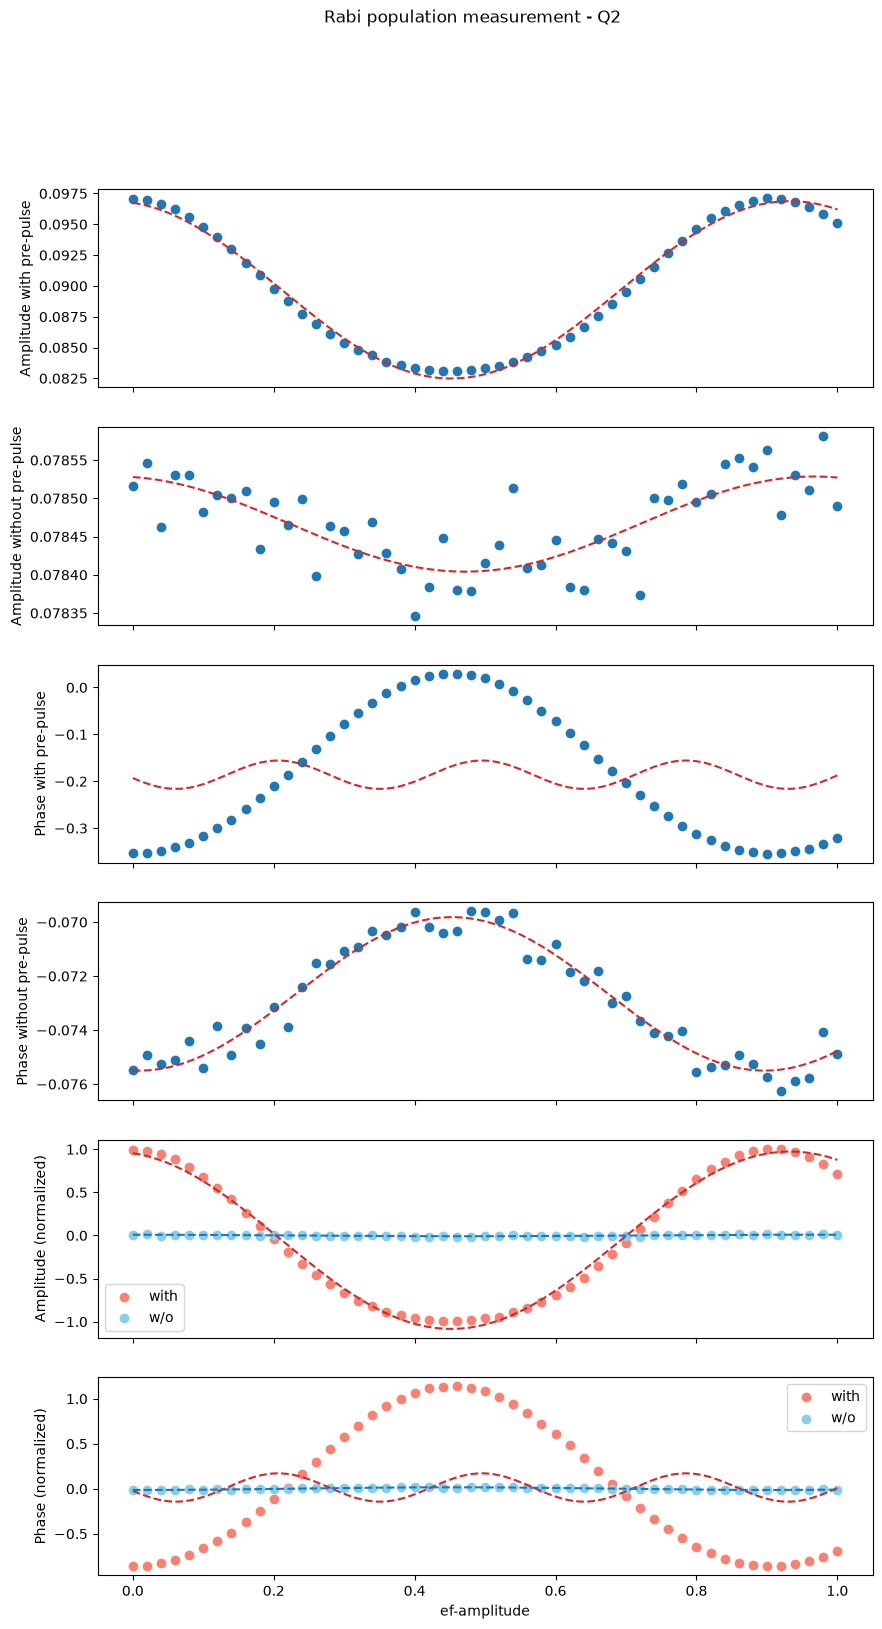

In [560]:
rpm_fig, rpm_ax = plt.subplots(6, 1, figsize=(10, 18), sharex=True)
rpm_fig.suptitle(f'Rabi population measurement - {qubit_to_measure.uid}')

rpm_ax[0].scatter(rpm_res['with']['amp'], rpm_res['with']['mag'])
rpm_ax[0].set_ylabel('Amplitude with pre-pulse')
rpm_ax[0].plot(rpm_amp_plot, func_osc(rpm_amp_plot, *rpm_popt['with']['mag']),
               color='tab:red', linestyle='dashed')

rpm_ax[1].scatter(rpm_res['wo']['amp'], rpm_res['wo']['mag'])
rpm_ax[1].set_ylabel('Amplitude without pre-pulse')
rpm_ax[1].plot(rpm_amp_plot, func_osc(rpm_amp_plot, *rpm_popt['wo']['mag']),
               color='tab:red', linestyle='dashed')

rpm_ax[2].scatter(rpm_res['with']['amp'], rpm_res['with']['pha'])
rpm_ax[2].set_ylabel('Phase with pre-pulse')
rpm_ax[2].plot(rpm_amp_plot, func_osc(rpm_amp_plot, *rpm_popt['with']['pha']),
               color='tab:red', linestyle='dashed')

rpm_ax[3].scatter(rpm_res['wo']['amp'], rpm_res['wo']['pha'])
rpm_ax[3].set_ylabel('Phase without pre-pulse')
rpm_ax[3].plot(rpm_amp_plot, func_osc(rpm_amp_plot, *rpm_popt['wo']['pha']),
               color='tab:red', linestyle='dashed')

_, offset, norm = normalize_1d_osc(rpm_res['with']['mag'])

rpm_ax[4].scatter(rpm_res['with']['amp'],
                  normalize_1d_osc(rpm_res['with']['mag'])[0],
                  label='with', color='salmon')
rpm_ax[4].plot(rpm_amp_plot,
               normalize_1d_osc(func_osc(rpm_amp_plot, *rpm_popt['with']['mag']),
                                offset, norm)[0],
               color='tab:red', linestyle='dashed')
rpm_ax[4].scatter(rpm_res['wo']['amp'],
                  normalize_1d_osc(rpm_res['wo']['mag'], norm=norm)[0],
                  label='w/o', color='skyblue')
rpm_ax[4].set_ylabel('Amplitude (normalized)')
rpm_ax[4].plot(rpm_amp_plot,
               normalize_1d_osc(func_osc(rpm_amp_plot, *rpm_popt['wo']['mag']),
                                norm=norm)[0],
               color='tab:blue', linestyle='dashed')
rpm_ax[4].legend()

_, offset, norm = normalize_1d_osc(rpm_res['with']['pha'])

rpm_ax[5].scatter(rpm_res['with']['amp'],
                  normalize_1d_osc(rpm_res['with']['pha'])[0],
                  label='with', color='salmon')
rpm_ax[5].plot(rpm_amp_plot,
               normalize_1d_osc(func_osc(rpm_amp_plot, *rpm_popt['with']['pha']),
                                offset, norm)[0],
               color='tab:red', linestyle='dashed')
rpm_ax[5].scatter(rpm_res['wo']['amp'],
                  normalize_1d_osc(rpm_res['wo']['pha'], norm=norm)[0],
                  label='w/o', color='skyblue')
rpm_ax[5].set_ylabel('Phase (normalized)')
rpm_ax[5].plot(rpm_amp_plot,
               normalize_1d_osc(func_osc(rpm_amp_plot, *rpm_popt['wo']['pha']),
                                norm=norm)[0],
               color='tab:blue', linestyle='dashed')
rpm_ax[5].legend()

rpm_ax[-1].set_xlabel('ef-amplitude')

file_path = get_path_to_file('RPM_full_amp_sweep_', '.png')
rpm_fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Pi Pulse Check

##### Analysis Plots

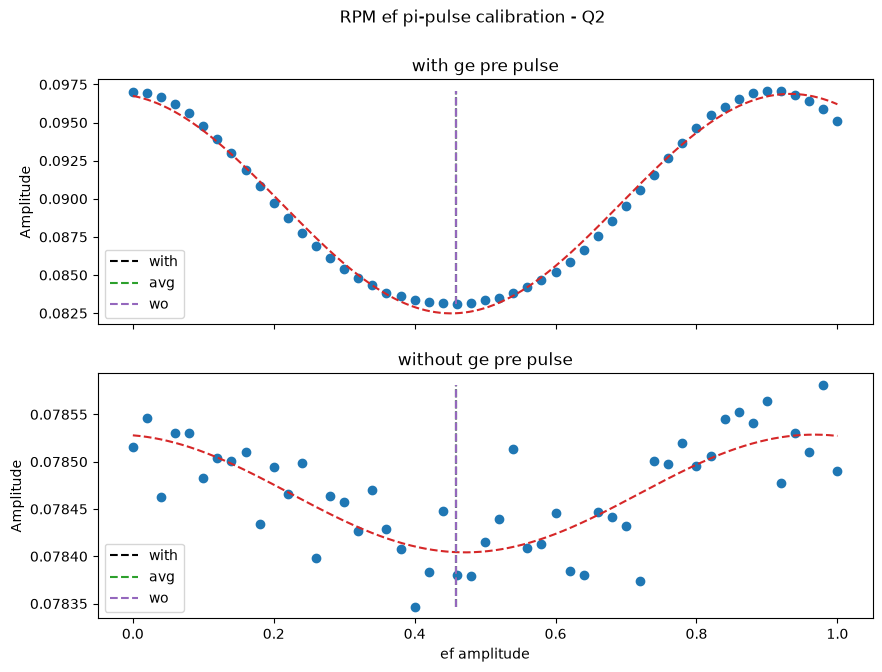

In [561]:
# extract min / max pulse amplitudes (old cell 346)
signal_in_mag = True

if signal_in_mag:
    fit_params_with = rpm_popt['with']['mag']
    fit_params_wo = rpm_popt['wo']['mag']
    with_dat = rpm_res['with']['mag']
    wo_dat = rpm_res['wo']['mag']
    ylabel = 'Amplitude'
else:
    fit_params_with = rpm_popt['with']['pha']
    fit_params_wo = rpm_popt['wo']['pha']
    with_dat = rpm_res['with']['pha']
    wo_dat = rpm_res['wo']['pha']
    ylabel = 'Phase'

# alternatives, kept from the old notebook:
# amp_with = fit_params_with[1] / fit_params_with[0]
# amp_wo = fit_params_wo[1] / fit_params_wo[0]
# amp_with = rpm_amp_plot[np.argmax(func_osc(rpm_amp_plot, *fit_params_with))]

amp_with = 0.458069
amp_wo = amp_with

amp_avg = (amp_with + amp_wo) / 2

cal_fig, cal_axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
cal_fig.suptitle(f'RPM ef pi-pulse calibration - {qubit_to_measure.uid}')

cal_axs[0].scatter(rpm_res['wo']['amp'], with_dat)
cal_axs[0].plot(rpm_amp_plot, func_osc(rpm_amp_plot, *fit_params_with),
                color='tab:red', linestyle='dashed')
cal_axs[0].vlines([amp_with], with_dat.min(), with_dat.max(), color='black',
                  linestyle='dashed', label='with')
cal_axs[0].vlines([amp_avg], with_dat.min(), with_dat.max(), color='tab:green',
                  linestyle='dashed', label='avg')
cal_axs[0].vlines([amp_wo], with_dat.min(), with_dat.max(), color='tab:purple',
                  linestyle='dashed', label='wo')
cal_axs[0].legend()
cal_axs[0].set_ylabel(ylabel)
cal_axs[0].set_title('with ge pre pulse')

cal_axs[1].scatter(rpm_res['wo']['amp'], wo_dat)
cal_axs[1].plot(rpm_amp_plot, func_osc(rpm_amp_plot, *fit_params_wo),
                color='tab:red', linestyle='dashed')
cal_axs[1].vlines([amp_with], wo_dat.min(), wo_dat.max(), color='black',
                  linestyle='dashed', label='with')
cal_axs[1].vlines([amp_avg], wo_dat.min(), wo_dat.max(), color='tab:green',
                  linestyle='dashed', label='avg')
cal_axs[1].vlines([amp_wo], wo_dat.min(), wo_dat.max(), color='tab:purple',
                  linestyle='dashed', label='wo')
cal_axs[1].legend()
cal_axs[1].set_xlabel('ef amplitude')
cal_axs[1].set_ylabel(ylabel)
cal_axs[1].set_title('without ge pre pulse')

file_path = get_path_to_file('RPM_x180_ef_calibration_', '.png')
cal_fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

##### Update Parameters

In [562]:
# old: x180_ef_rpm = pulse_library.gaussian(
#          uid="x180_ef", length=qubit_parameters["qb_ef_len_qrpm"],
#          amplitude=amp_avg)
#      qubit_parameters["pi_ef_amp_qrpm"] = amp_avg
# set to a value != None to override the value extracted above.
manual_ef_drive_amplitude_pi = None
ef_drive_amplitude_pi_rpm = float(amp_avg)
if manual_ef_drive_amplitude_pi is not None:
    ef_drive_amplitude_pi_rpm = float(manual_ef_drive_amplitude_pi)

temporary_parameters[qubit_to_measure.uid].ef_drive_amplitude_pi = (
    ef_drive_amplitude_pi_rpm
)

if update_global_parameters:
    qubit_to_measure.parameters = deepcopy(
        temporary_parameters[qubit_to_measure.uid]
    )
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

print('RPM ef drive amplitude pi: ', ef_drive_amplitude_pi_rpm)
print('ef drive amplitude pi (QPU): ',
      qubit_to_measure.parameters.ef_drive_amplitude_pi)

RPM ef drive amplitude pi:  0.458069
ef drive amplitude pi (QPU):  0.45806870360167845


### Population Measurement

#### Experiment Parameters

In [563]:
update_global_parameters = False

n_avg_exponent = 17

# old: rep_count = 1 of the mock_sweep
repetitions = 20

qubit_to_measure = qubits[0]

# the RPM pi-pulse calibrated above; the rest of the RPM parameters
# (ef_drive_pulse / ef_drive_length / resonance_frequency_ef) is unchanged.
temporary_parameters = {}
temp_pars = deepcopy(qubit_to_measure.parameters)
# temp_pars.ef_drive_pulse = ef_drive_pulse
# temp_pars.ef_drive_length = ef_drive_len|gth
temp_pars.ef_drive_amplitude_pi = ef_drive_amplitude_pi_rpm
temporary_parameters[qubit_to_measure.uid] = temp_pars

print('ef drive amplitude pi: ', temp_pars.ef_drive_amplitude_pi)
print('Number of averages:    ', 2**n_avg_exponent)
print('Repetitions:           ', repetitions)

ef drive amplitude pi:  0.458069
Number of averages:     65536
Repetitions:            20


#### Run Workflow

In [564]:
options = quick_rabi_population_experiment_workflow.options()
options.count(2**n_avg_exponent)

exp_workflow = quick_rabi_population_experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    repetitions=repetitions,
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

[2026.09.04 10:14:37.938] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.04 10:14:37.940] INFO      Workflow 'quick_rabi_population': execution started at 2026-09-04             
[2026.09.04 10:14:37.940] INFO      07:14:37.937715Z                                                              
[2026.09.04 10:14:37.940] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.04 10:14:38.141] INFO    Task 'temporary_qpu': started at 2026-09-04 07:14:38.141921Z
[2026.09.04 10:14:38.184] INFO    Task 'temporary_qpu': ended at 2026-09-04 07:14:38.184968Z
[2026.09.04 10:14:38.275] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-04 
[2026.09.04 10:14:38.275] INFO    07:14:38.275511Z
[2026.09.04 10:14:38.331] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-04 07:14:38.331759Z
[2026.09.04 10:14:38.419] INFO    Task 'create_quick_rabi_population_experiment': sta

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\3001955999.py:36: FutureWarning: `QPU.measure_section_length` is deprecated and will be removed in LabOne Q 26.7.0. The functionality has been moved to implementations of `QuantumOperations` for qubit types where this property is meaningful.
  max_measure_section_length = qpu.measure_section_length([qubit])


[2026.09.04 10:14:38.701] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.09.04 10:14:38.701] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.09.04 10:14:38.701] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.09.04 10:14:38.701] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.09.04 10:14:38.708] INFO    Schedule completed. [0.001 s]
[2026.09.04 10:14:38.709] INFO    Code generation completed for all AWGs. [0.005 s]
[2026.09.04 10:14:38.709] INFO    Completed compilation step 1 of 1. [0.009 s]
[2026.09.04 10:14:38.722] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.04 10:14:38.723] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.09.04 10:14:38.724] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.04 10

#### Analysis Plots

In [575]:
result = workflow_result.output

# old: rpm_res[key] = {'mag_min': np.abs(my_results.get_data(f"rpm_{key}_min")), ...}
rpm_res = {}
for pre_pulse in ['with', 'wo']:
    data = {
        point: result[
            dsl.handles.result_handle(qubit_to_measure.uid,
                                      suffix=f'{pre_pulse}_{point}')
        ].data
        for point in ['min', 'max']
    }
    rpm_res[pre_pulse] = {
        'mag_min': np.abs(data['min']),
        'pha_min': np.angle(data['min']),
        'mag_max': np.abs(data['max']),
        'pha_max': np.angle(data['max']),
        'I_max': np.real(data['max']),
        'Q_max': np.imag(data['max']),
        'I_min': np.real(data['min']),
        'Q_min': np.imag(data['min']),
    }

qrpm_dict = qrpm_dict_from_results([rpm_res])

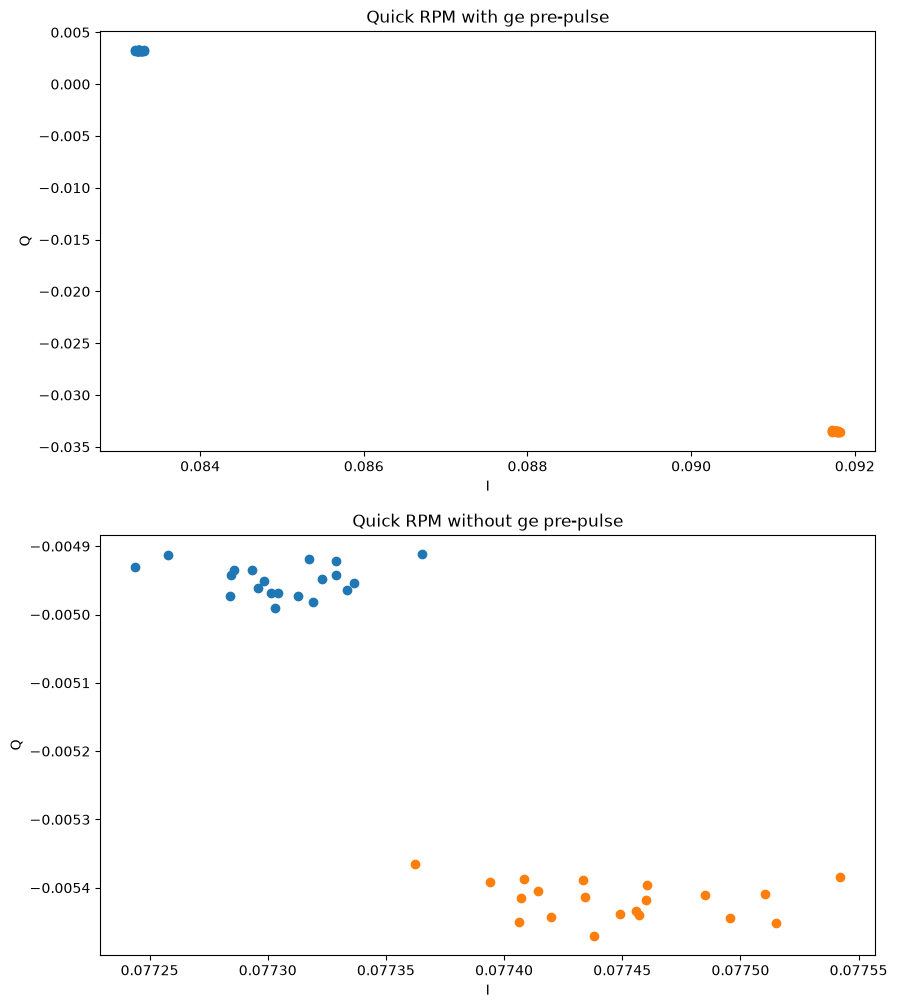

In [576]:
quick_rpm_fig_iq, quick_rpm_axs_iq = plt.subplots(2, 1, figsize=(10, 12))

quick_rpm_axs_iq[0].scatter(rpm_res['with']['I_max'], rpm_res['with']['Q_max'])
quick_rpm_axs_iq[0].scatter(rpm_res['with']['I_min'], rpm_res['with']['Q_min'])
quick_rpm_axs_iq[0].set_xlabel('I')
quick_rpm_axs_iq[0].set_ylabel('Q')
quick_rpm_axs_iq[0].set_title('Quick RPM with ge pre-pulse')

quick_rpm_axs_iq[1].scatter(rpm_res['wo']['I_max'], rpm_res['wo']['Q_max'])
quick_rpm_axs_iq[1].scatter(rpm_res['wo']['I_min'], rpm_res['wo']['Q_min'])
quick_rpm_axs_iq[1].set_xlabel('I')
quick_rpm_axs_iq[1].set_ylabel('Q')
quick_rpm_axs_iq[1].set_title('Quick RPM without ge pre-pulse')

file_path = get_path_to_file('Quick_RPM_IQ_', '.png')
quick_rpm_fig_iq.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

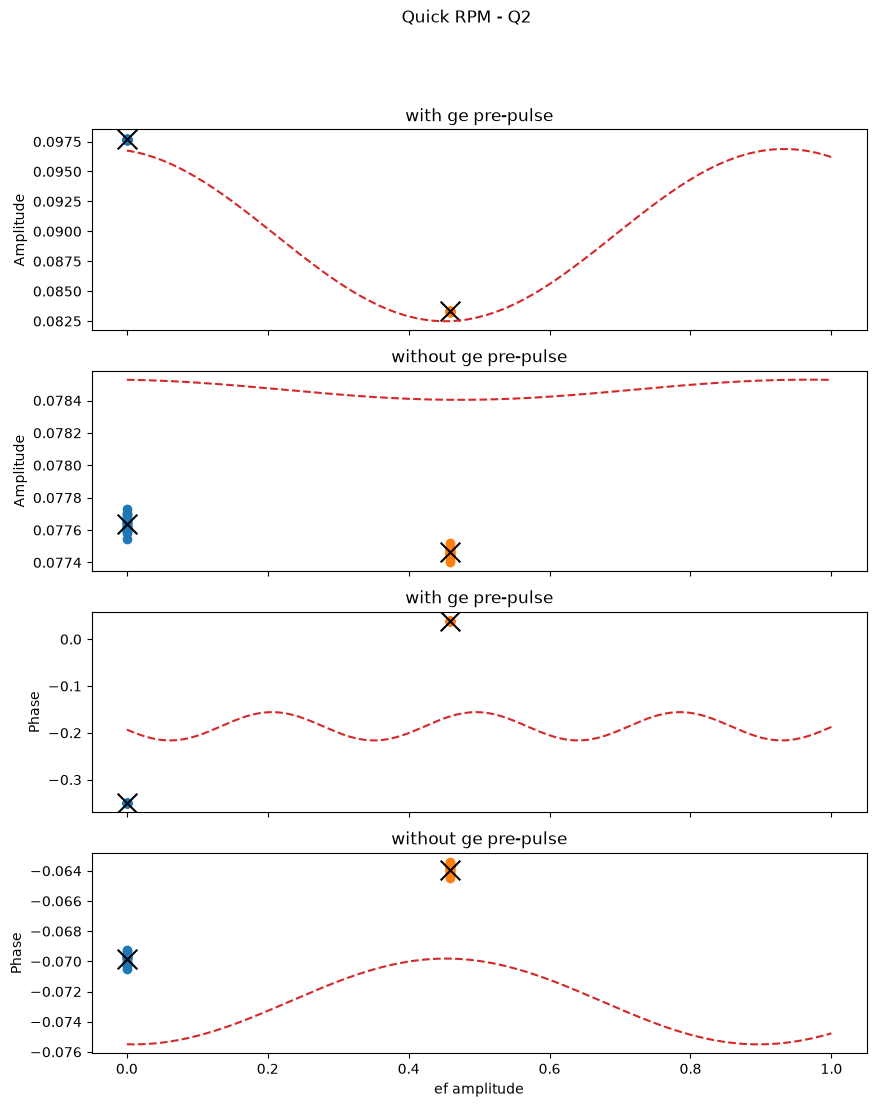

In [577]:
quick_rpm_fig, quick_rpm_axs = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
quick_rpm_fig.suptitle(f'Quick RPM - {qubit_to_measure.uid}')

y_min = np.repeat(0, rpm_res['with']['mag_min'].size)
# old: y_max = np.repeat(x180_ef_rpm.amplitude, ...)
y_max = np.repeat(ef_drive_amplitude_pi_rpm, rpm_res['with']['mag_min'].size)

for axis, pre_pulse, key in zip(
    quick_rpm_axs,
    ['with', 'wo', 'with', 'wo'],
    ['mag', 'mag', 'pha', 'pha'],
):
    axis.scatter(y_min, rpm_res[pre_pulse][f'{key}_min'])
    axis.scatter(y_max, rpm_res[pre_pulse][f'{key}_max'])
    axis.scatter(np.mean(y_min), np.mean(rpm_res[pre_pulse][f'{key}_min']),
                 marker='x', color='black', s=200)
    axis.scatter(np.mean(y_max), np.mean(rpm_res[pre_pulse][f'{key}_max']),
                 marker='x', color='black', s=200)
    axis.plot(rpm_amp_plot, func_osc(rpm_amp_plot, *rpm_popt[pre_pulse][key]),
              color='tab:red', linestyle='dashed')

for axis, ylabel, title in zip(
    quick_rpm_axs,
    ['Amplitude', 'Amplitude', 'Phase', 'Phase'],
    ['with ge pre-pulse', 'without ge pre-pulse',
     'with ge pre-pulse', 'without ge pre-pulse'],
):
    axis.set_ylabel(ylabel)
    axis.set_title(title)

quick_rpm_axs[-1].set_xlabel('ef amplitude')

amps_with_mag = np.abs(rpm_res['with']['mag_min'] - rpm_res['with']['mag_max'])
amps_with_pha = np.abs(rpm_res['with']['pha_min'] - rpm_res['with']['pha_max'])

amps_wo_mag = np.abs(rpm_res['wo']['mag_min'] - rpm_res['wo']['mag_max'])
amps_wo_pha = np.abs(rpm_res['wo']['pha_min'] - rpm_res['wo']['pha_max'])

mean_amps_with_mag = np.mean(amps_with_mag)
mean_amps_with_pha = np.mean(amps_with_pha)

mean_amps_wo_mag = np.mean(amps_wo_mag)
mean_amps_wo_pha = np.mean(amps_wo_pha)

file_path = get_path_to_file('Quick_RPM_', '.png')
quick_rpm_fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

Text(0.5, 0, 'Measurement')

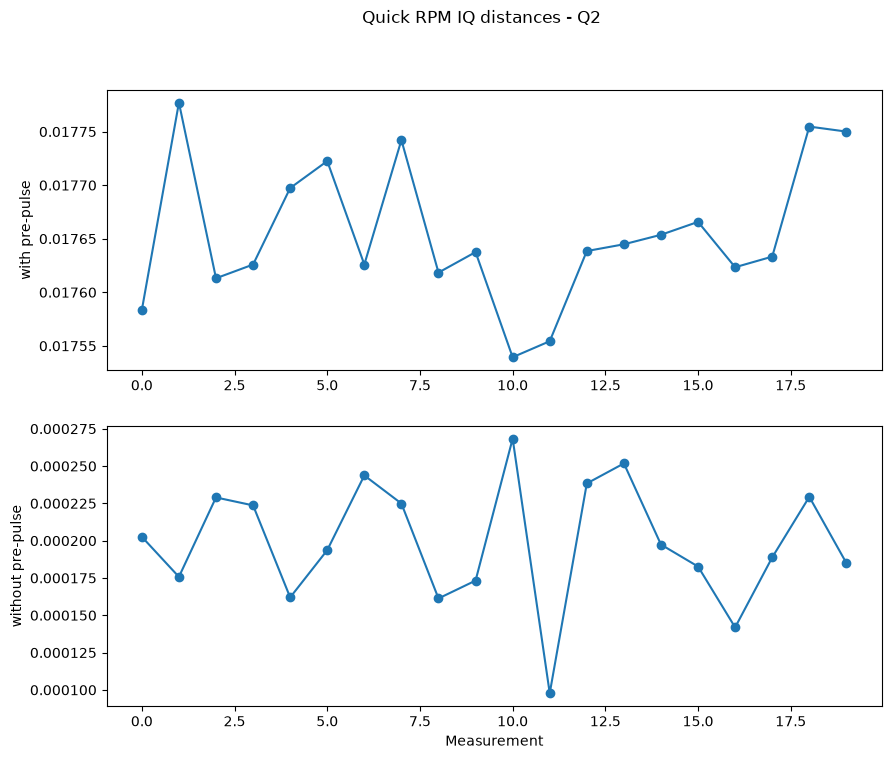

In [511]:
max_iq_with = np.column_stack((rpm_res['with']['I_max'], rpm_res['with']['Q_max']))
min_iq_with = np.column_stack((rpm_res['with']['I_min'], rpm_res['with']['Q_min']))
iq_amp_with = np.linalg.norm(max_iq_with - min_iq_with, axis=1)

max_iq_wo = np.column_stack((rpm_res['wo']['I_max'], rpm_res['wo']['Q_max']))
min_iq_wo = np.column_stack((rpm_res['wo']['I_min'], rpm_res['wo']['Q_min']))
iq_amp_wo = np.linalg.norm(max_iq_wo - min_iq_wo, axis=1)

iq_amp_fig, iq_amp_axs = plt.subplots(2, 1, figsize=(10, 8))
iq_amp_fig.suptitle(f'Quick RPM IQ distances - {qubit_to_measure.uid}')
iq_amp_axs[0].plot(iq_amp_with, marker='o')
iq_amp_axs[0].set_ylabel('with pre-pulse')
iq_amp_axs[1].plot(iq_amp_wo, marker='o')
iq_amp_axs[1].set_ylabel('without pre-pulse')
iq_amp_axs[1].set_xlabel('Measurement')

### Temperature

#### Analysis Plots

f_q:    5.008681684374856 GHz
anharm: 0.2199173853286028 GHz
Mean pe:           0.011116495034968001
Mean temperature:  53.41351243054722 mK


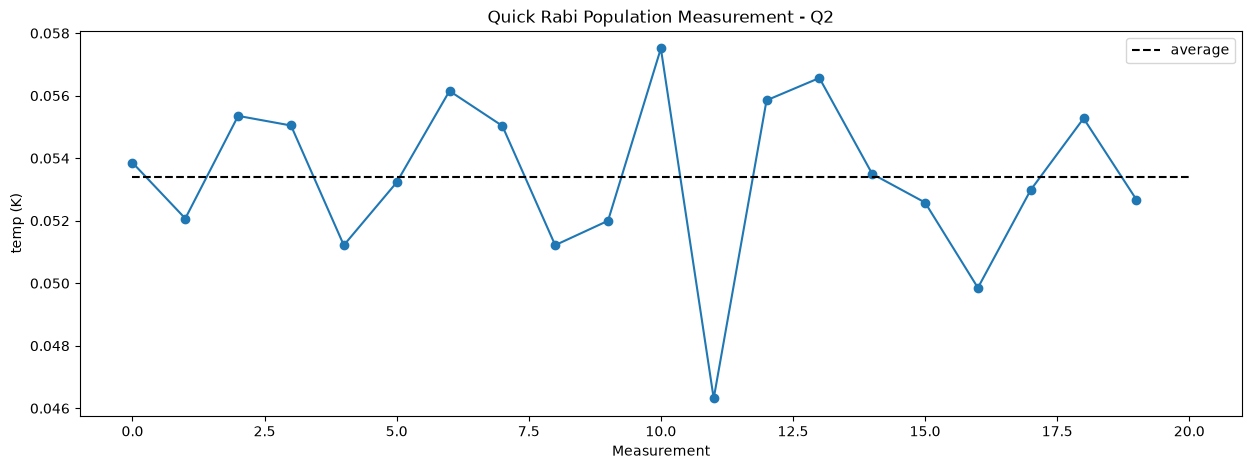

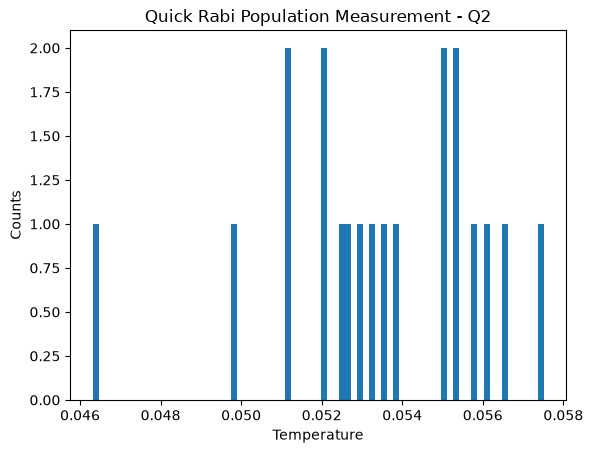

In [512]:
f_q, anharm = get_qubit_temperature_parameters(qubit_to_measure)
print('f_q:   ', f_q, 'GHz')
print('anharm:', anharm, 'GHz')

# old: rpm_pe = amps_wo_mag / (amps_with_mag + amps_wo_mag)
rpm_pe = iq_amp_wo / (iq_amp_wo + iq_amp_with)

rpm_temp = T_calc(C=rpm_pe / (1 - rpm_pe), f_q=f_q)

quick_rpm_temps_fig, quick_rpm_temps_axs = plt.subplots(figsize=(15, 5))
quick_rpm_temps_axs.plot(np.arange(len(rpm_pe)), rpm_temp, marker='o')
quick_rpm_temps_axs.hlines([np.mean(rpm_temp)], 0, len(rpm_pe), color='black',
                           linestyle='dashed', label='average')
quick_rpm_temps_axs.set_ylabel('temp (K)')
quick_rpm_temps_axs.set_xlabel('Measurement')
quick_rpm_temps_axs.set_title(
    f'Quick Rabi Population Measurement - {qubit_to_measure.uid}'
)
quick_rpm_temps_axs.legend()

quick_rpm_temps_hist_fig, quick_rpm_temps_hist_ax = plt.subplots()
quick_rpm_temps_hist_ax.hist(rpm_temp, bins=75)
quick_rpm_temps_hist_ax.set_xlabel('Temperature')
quick_rpm_temps_hist_ax.set_ylabel('Counts')
quick_rpm_temps_hist_ax.set_title(
    f'Quick Rabi Population Measurement - {qubit_to_measure.uid}'
)

print('Mean pe:          ', np.mean(rpm_pe))
print('Mean temperature: ', np.mean(rpm_temp) * 1e3, 'mK')

file_path = get_path_to_file('Quick_RPM_temperature_', '.png')
quick_rpm_temps_fig.savefig(file_path, dpi=600, format='png',
                            bbox_inches='tight')

#### Update Parameters

In [514]:
data_rpm = {
    'ef_amplitude_sweep': ef_amplitudes,
    'rpm_mag_with': rpm_res['with']['mag_max'],
    'rpm_mag_wo': rpm_res['wo']['mag_max'],
    'iq_amp_with': iq_amp_with,
    'iq_amp_wo': iq_amp_wo,
    'rpm_pe': rpm_pe,
    'rpm_temp': rpm_temp,
    'ef_drive_amplitude_pi_rpm': ef_drive_amplitude_pi_rpm,
    'n_shots': 2**n_avg_exponent,
    'repetitions': repetitions,
    'f_q': f_q,
    'anharm': anharm,
    'comment': 'Quick Rabi population measurement, temperature in K',
}
data_rpm.update(qrpm_dict)
data_rpm.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_rpm['sample_name'] = sample_name
data_rpm['qubit_name'] = qubit_name
data_rpm['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('RPM_temperature_', '.mat')
savemat(file_path, data_rpm)
print(f'Saved Rabi population measurement to: {file_path}')

Saved Rabi population measurement to: N:\xld\qubit_thermometry_v2\ES-009-DE_1-2_9150\COOLDOWN_2026-09-02\Q2\20260903_222848_RPM_temperature_.mat


## Three Level Population Measurements

### Single-Point Experiment

#### Experiment Parameters

In [515]:
update_global_parameters = False

n_avg_exponent = 16

qubit_to_measure = qubits[0]

# old: readout_opt / readout_low passed to create_exp_population_full
temporary_parameters = {}
temp_pars = deepcopy(qubit_to_measure.parameters)
temporary_parameters[qubit_to_measure.uid] = temp_pars

print('ge drive amplitude pi:      ', temp_pars.ge_drive_amplitude_pi)
print('ef drive amplitude pi:      ', temp_pars.ef_drive_amplitude_pi)
print('Readout amplitude:          ', temp_pars.readout_amplitude)
print('Readout length:             ', temp_pars.readout_length)
print('Readout resonator frequency:', temp_pars.readout_resonator_frequency)
print('Reset delay length:         ', temp_pars.reset_delay_length)
print('Number of averages:         ', 2**n_avg_exponent)

ge drive amplitude pi:       0.3352897014347527
ef drive amplitude pi:       0.45806870360167845
Readout amplitude:           0.21964285714285714
Readout length:              1.977777777777778e-06
Readout resonator frequency: 5959692000.0
Reset delay length:          0.0003
Number of averages:          65536


#### Run Workflow

In [517]:
options = population_experiment_workflow.options()
options.count(2**n_avg_exponent)

exp_workflow = population_experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

[2026.09.03 22:36:13.027] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 22:36:13.027] INFO      Workflow 'population': execution started at 2026-09-03 19:36:13.027294Z       
[2026.09.03 22:36:13.027] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 22:36:13.480] INFO    Task 'temporary_qpu': started at 2026-09-03 19:36:13.480377Z
[2026.09.03 22:36:13.543] INFO    Task 'temporary_qpu': ended at 2026-09-03 19:36:13.543281Z
[2026.09.03 22:36:13.647] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-03 
[2026.09.03 22:36:13.648] INFO    19:36:13.647067Z
[2026.09.03 22:36:13.711] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-03 19:36:13.711306Z
[2026.09.03 22:36:13.847] INFO    Task 'create_population_experiment': started at 2026-09-03 19:36:13.847279Z
[2026.09.03 22:36:13.987] INFO    Task 'create_population_experiment': ended at 2026-09-03

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1166748630.py:62: FutureWarning: `QPU.measure_section_length` is deprecated and will be removed in LabOne Q 26.7.0. The functionality has been moved to implementations of `QuantumOperations` for qubit types where this property is meaningful.
  max_measure_section_length = qpu.measure_section_length([qubit])


[2026.09.03 22:36:14.200] INFO    Starting LabOne Q Compiler run...
[2026.09.03 22:36:14.200] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.09.03 22:36:14.211] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.09.03 22:36:14.212] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.09.03 22:36:14.214] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.09.03 22:36:14.216] INFO    Schedule completed. [0.001 s]
[2026.09.03 22:36:14.221] INFO    Code generation completed for all AWGs. [0.003 s]
[2026.09.03 22:36:14.221] INFO    Completed compilation step 1 of 1. [0.007 s]
[2026.09.03 22:36:14.231] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.03 22:36:14.231] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.09.03 22:36:14.231] INFO     ───────────────────

#### Analysis Plots

In [518]:
# old: print(results_population_full.get_data('x0_readout'))
pop_result = collect_population_from_result(
    workflow_result.output, qubit_to_measure.uid
)
for label in pop_label_list:
    print(f'{label}: {pop_result[label]}')

x0: (0.09168522688101977-0.03214570348732766j)
x1: (0.07969239155185429-0.003450577766298658j)
x2: (0.08328068326504064+0.004807697116669351j)
y0: (0.09169802380680495-0.03206164206096925j)
y1: (0.07954521580930972-0.003123462012990176j)
y2: (0.08315907188123058+0.005135831328452495j)


### Population Statistics

#### Experiment Parameters

In [519]:
update_global_parameters = False

n_avg_exponent = 16

# old: N = 3 #Number of measurements
n_measurements = 10

# estimators that are excluded from the plots (old `skip = ['TC2']`)
skip = [] #['TC2']

three_levels = True

qubit_to_measure = qubits[0]

temporary_parameters = {}
temp_pars = deepcopy(qubit_to_measure.parameters)
temporary_parameters[qubit_to_measure.uid] = temp_pars

f_q, anharm = get_qubit_temperature_parameters(qubit_to_measure)
print('f_q:               ', f_q, 'GHz')
print('anharm:            ', anharm, 'GHz')
print('Number of averages:', 2**n_avg_exponent)
print('Number of runs:    ', n_measurements)

f_q:                5.008681684374856 GHz
anharm:             0.2199173853286028 GHz
Number of averages: 65536
Number of runs:     10


#### Run Workflow

In [520]:
options = population_experiment_workflow.options()
options.count(2**n_avg_exponent)

pop_full_results = {}
pop_workflow_results = []

for i in range(n_measurements):
    print('Iteration: ', i)

    exp_workflow = population_experiment_workflow(
        session=session,
        qpu=qpu,
        qubit=qubit_to_measure.uid,
        options=options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result = exp_workflow.run()
    pop_workflow_results.append(workflow_result)

    pop_result = collect_population_from_result(
        workflow_result.output, qubit_to_measure.uid
    )
    for label in pop_label_list:
        pop_full_results.setdefault(label, []).append(pop_result[label])

for label in pop_label_list:
    pop_full_results[label] = np.array(pop_full_results[label])

print('Population array shape (runs,):', pop_full_results['x0'].shape)

Iteration:  0
[2026.09.03 22:41:28.319] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 22:41:28.319] INFO      Workflow 'population': execution started at 2026-09-03 19:41:28.319157Z       
[2026.09.03 22:41:28.319] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 22:41:28.601] INFO    Task 'temporary_qpu': started at 2026-09-03 19:41:28.601701Z
[2026.09.03 22:41:28.651] INFO    Task 'temporary_qpu': ended at 2026-09-03 19:41:28.651160Z
[2026.09.03 22:41:28.777] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-03 
[2026.09.03 22:41:28.780] INFO    19:41:28.777995Z
[2026.09.03 22:41:28.827] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-03 19:41:28.827201Z
[2026.09.03 22:41:28.942] INFO    Task 'create_population_experiment': started at 2026-09-03 19:41:28.942813Z
[2026.09.03 22:41:29.067] INFO    Task 'create_population_experiment': ended

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1166748630.py:62: FutureWarning: `QPU.measure_section_length` is deprecated and will be removed in LabOne Q 26.7.0. The functionality has been moved to implementations of `QuantumOperations` for qubit types where this property is meaningful.
  max_measure_section_length = qpu.measure_section_length([qubit])


[2026.09.03 22:41:29.280] INFO    Starting LabOne Q Compiler run...
[2026.09.03 22:41:29.280] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.09.03 22:41:29.289] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.09.03 22:41:29.290] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.09.03 22:41:29.290] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.09.03 22:41:29.290] INFO    Schedule completed. [0.000 s]
[2026.09.03 22:41:29.296] INFO    Code generation completed for all AWGs. [0.002 s]
[2026.09.03 22:41:29.296] INFO    Completed compilation step 1 of 1. [0.005 s]
[2026.09.03 22:41:29.296] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.03 22:41:29.304] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.09.03 22:41:29.306] INFO     ───────────────────

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1166748630.py:62: FutureWarning: `QPU.measure_section_length` is deprecated and will be removed in LabOne Q 26.7.0. The functionality has been moved to implementations of `QuantumOperations` for qubit types where this property is meaningful.
  max_measure_section_length = qpu.measure_section_length([qubit])


[2026.09.03 22:43:34.678] INFO    Completed compilation step 1 of 1. [0.006 s]
[2026.09.03 22:43:34.680] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.03 22:43:34.680] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.09.03 22:43:34.685] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.03 22:43:34.685] INFO      SHFQC_DEV12192        0         23            0           1      7936  
[2026.09.03 22:43:34.685] INFO      SHFQC_DEV12192_sg     0         32            3           2      1216  
[2026.09.03 22:43:34.685] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.03 22:43:34.685] INFO      TOTAL                           55            3                  9152  
[2026.09.03 22:43:34.685] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.03 22:43:34.700] INFO    Finished LabOne Q Compi

...

[2026.09.03 22:56:08.026] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.09.03 22:56:08.026] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.09.03 22:56:08.026] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.09.03 22:56:08.026] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.09.03 22:56:08.026] INFO    Schedule completed. [0.000 s]
[2026.09.03 22:56:08.026] INFO    Code generation completed for all AWGs. [0.002 s]
[2026.09.03 22:56:08.026] INFO    Completed compilation step 1 of 1. [0.004 s]
[2026.09.03 22:56:08.040] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.03 22:56:08.041] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.09.03 22:56:08.041] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.03 22

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1166748630.py:62: FutureWarning: `QPU.measure_section_length` is deprecated and will be removed in LabOne Q 26.7.0. The functionality has been moved to implementations of `QuantumOperations` for qubit types where this property is meaningful.
  max_measure_section_length = qpu.measure_section_length([qubit])


[2026.09.03 22:58:13.482] INFO    Schedule completed. [0.000 s]
[2026.09.03 22:58:13.485] INFO    Code generation completed for all AWGs. [0.003 s]
[2026.09.03 22:58:13.487] INFO    Completed compilation step 1 of 1. [0.007 s]
[2026.09.03 22:58:13.492] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.03 22:58:13.492] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.09.03 22:58:13.494] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.03 22:58:13.494] INFO      SHFQC_DEV12192        0         23            0           1      7936  
[2026.09.03 22:58:13.494] INFO      SHFQC_DEV12192_sg     0         32            3           2      1216  
[2026.09.03 22:58:13.496] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.03 22:58:13.497] INFO      TOTAL                           55            3                  9152  
[2026.09.03 22:58

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1166748630.py:62: FutureWarning: `QPU.measure_section_length` is deprecated and will be removed in LabOne Q 26.7.0. The functionality has been moved to implementations of `QuantumOperations` for qubit types where this property is meaningful.
  max_measure_section_length = qpu.measure_section_length([qubit])


[2026.09.03 23:00:18.787] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.09.03 23:00:18.788] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.09.03 23:00:18.788] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.09.03 23:00:18.792] INFO    Schedule completed. [0.001 s]
[2026.09.03 23:00:18.799] INFO    Code generation completed for all AWGs. [0.004 s]
[2026.09.03 23:00:18.801] INFO    Completed compilation step 1 of 1. [0.009 s]
[2026.09.03 23:00:18.805] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.03 23:00:18.805] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.09.03 23:00:18.805] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.03 23:00:18.805] INFO      SHFQC_DEV12192        0         23            0           1      7936  
[2026.09.03 23:

#### Analysis Plots

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1946881240.py:10: RuntimeWarning: invalid value encountered in log
  return -(h * f_q / k) / np.log(C)
C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\76333001.py:77: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root = fsolve(solve_fn, x0, args=(float(x), f_q_i, anharm_i))


TA1 | I mean: 50.896 rel. err: 0.0641 | Q mean: 51.196 rel. err: 0.0835
TB1 | I mean: 52.049 rel. err: 0.0478 | Q mean: 51.807 rel. err: 0.0407
TC1 | I mean: 52.061 rel. err: 0.0483 | Q mean: 51.811 rel. err: 0.0411
TA2 | I mean: 52.534 rel. err: 0.1032 | Q mean: 52.495 rel. err: 0.0419
TB2 | I mean: 50.101 rel. err: 0.1401 | Q mean: 52.246 rel. err: 0.0336
TC2 | I mean: 50.096 rel. err: 0.1409 | Q mean: 52.244 rel. err: 0.034
TA3 | I mean: 52.238 rel. err: nan | Q mean: 53.75 rel. err: nan
TB3 | I mean: 49.507 rel. err: nan | Q mean: 53.771 rel. err: 0.1022
TC3 | I mean: 49.495 rel. err: nan | Q mean: 53.809 rel. err: 0.104


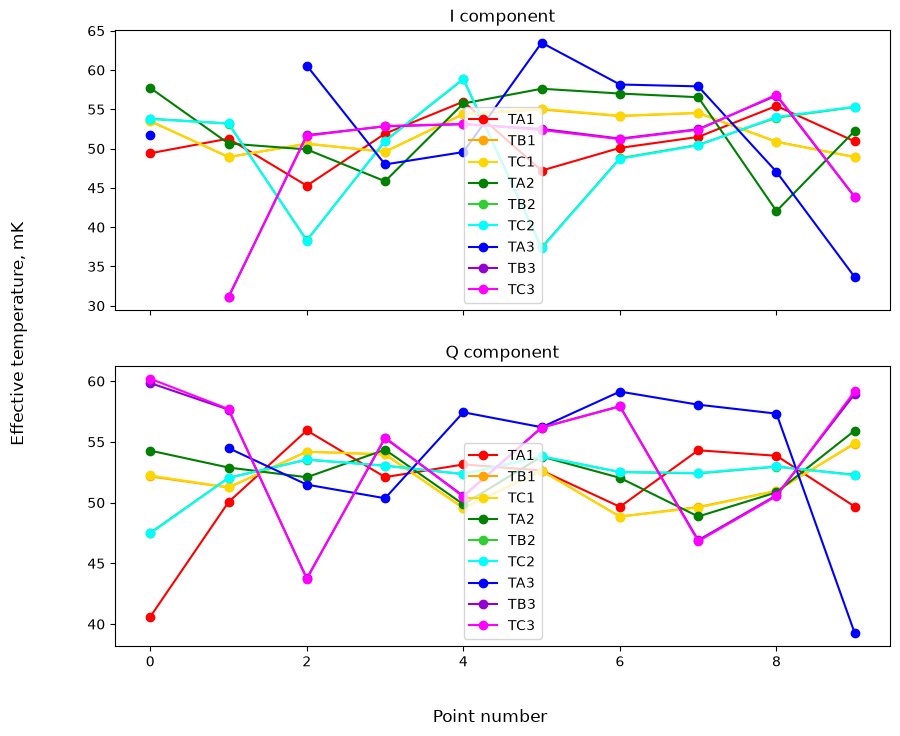

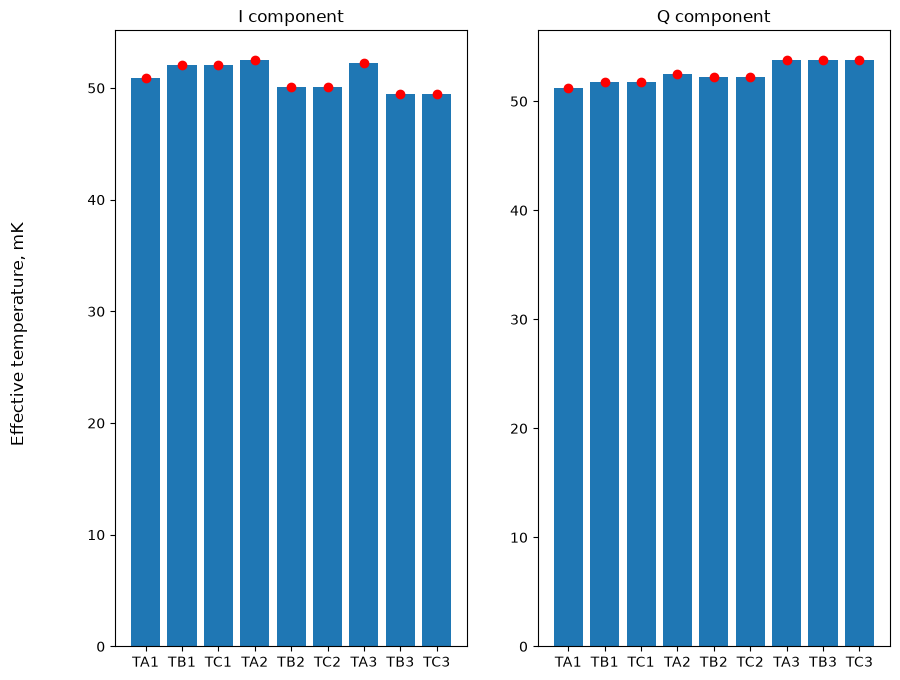

In [533]:
# fast temperature extraction (projection onto I and Q at phase 0)
TABC_I, TABC_Q = make_all_temperatures(pop_full_results, f_q, anharm,
                                       three_levels=three_levels)

fig, ax = plot_temperatures(TABC_I, TABC_Q, skip=skip)

file_path = get_path_to_file('Population_stat_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

# %%
STAT_I = get_stat(TABC_I)
STAT_Q = get_stat(TABC_Q)

# give plot_stat copies so it cannot modify the original statistis
STAT_I_plot = {k: v.copy() for k, v in STAT_I.items()}
STAT_Q_plot = {k: v.copy() for k, v in STAT_Q.items()}

fig, ax = plot_stat(STAT_I_plot, STAT_Q_plot)

for k in STAT_I:
    print(k, '| I mean:', np.round(STAT_I[k][0], 3),
          'rel. err:', np.round(STAT_I[k][2], 4),
          '| Q mean:', np.round(STAT_Q[k][0], 3),
          'rel. err:', np.round(STAT_Q[k][2], 4))

file_path = get_path_to_file('Population_stat_bars_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1946881240.py:10: RuntimeWarning: invalid value encountered in log
  return -(h * f_q / k) / np.log(C)
C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\76333001.py:77: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root = fsolve(solve_fn, x0, args=(float(x), f_q_i, anharm_i))


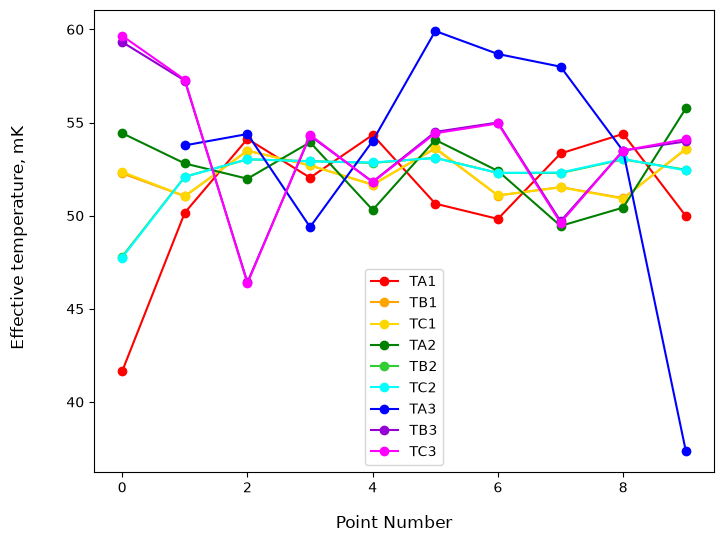

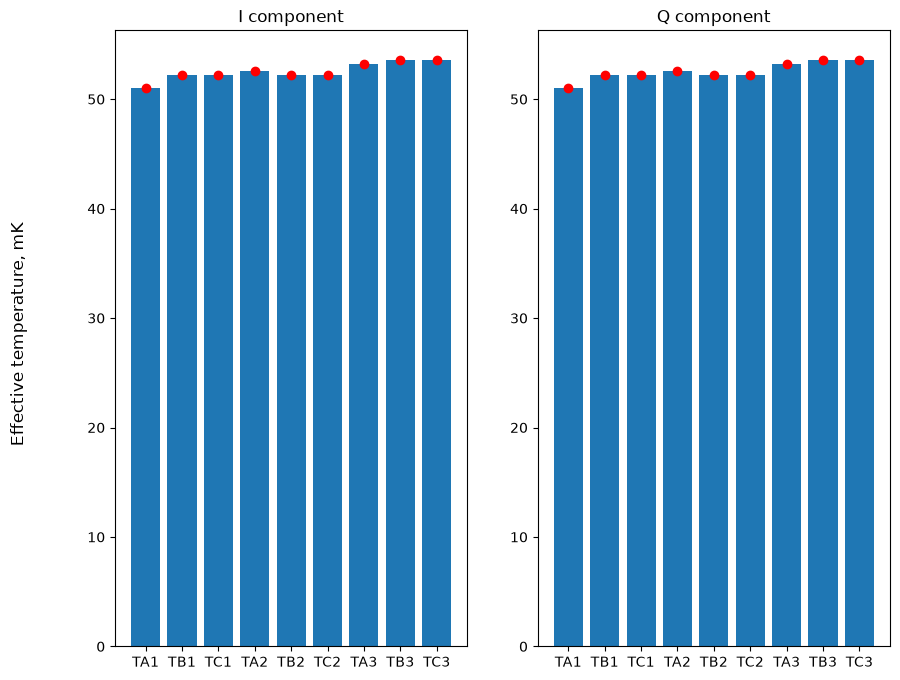

In [534]:
# population, 3-level method, proper rotation ('parallel' approach)
ABC = get_ABC_parallel(pop_full_results)
TABC = get_temperature(ABC, f_q, anharm, three_levels=three_levels)

fig, ax = plot_temp_single(TABC, skip=skip)

STAT = get_stat(TABC)
fig_stat, ax_stat = plot_stat(STAT, STAT)

file_path = get_path_to_file('Population_stat_parallel_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

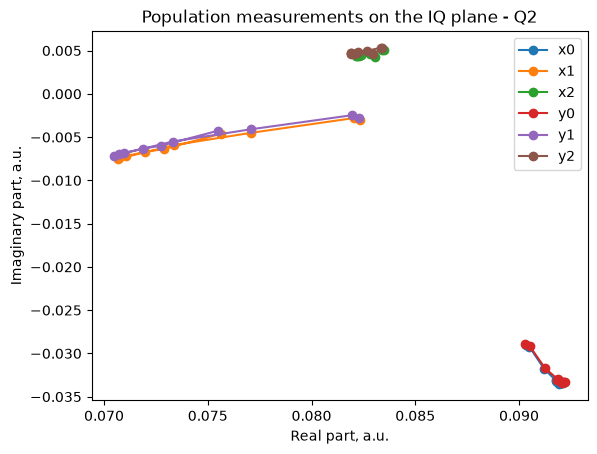

In [535]:
fig, ax = plt.subplots()
ax.set_title(f'Population measurements on the IQ plane - {qubit_to_measure.uid}')
for label in pop_label_list:
    ax.plot(pop_full_results[label].real, pop_full_results[label].imag, 'o-',
            label=label)
ax.set_xlabel('Real part, a.u.')
ax.set_ylabel('Imaginary part, a.u.')
ax.legend()

file_path = get_path_to_file('Population_stat_IQ_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')


Mean pe/pg C_real: 0.6384451687206573
Mean pe/pg C_imag: 1.1891413768123493
Mean pe/pg A_real: 0.8989915926569281
Mean pe/pg A_imag: 0.937484506321067
Mean pe/pg B_real: 0.9068446572525303
Mean pe/pg B_imag: 0.997624182728359


C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1946881240.py:10: RuntimeWarning: invalid value encountered in log
  return -(h * f_q / k) / np.log(C)


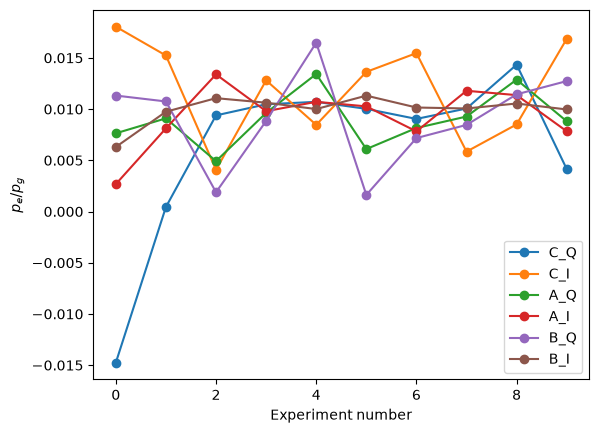

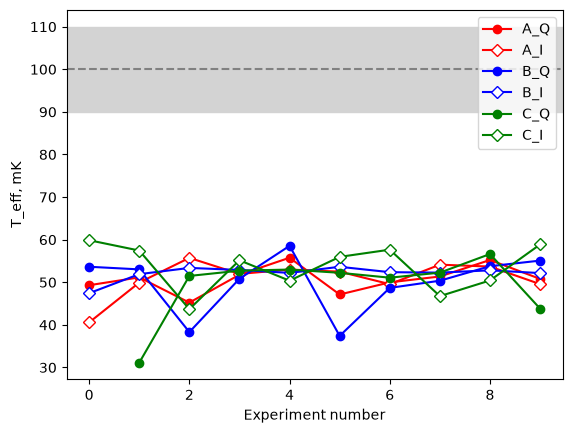

In [536]:
# pe/pg and temperature per estimator, written out explicitly (old cells
# 407-410). `get_C_from_ABC` does the same for a whole ABC dictionary.
A_real = ((pop_full_results['x0'].real - pop_full_results['x1'].real)
          / (pop_full_results['y0'].real - pop_full_results['y1'].real))
A_imag = ((pop_full_results['x0'].imag - pop_full_results['x1'].imag)
          / (pop_full_results['y0'].imag - pop_full_results['y1'].imag))

B_real = ((pop_full_results['x1'].real - pop_full_results['y1'].real)
          / (pop_full_results['y0'].real - pop_full_results['x2'].real))
B_imag = ((pop_full_results['x1'].imag - pop_full_results['y1'].imag)
          / (pop_full_results['y0'].imag - pop_full_results['x2'].imag))

C_real = ((pop_full_results['x0'].real - pop_full_results['y0'].real)
          / (pop_full_results['x1'].real - pop_full_results['x2'].real))
C_imag = ((pop_full_results['x0'].imag - pop_full_results['y0'].imag)
          / (pop_full_results['x1'].imag - pop_full_results['x2'].imag))

fig, ax = plt.subplots()
ax.plot(C_real, '-o', label='C_Q')
ax.plot(C_imag, '-o', label='C_I')
ax.plot(1 - A_real, '-o', label='A_Q')
ax.plot(1 - A_imag, '-o', label='A_I')
ax.plot(B_real / (B_real + 1), '-o', label='B_Q')
ax.plot(B_imag / (B_imag + 1), '-o', label='B_I')
ax.set_xlabel('Experiment number')
ax.set_ylabel('$p_e/p_g$')
ax.legend()

print('Mean pe/pg C_real:', np.mean(C_real) * 1e2)
print('Mean pe/pg C_imag:', np.mean(C_imag) * 1e2)
print('Mean pe/pg A_real:', np.mean(1 - A_real) * 1e2)
print('Mean pe/pg A_imag:', np.mean(1 - A_imag) * 1e2)
print('Mean pe/pg B_real:', np.mean(B_real / (B_real + 1)) * 1e2)
print('Mean pe/pg B_imag:', np.mean(B_imag / (B_imag + 1)) * 1e2)

T_A_real = T_calc(1 - A_real, f_q) * 1e3
T_A_imag = T_calc(1 - A_imag, f_q) * 1e3
T_B_real = T_calc(B_real / (B_real + 1), f_q) * 1e3
T_B_imag = T_calc(B_imag / (B_imag + 1), f_q) * 1e3
T_C_real = T_calc(C_real, f_q) * 1e3
T_C_imag = T_calc(C_imag, f_q) * 1e3

fig, ax = plt.subplots()
ax.plot(T_A_real, '-o', label='A_Q', color='red')
ax.plot(T_A_imag, '-D', mfc='w', label='A_I', color='red')
ax.plot(T_B_real, '-o', label='B_Q', color='blue')
ax.plot(T_B_imag, '-D', mfc='w', label='B_I', color='blue')
ax.plot(T_C_real, '-o', label='C_Q', color='green')
ax.plot(T_C_imag, '-D', mfc='w', label='C_I', color='green')
ax.set_xlabel('Experiment number')
ax.set_ylabel('T_eff, mK')
ax.axhline(100, linestyle='dashed', color='grey')
ax.axhspan(90, 110, color='lightgrey')
ax.legend()

file_path = get_path_to_file('Population_stat_temperatures_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [537]:
# old: Data_T_stat.update(pop_full_results);
#      Data_T_stat.update(qubit_parameters._params);
#      Data_T_stat.update(lo_settings._params)
data_t_stat = {f'pop_{label}': pop_full_results[label]
               for label in pop_label_list}
data_t_stat.update({f'{k}_I': v for k, v in TABC_I.items()})
data_t_stat.update({f'{k}_Q': v for k, v in TABC_Q.items()})
data_t_stat.update({f'{k}_parallel': v for k, v in TABC.items()})
data_t_stat.update({
    'T_A_real': T_A_real,
    'T_A_imag': T_A_imag,
    'T_B_real': T_B_real,
    'T_B_imag': T_B_imag,
    'T_C_real': T_C_real,
    'T_C_imag': T_C_imag,
    'n_measurements': n_measurements,
    'n_shots': 2**n_avg_exponent,
    'f_q': f_q,
    'anharm': anharm,
    'three_levels': three_levels,
    'comment': ('Three level population statistics, array dim [run]; '
                'temperatures in mK'),
})
data_t_stat.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_t_stat['sample_name'] = sample_name
data_t_stat['qubit_name'] = qubit_name
data_t_stat['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Teff_stat_all_unsh_', '.mat')
savemat(file_path, data_t_stat)
print(f'Saved population statistics to: {file_path}')

Saved population statistics to: N:\xld\qubit_thermometry_v2\ES-009-DE_1-2_9150\COOLDOWN_2026-09-02\Q2\20260903_233715_Teff_stat_all_unsh_.mat


### Rotation and Measurement Optimisation

#### Experiment Parameters

In [538]:
# No new experiment is run here: the projection phase of the data acquired in
# `### Population Statistics` is optimized.
phase_arr = np.linspace(-1, 1, 65) * np.pi / 2

# estimators that are excluded from the optimization (old skip = ['TA1','TA3'])
skip_optimization = [] #['TA1', 'TA3']

# optional: use only a slice of the runs (old `pop_slice`)
# pop_slice = {k: v[1:33] for k, v in pop_full_results.items()}
pop_data = pop_full_results

#### Analysis Plots

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1946881240.py:10: RuntimeWarning: invalid value encountered in log
  return -(h * f_q / k) / np.log(C)
C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\76333001.py:77: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root = fsolve(solve_fn, x0, args=(float(x), f_q_i, anharm_i))


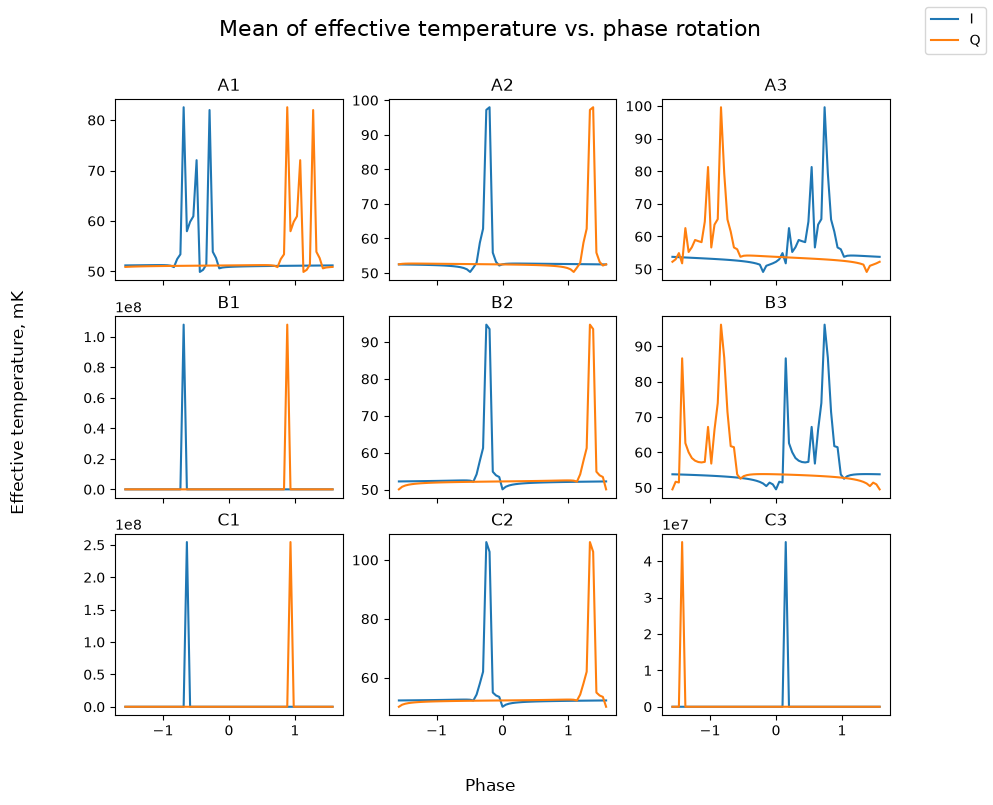

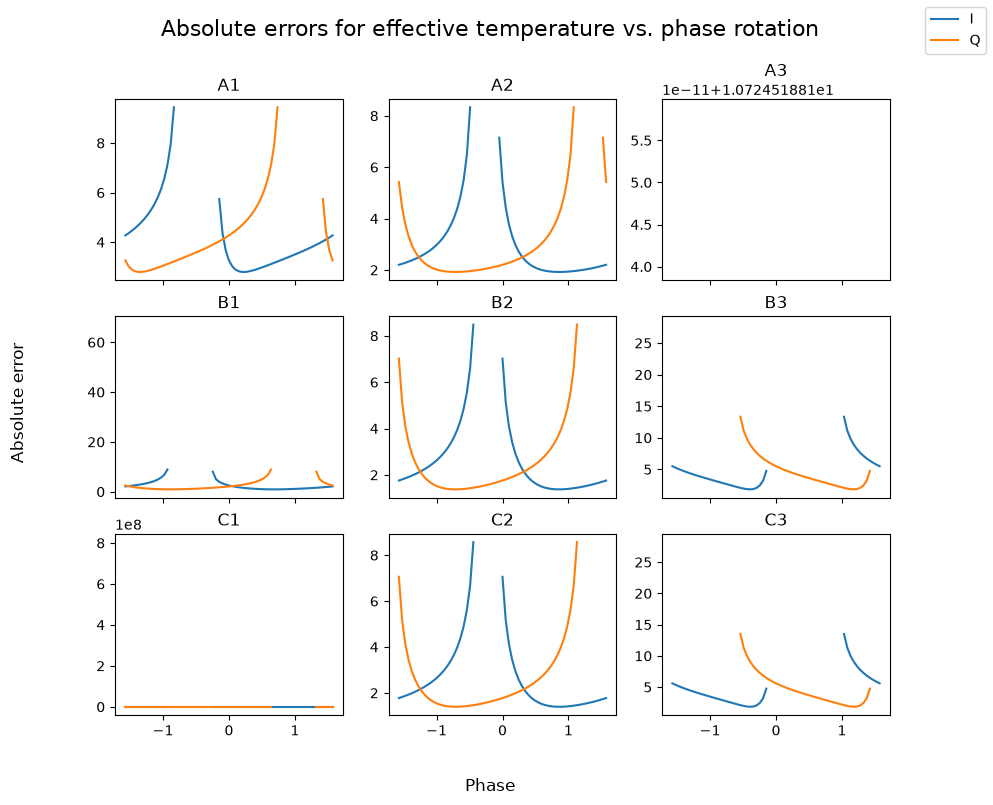

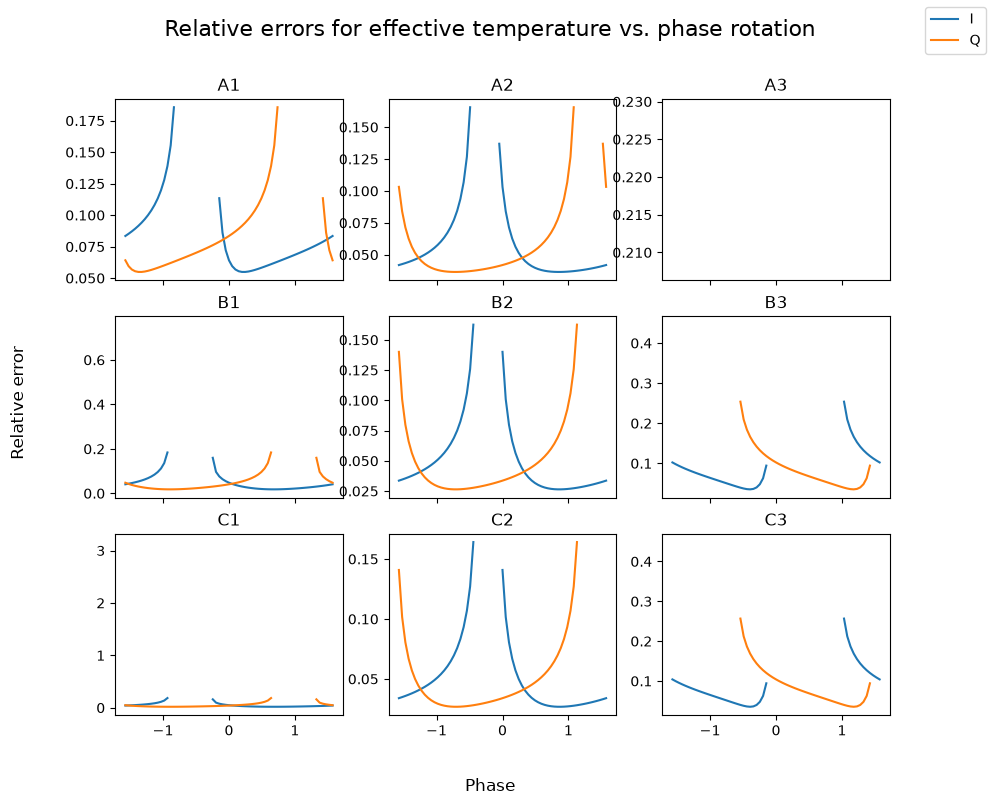

In [539]:
STAT_I, STAT_Q = make_rotation_temperature(pop_data, phase_arr, f_q, anharm,
                                           three_levels=three_levels)

for info_type in ['mean', 'error', 'rel_err']:
    fig, ax = plot_rotation_stat(phase_arr, STAT_I, STAT_Q,
                                 info_type=info_type)
    file_path = get_path_to_file(f'Population_rotation_{info_type}_', '.png')
    fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [540]:
for k in STAT_I:
    print('For', k)
    print('  I: min rel. err:', np.nanmin(STAT_I[k][:, 2]),
          'at phase point', np.nanargmin(STAT_I[k][:, 2]))
    print('  Q: min rel. err:', np.nanmin(STAT_Q[k][:, 2]),
          'at phase point', np.nanargmin(STAT_Q[k][:, 2]))

For TA1
  I: min rel. err: 0.05490074094521235 at phase point 37
  Q: min rel. err: 0.0549007409452114 at phase point 5
For TB1
  I: min rel. err: 0.017902651505327744 at phase point 46
  Q: min rel. err: 0.01790265150532695 at phase point 14
For TC1
  I: min rel. err: 0.018228794156425924 at phase point 46
  Q: min rel. err: 0.01822879415642511 at phase point 14
For TA2
  I: min rel. err: 0.03652084272838618 at phase point 49
  Q: min rel. err: 0.03652084272838294 at phase point 17
For TB2
  I: min rel. err: 0.02642237703645888 at phase point 50
  Q: min rel. err: 0.02642237703645802 at phase point 18
For TC2
  I: min rel. err: 0.026810815303547283 at phase point 50
  Q: min rel. err: 0.026810815303546415 at phase point 18
For TA3
  I: min rel. err: 0.21832941414080864 at phase point 28
  Q: min rel. err: 0.21832941414080845 at phase point 60
For TB3
  I: min rel. err: 0.03511030514926556 at phase point 24
  Q: min rel. err: 0.03511030514927085 at phase point 56
For TC3
  I: min rel. 

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1946881240.py:10: RuntimeWarning: invalid value encountered in log
  return -(h * f_q / k) / np.log(C)
C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\76333001.py:77: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root = fsolve(solve_fn, x0, args=(float(x), f_q_i, anharm_i))


{'axes': 'I',
 'method': 'TB1',
 'ph_p': np.int64(46),
 'phase': np.float64(0.6872233929727672),
 'rel_err': np.float64(0.017902651505327744)}
Mean optimal temperature: 52.14424802233773 mK


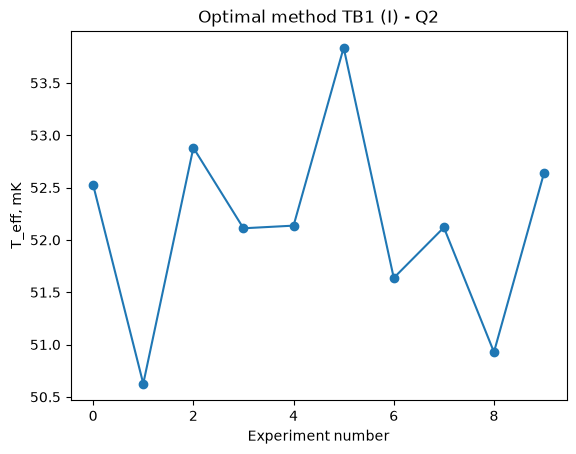

In [541]:
optimal_method = make_optimal_temperature(pop_data, phase_arr, f_q, anharm,
                                          skip=skip_optimization,
                                          three_levels=three_levels)
pprint(optimal_method)

Teff = find_optimal_temperature(pop_data, optimal_method, f_q, anharm,
                                three_levels=three_levels)

fig, ax = plt.subplots()
ax.plot(Teff, 'o-')
ax.set_xlabel('Experiment number')
ax.set_ylabel('T_eff, mK')
ax.set_title(f"Optimal method {optimal_method['method']} "
             f"({optimal_method['axes']}) - {qubit_to_measure.uid}")

print('Mean optimal temperature:', np.nanmean(Teff), 'mK')

file_path = get_path_to_file('Population_optimal_temperature_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1946881240.py:10: RuntimeWarning: invalid value encountered in log
  return -(h * f_q / k) / np.log(C)
C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\76333001.py:77: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root = fsolve(solve_fn, x0, args=(float(x), f_q_i, anharm_i))


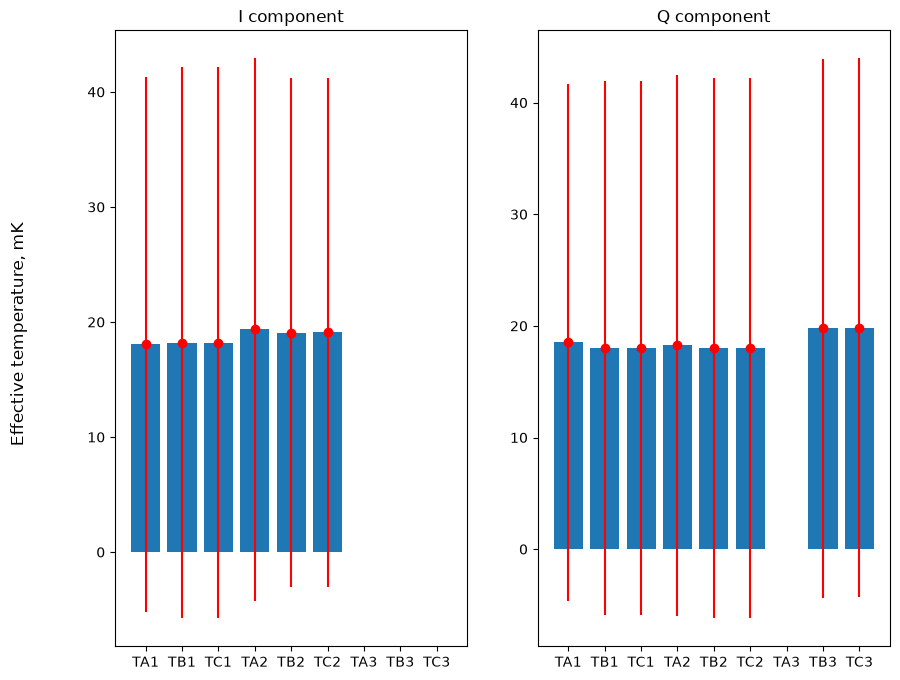

In [542]:
# statistics at a single (zero) phase, for comparison
STAT_I_0, STAT_Q_0 = make_rotation_temperature(pop_data, [0], f_q, anharm,
                                               three_levels=three_levels)

# give plot_stat copies so it cannot modify the original statistis
STAT_I_0_plot = {k: v.copy() for k, v in STAT_I_0.items()}
STAT_Q_0_plot = {k: v.copy() for k, v in STAT_Q_0.items()}

fig, ax = plot_stat(STAT_I_0_plot, STAT_Q_0_plot)

#### Update Parameters

In [543]:
data_t_opt = {
    'phase_arr': phase_arr,
    'optimal_phase': optimal_method['phase'],
    'optimal_method': optimal_method['method'],
    'optimal_axes': optimal_method['axes'],
    'optimal_rel_err': optimal_method['rel_err'],
    'Teff': Teff,
    'f_q': f_q,
    'anharm': anharm,
    'comment': 'Projection-phase optimization of the population statistics',
}
data_t_opt.update({f'STAT_{k}_I': v for k, v in STAT_I.items()})
data_t_opt.update({f'STAT_{k}_Q': v for k, v in STAT_Q.items()})
data_t_opt.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_t_opt['sample_name'] = sample_name
data_t_opt['qubit_name'] = qubit_name
data_t_opt['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Teff_rotation_optimization_', '.mat')
savemat(file_path, data_t_opt)
print(f'Saved rotation optimization to: {file_path}')

Saved rotation optimization to: N:\xld\qubit_thermometry_v2\ES-009-DE_1-2_9150\COOLDOWN_2026-09-02\Q2\20260903_233805_Teff_rotation_optimization_.mat


### Population with Prepulse

#### Experiment Parameters

In [544]:
update_global_parameters = False

n_avg_exponent = 16

qubit_to_measure = qubits[0]

# range of the ge pre-pulse amplitude scan (old amp_min / amp_max / amp_num)
prepulse_amp_min = 0
prepulse_amp_max = qubit_to_measure.parameters.ge_drive_amplitude_pi
n_prepulse_amp = 51
prepulse_amplitudes = np.linspace(prepulse_amp_min, prepulse_amp_max,
                                  n_prepulse_amp)

# old: gaussian_pulse = pulse_library.gaussian(
#          length=qubit_parameters["qb_len"], amplitude=1.0)
# ge_drive_pulse = {
#     'function': 'gaussian',
#     'sigma': 0.25,
# }

temporary_parameters = {}
temp_pars = deepcopy(qubit_to_measure.parameters)
# temp_pars.ge_drive_pulse = ge_drive_pulse
temporary_parameters[qubit_to_measure.uid] = temp_pars

print('ge drive pulse:        ', temp_pars.ge_drive_pulse)
print('ge drive length:       ', temp_pars.ge_drive_length)
print('ge drive amplitude pi: ', temp_pars.ge_drive_amplitude_pi)
print('Number of averages:    ', 2**n_avg_exponent)

ge drive pulse:         {'function': 'drag', 'beta': 0.009337457823820674, 'sigma': 0.25}
ge drive length:        2e-07
ge drive amplitude pi:  0.3352897014347527
Number of averages:     65536


#### Run Workflow

In [545]:
options = population_experiment_workflow.options()
options.count(2**n_avg_exponent)

exp_workflow = population_experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    prepulse_amplitudes=prepulse_amplitudes,
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

[2026.09.03 23:38:30.562] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 23:38:30.562] INFO      Workflow 'population': execution started at 2026-09-03 20:38:30.562802Z       
[2026.09.03 23:38:30.562] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.03 23:38:30.940] INFO    Task 'temporary_qpu': started at 2026-09-03 20:38:30.940878Z
[2026.09.03 23:38:31.062] INFO    Task 'temporary_qpu': ended at 2026-09-03 20:38:31.062424Z
[2026.09.03 23:38:31.212] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-03 
[2026.09.03 23:38:31.212] INFO    20:38:31.212716Z
[2026.09.03 23:38:31.278] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-03 20:38:31.278687Z
[2026.09.03 23:38:31.478] INFO    Task 'create_population_experiment': started at 2026-09-03 20:38:31.478434Z
[2026.09.03 23:38:31.633] INFO    Task 'create_population_experiment': ended at 2026-09-03

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1166748630.py:62: FutureWarning: `QPU.measure_section_length` is deprecated and will be removed in LabOne Q 26.7.0. The functionality has been moved to implementations of `QuantumOperations` for qubit types where this property is meaningful.
  max_measure_section_length = qpu.measure_section_length([qubit])


[2026.09.03 23:38:31.914] INFO    Starting LabOne Q Compiler run...
[2026.09.03 23:38:31.914] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.09.03 23:38:31.919] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.09.03 23:38:31.919] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.09.03 23:38:31.919] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.09.03 23:38:31.928] INFO    Schedule completed. [0.008 s]
[2026.09.03 23:38:31.948] INFO    Code generation completed for all AWGs. [0.016 s]
[2026.09.03 23:38:31.951] INFO    Completed compilation step 1 of 1. [0.027 s]
[2026.09.03 23:38:31.957] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.03 23:38:31.960] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.09.03 23:38:31.962] INFO     ───────────────────

#### Analysis Plots

Text(0.5, 1.0, 'Population with pre-pulse - Q2')

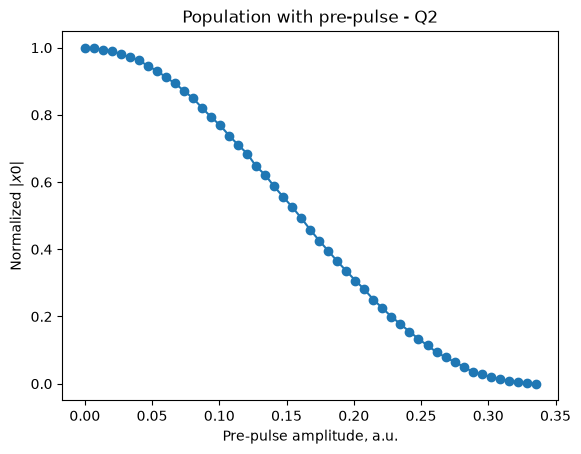

In [546]:
# old: pulse_amp = results_population_prepulse.get_axis("x0_readout")[0]
pulse_amp = prepulse_amplitudes

pop_prepulse_results = collect_population_from_result(
    workflow_result.output, qubit_to_measure.uid
)

# convenience aliases matching the old variable names
x0 = pop_prepulse_results['x0']
x1 = pop_prepulse_results['x1']
x2 = pop_prepulse_results['x2']
y0 = pop_prepulse_results['y0']
y1 = pop_prepulse_results['y1']
y2 = pop_prepulse_results['y2']

fig, ax = plt.subplots()
ax.plot(pulse_amp,
        (abs(x0) - np.min(abs(x0))) / (np.max(abs(x0)) - np.min(abs(x0))),
        'o-')
ax.set_xlabel('Pre-pulse amplitude, a.u.')
ax.set_ylabel('Normalized $|x0|$')
ax.set_title(f'Population with pre-pulse - {qubit_to_measure.uid}')

Residual excited population at zero pre-pulse amplitude: 0.006368474134729185


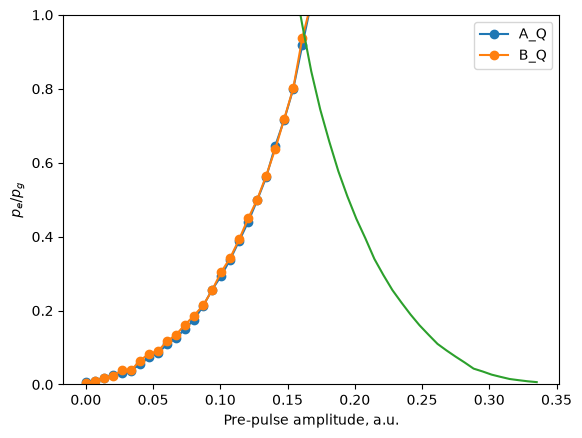

In [547]:
A_real = (x0.real - x1.real) / (y0.real - y1.real)
A_imag = (x0.imag - x1.imag) / (y0.imag - y1.imag)

B_real = (x1.real - y1.real) / (y0.real - x2.real)
B_imag = (x1.imag - y1.imag) / (y0.imag - x2.imag)

C_real = (x0.real - y0.real) / (x1.real - x2.real)
C_imag = (x0.imag - y0.imag) / (x1.imag - x2.imag)

pe0 = 1 - A_real[0]
print('Residual excited population at zero pre-pulse amplitude:', pe0)

fig, ax = plt.subplots()
# ax.plot(pulse_amp, C_real, '-o', label='C_Q')
# ax.plot(pulse_amp, C_imag, '-o', label='C_I')
ax.plot(pulse_amp, 1 - A_real, '-o', label='A_Q')
# ax.plot(pulse_amp, 1 - A_imag, '-o', label='A_I')
ax.plot(pulse_amp, B_real / (B_real + 1), '-o', label='B_Q')
# ax.plot(pulse_amp, B_imag / (B_imag + 1), '-o', label='B_I')

pe = (abs(x0) - np.min(abs(x0))) / (np.max(abs(x0)) - np.min(abs(x0)))
pe_sh = (1 - 2 * pe0) * pe + pe0
ax.plot(pulse_amp, pe_sh / (1 - pe_sh), '-')

ax.set_xlabel('Pre-pulse amplitude, a.u.')
ax.set_ylabel('$p_e/p_g$')
ax.set_ylim(0.0, 1.0)
ax.legend()

file_path = get_path_to_file('Population_prepulse_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [548]:
data_pop_prep = {f'pop_{label}': pop_prepulse_results[label]
                 for label in pop_label_list}
data_pop_prep.update({
    'prepulse_amplitude_sweep': pulse_amp,
    'pe0': pe0,
    'n_shots': 2**n_avg_exponent,
    'comment': ('Three level population vs. ge pre-pulse amplitude, array dim '
                '[prepulse_amplitude]'),
})
data_pop_prep.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_pop_prep['sample_name'] = sample_name
data_pop_prep['qubit_name'] = qubit_name
data_pop_prep['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Population_prep_', '.mat')
savemat(file_path, data_pop_prep)
print(f'Saved population with pre-pulse to: {file_path}')

Saved population with pre-pulse to: N:\xld\qubit_thermometry_v2\ES-009-DE_1-2_9150\COOLDOWN_2026-09-02\Q2\20260904_011943_Population_prep_.mat


## Population Measurements for Different Readout Frequencies

The three-level protocol repeated for a range of readout resonator
frequencies. Every frequency needs its own compilation, so this is slow.

#### Experiment Parameters

In [549]:
update_global_parameters = False

n_avg_exponent = 16

# frequency range around the current readout resonator frequency
freq_range = 5e6
n_points = 51

qubit_to_measure = qubits[0]

# old: ro_freq_arr = np.linspace(qubit_parameters["ro_freq"] - spec_range / 2,
#                                qubit_parameters["ro_freq"] + spec_range / 2,
#                                spec_num)
readout_resonator_frequency_arr = (
    qubit_to_measure.parameters.readout_resonator_frequency
    + np.linspace(-freq_range / 2, freq_range / 2, n_points)
)

# old readout_i dict: readout_range / readout_delay / relax_time
# readout_range_out = -25
readout_integration_delay = qubit_to_measure.parameters.readout_integration_delay

print('Readout resonator frequencies: ',
      readout_resonator_frequency_arr[0] * 1e-9, '...',
      readout_resonator_frequency_arr[-1] * 1e-9, 'GHz')
print('Number of averages:            ', 2**n_avg_exponent)

Readout resonator frequencies:  5.957192 ... 5.962192 GHz
Number of averages:             65536


#### Run Workflow

In [550]:
options = population_experiment_workflow.options()
options.count(2**n_avg_exponent)

pop_i_results = {}

for readout_resonator_frequency in readout_resonator_frequency_arr:
    print('Readout resonator frequency:',
          round(readout_resonator_frequency * 1e-9, 6), 'GHz')

    temporary_parameters = {}
    temp_pars = deepcopy(qubit_to_measure.parameters)
    temp_pars.readout_resonator_frequency = float(readout_resonator_frequency)
    temp_pars.readout_range_out = readout_range_out
    temp_pars.readout_integration_delay = readout_integration_delay
    temporary_parameters[qubit_to_measure.uid] = temp_pars

    exp_workflow = population_experiment_workflow(
        session=session,
        qpu=qpu,
        qubit=qubit_to_measure.uid,
        options=options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result = exp_workflow.run()

    pop_result = collect_population_from_result(
        workflow_result.output, qubit_to_measure.uid
    )
    for label in pop_label_list:
        pop_i_results.setdefault(label, []).append(pop_result[label])

for label in pop_label_list:
    pop_i_results[label] = np.array(pop_i_results[label])

print('Population array shape (frequencies,):', pop_i_results['x0'].shape)

Readout resonator frequency: 5.957192 GHz
[2026.09.04 01:19:43.734] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.04 01:19:43.734] INFO      Workflow 'population': execution started at 2026-09-03 22:19:43.734843Z       
[2026.09.04 01:19:43.734] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.04 01:19:43.973] INFO    Task 'temporary_qpu': started at 2026-09-03 22:19:43.973757Z
[2026.09.04 01:19:44.035] INFO    Task 'temporary_qpu': ended at 2026-09-03 22:19:44.035980Z
[2026.09.04 01:19:44.164] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-09-03 
[2026.09.04 01:19:44.164] INFO    22:19:44.164382Z
[2026.09.04 01:19:44.246] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-09-03 22:19:44.246056Z
[2026.09.04 01:19:44.310] INFO    Task 'create_population_experiment': started at 2026-09-03 22:19:44.310594Z
[2026.09.04 01:19:44.504] INFO    Task 'create_p

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1166748630.py:62: FutureWarning: `QPU.measure_section_length` is deprecated and will be removed in LabOne Q 26.7.0. The functionality has been moved to implementations of `QuantumOperations` for qubit types where this property is meaningful.
  max_measure_section_length = qpu.measure_section_length([qubit])


[2026.09.04 01:19:44.712] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.09.04 01:19:44.712] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.09.04 01:19:44.712] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.09.04 01:19:44.712] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.09.04 01:19:44.717] INFO    Schedule completed. [0.000 s]
[2026.09.04 01:19:44.718] INFO    Code generation completed for all AWGs. [0.004 s]
[2026.09.04 01:19:44.718] INFO    Completed compilation step 1 of 1. [0.008 s]
[2026.09.04 01:19:44.728] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.04 01:19:44.728] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.09.04 01:19:44.728] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.04 01

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1166748630.py:62: FutureWarning: `QPU.measure_section_length` is deprecated and will be removed in LabOne Q 26.7.0. The functionality has been moved to implementations of `QuantumOperations` for qubit types where this property is meaningful.
  max_measure_section_length = qpu.measure_section_length([qubit])


[2026.09.04 01:21:50.455] INFO    Task 'compile_experiment': started at 2026-09-03 22:21:50.455189Z
[2026.09.04 01:21:50.559] INFO    Starting LabOne Q Compiler run...
[2026.09.04 01:21:50.559] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.09.04 01:21:50.559] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.09.04 01:21:50.559] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.09.04 01:21:50.559] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.09.04 01:21:50.559] INFO    Schedule completed. [0.001 s]
[2026.09.04 01:21:50.569] INFO    Code generation completed for all AWGs. [0.004 s]
[2026.09.04 01:21:50.575] INFO    Completed compilation step 1 of 1. [0.009 s]
[2026.09.04 01:21:50.579] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.04 01:21:50.584] INFO      Device              AWG   

...

[2026.09.04 03:00:01.394] INFO      TOTAL                           55            3                  9152  
[2026.09.04 03:00:01.394] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.04 03:00:01.402] INFO    Finished LabOne Q Compiler run.
[2026.09.04 03:00:01.406] INFO    Task 'compile_experiment': ended at 2026-09-04 00:00:01.402548Z
[2026.09.04 03:00:01.481] INFO    Task 'run_experiment': started at 2026-09-04 00:00:01.481097Z
[2026.09.04 03:00:01.634] INFO    Starting near-time execution...
[2026.09.04 03:00:01.737] INFO    Estimated RT execution time: 118.83 s.
[2026.09.04 03:02:00.633] INFO    Finished near-time execution.
[2026.09.04 03:02:05.654] INFO    Task 'run_experiment': ended at 2026-09-04 00:02:05.654745Z
[2026.09.04 03:02:05.751] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.09.04 03:02:05.751] INFO      Workflow 'population': execution ended at 2026-09-04 00:02:05.736626Z       

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1166748630.py:62: FutureWarning: `QPU.measure_section_length` is deprecated and will be removed in LabOne Q 26.7.0. The functionality has been moved to implementations of `QuantumOperations` for qubit types where this property is meaningful.
  max_measure_section_length = qpu.measure_section_length([qubit])


[2026.09.04 03:02:06.701] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.04 03:02:06.702] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.09.04 03:02:06.704] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.04 03:02:06.704] INFO      SHFQC_DEV12192        0         23            0           1      7936  
[2026.09.04 03:02:06.705] INFO      SHFQC_DEV12192_sg     0         32            3           2      1216  
[2026.09.04 03:02:06.705] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.04 03:02:06.705] INFO      TOTAL                           55            3                  9152  
[2026.09.04 03:02:06.707] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.04 03:02:06.717] INFO    Finished LabOne Q Compiler run.
[2026.09.04 03:02:06.718] INFO    Task 'compile_experiment': ended at 

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1166748630.py:62: FutureWarning: `QPU.measure_section_length` is deprecated and will be removed in LabOne Q 26.7.0. The functionality has been moved to implementations of `QuantumOperations` for qubit types where this property is meaningful.
  max_measure_section_length = qpu.measure_section_length([qubit])


[2026.09.04 03:04:12.067] INFO    Starting LabOne Q Compiler run...
[2026.09.04 03:04:12.067] INFO    Resolved modulation type of oscillator on signal: 'q0/acquire' to Software
[2026.09.04 03:04:12.067] INFO    Resolved modulation type of oscillator on signal: 'q0/drive' to Hardware
[2026.09.04 03:04:12.082] INFO    Resolved modulation type of oscillator on signal: 'q0/drive_ef' to Hardware
[2026.09.04 03:04:12.083] INFO    Resolved modulation type of oscillator on signal: 'q0/measure' to Software
[2026.09.04 03:04:12.084] INFO    Schedule completed. [0.000 s]
[2026.09.04 03:04:12.084] INFO    Code generation completed for all AWGs. [0.006 s]
[2026.09.04 03:04:12.084] INFO    Completed compilation step 1 of 1. [0.010 s]
[2026.09.04 03:04:12.099] INFO     ─────────────────────────────────────────────────────────────────────── 
[2026.09.04 03:04:12.099] INFO      Device              AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.09.04 03:04:12.099] INFO     ───────────────────

#### Analysis Plots

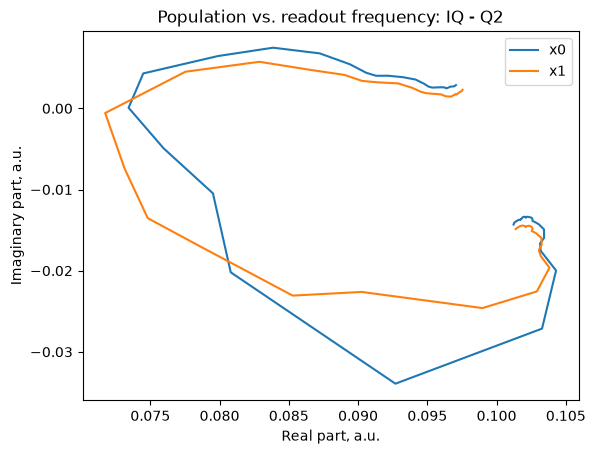

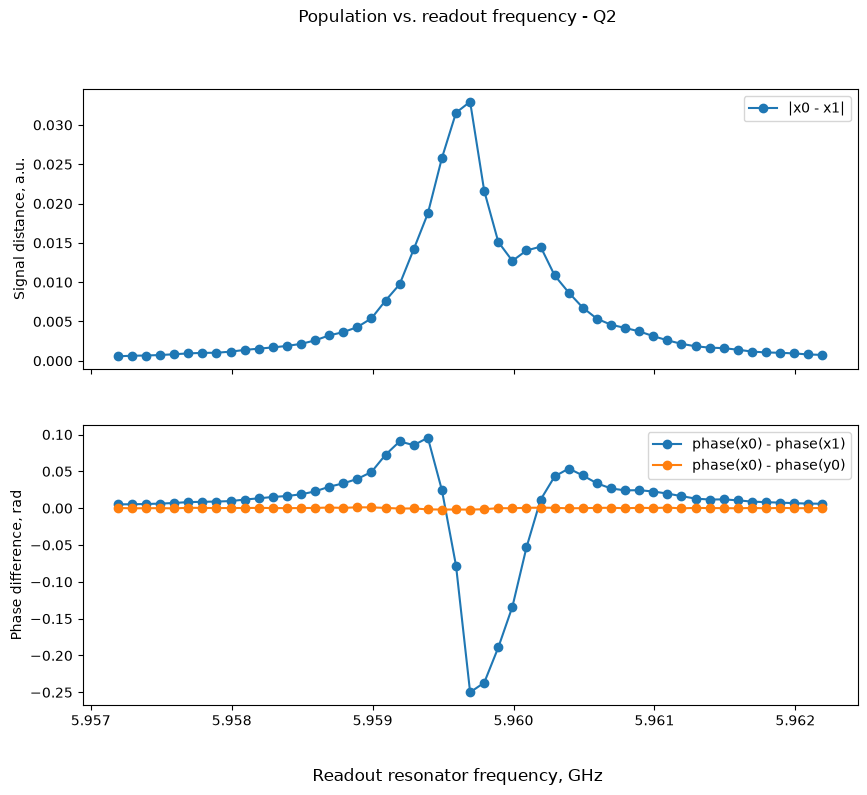

In [551]:
fig, ax = plt.subplots()
ax.set_title(f'Population vs. readout frequency: IQ - {qubit_to_measure.uid}')
ax.plot(pop_i_results['x0'].real, pop_i_results['x0'].imag, label='x0')
ax.plot(pop_i_results['x1'].real, pop_i_results['x1'].imag, label='x1')
ax.set_xlabel('Real part, a.u.')
ax.set_ylabel('Imaginary part, a.u.')
ax.legend()

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
fig.suptitle(f'Population vs. readout frequency - {qubit_to_measure.uid}')
fig.supxlabel('Readout resonator frequency, GHz')

ax[0].plot(readout_resonator_frequency_arr * 1e-9,
           np.abs(pop_i_results['x0'] - pop_i_results['x1']), 'o-',
           label='|x0 - x1|')
ax[0].set_ylabel('Signal distance, a.u.')
ax[0].legend()

ax[1].plot(readout_resonator_frequency_arr * 1e-9,
           np.unwrap(np.angle(pop_i_results['x0']))
           - np.unwrap(np.angle(pop_i_results['x1'])), 'o-',
           label='phase(x0) - phase(x1)')
ax[1].plot(readout_resonator_frequency_arr * 1e-9,
           np.unwrap(np.angle(pop_i_results['x0']))
           - np.unwrap(np.angle(pop_i_results['y0'])), 'o-',
           label='phase(x0) - phase(y0)')
ax[1].set_ylabel('Phase difference, rad')
ax[1].legend()

file_path = get_path_to_file('Population_vs_ro_freq_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\1946881240.py:10: RuntimeWarning: invalid value encountered in log
  return -(h * f_q / k) / np.log(C)
C:\Users\phys-pico-lab\AppData\Local\Temp\ipykernel_11480\76333001.py:77: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root = fsolve(solve_fn, x0, args=(float(x), f_q_i, anharm_i))


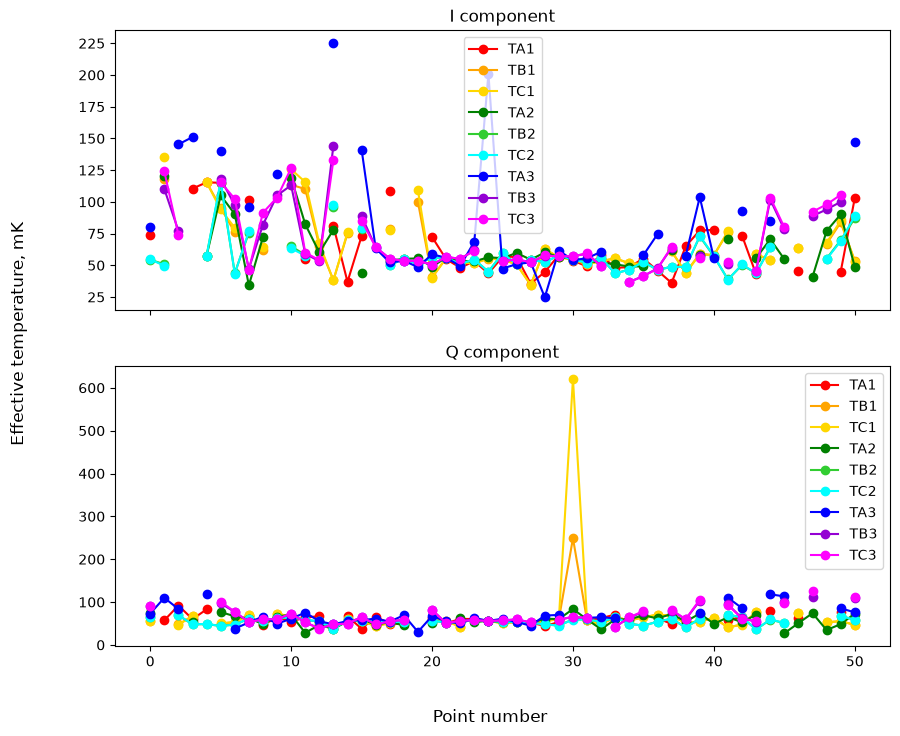

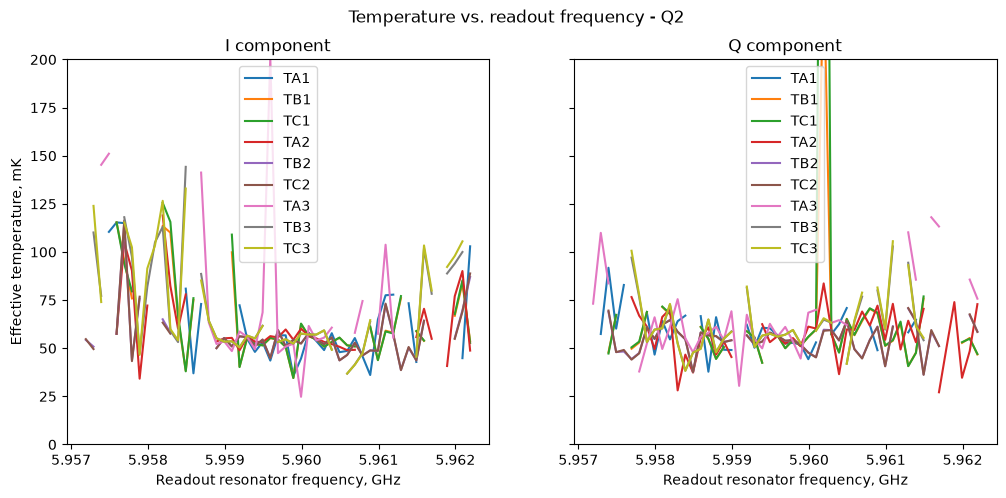

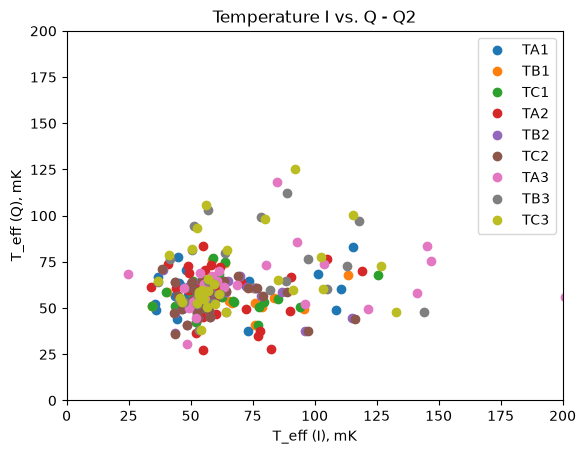

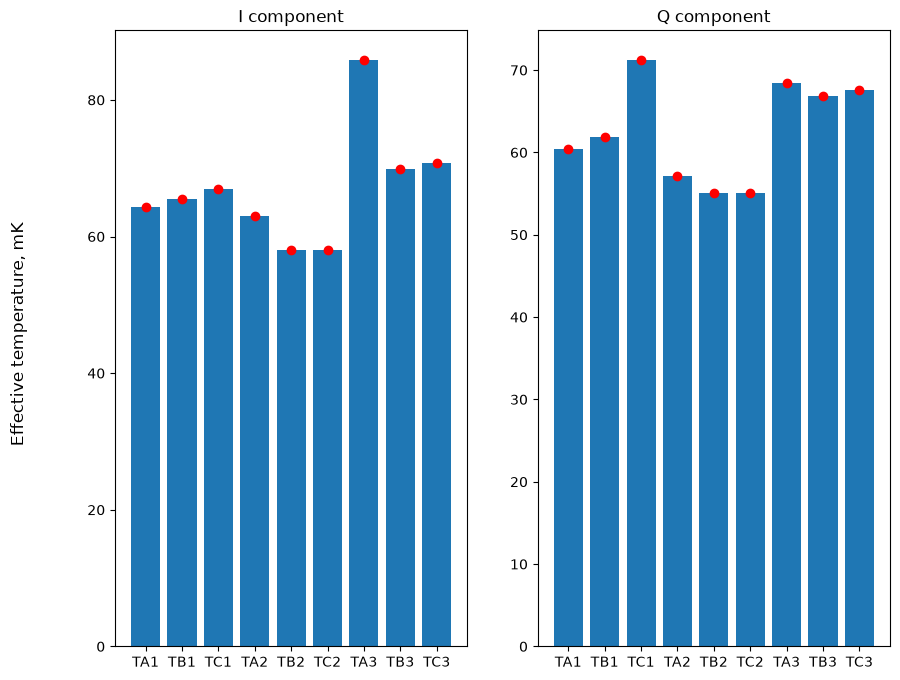

In [552]:
# fast temperature extraction per readout frequency
skip = [] #['TC3']

TABC_I, TABC_Q = make_all_temperatures(pop_i_results, f_q, anharm,
                                       three_levels=three_levels)

fig, ax = plot_temperatures(TABC_I, TABC_Q, skip=skip)

fig_i, ax_i = plt.subplots(1, 2, sharey=True, figsize=(12, 5))
fig_i.suptitle(f'Temperature vs. readout frequency - {qubit_to_measure.uid}')
for k in TABC_I:
    ax_i[0].plot(readout_resonator_frequency_arr * 1e-9, TABC_I[k], label=k)
    ax_i[1].plot(readout_resonator_frequency_arr * 1e-9, TABC_Q[k], label=k)
ax_i[0].set_title('I component')
ax_i[1].set_title('Q component')
for axis in ax_i:
    axis.set_xlabel('Readout resonator frequency, GHz')
    axis.set_ylim(0, 200)
    axis.legend()
ax_i[0].set_ylabel('Effective temperature, mK')

fig_iq, ax_iq = plt.subplots()
ax_iq.set_title(f'Temperature I vs. Q - {qubit_to_measure.uid}')
for k in TABC_I:
    ax_iq.plot(TABC_I[k], TABC_Q[k], 'o', label=k)
ax_iq.set_xlim(0, 200)
ax_iq.set_ylim(0, 200)
ax_iq.set_xlabel('T_eff (I), mK')
ax_iq.set_ylabel('T_eff (Q), mK')
ax_iq.legend()

STAT_I = get_stat_nan(TABC_I)
STAT_Q = get_stat_nan(TABC_Q)
fig_stat, ax_stat = plot_stat(STAT_I, STAT_Q)

file_path = get_path_to_file('Population_vs_ro_freq_temperature_', '.png')
fig_i.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [553]:
data_pop_ro_freq = {f'pop_{label}': pop_i_results[label]
                    for label in pop_label_list}
data_pop_ro_freq.update({f'{k}_I': v for k, v in TABC_I.items()})
data_pop_ro_freq.update({f'{k}_Q': v for k, v in TABC_Q.items()})
data_pop_ro_freq.update({
    'readout_resonator_frequency_sweep': readout_resonator_frequency_arr,
    'readout_range_out': readout_range_out,
    'readout_integration_delay': readout_integration_delay,
    'n_shots': 2**n_avg_exponent,
    'f_q': f_q,
    'anharm': anharm,
    'comment': ('Three level population vs. readout resonator frequency, array '
                'dim [readout_resonator_frequency]; temperatures in mK'),
})
data_pop_ro_freq.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_pop_ro_freq['sample_name'] = sample_name
data_pop_ro_freq['qubit_name'] = qubit_name
data_pop_ro_freq['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Population_vs_ro_freq_', '.mat')
savemat(file_path, data_pop_ro_freq)
print(f'Saved population vs. readout frequency to: {file_path}')

Saved population vs. readout frequency to: N:\xld\qubit_thermometry_v2\ES-009-DE_1-2_9150\COOLDOWN_2026-09-02\Q2\20260904_030621_Population_vs_ro_freq_.mat


In [554]:
# set to a value != None to move the readout to the frequency with the lowest
# temperature spread (old notebook did this by hand).
manual_readout_resonator_frequency = None

# spread of the estimators at every readout frequency, as a figure of merit
temperature_matrix = np.array(
    [TABC_I[k] for k in TABC_I if k not in skip], dtype=float
)
rel_err_vs_freq = np.abs(
    np.nanstd(temperature_matrix, axis=0) / np.nanmean(temperature_matrix, axis=0)
)
optimal_index = int(np.nanargmin(rel_err_vs_freq))
readout_resonator_frequency_opt = float(
    readout_resonator_frequency_arr[optimal_index]
)
if manual_readout_resonator_frequency is not None:
    readout_resonator_frequency_opt = float(manual_readout_resonator_frequency)

print('Optimal readout resonator frequency:',
      round(readout_resonator_frequency_opt * 1e-9, 6), 'GHz',
      '(index', optimal_index, ')')

if update_global_parameters:
    temp_pars = deepcopy(qubit_to_measure.parameters)
    temp_pars.readout_resonator_frequency = readout_resonator_frequency_opt
    qubit_to_measure.parameters = temp_pars
    save(qpu, qpu_file_path)
    print('Updated global experiment parameters!\n')

print('Readout resonator frequency: ',
      qubit_to_measure.parameters.readout_resonator_frequency * 1e-9, ' GHz')

Optimal readout resonator frequency: 5.958792 GHz (index 16 )
Readout resonator frequency:  5.959692  GHz


In [555]:
qpu.quantum_elements

[TunableTransmonQubit(
│   uid='Q2',
│   signals={
│   │   'drive': 'q0/drive',
│   │   'drive_ef': 'q0/drive_ef',
│   │   'measure': 'q0/measure',
│   │   'acquire': 'q0/acquire'
│   },
│   parameters=TunableTransmonQubitParameters(
│   │   custom={},
│   │   ge_T1=1.0433416889865267e-05,
│   │   ge_T2=1.659788521169252e-05,
│   │   ge_T2_star=7.741290835250325e-06,
│   │   ef_T1=5.161184727745047e-06,
│   │   ef_T2=1.957837104913142e-06,
│   │   ef_T2_star=5.594394899111066e-06,
│   │   drive_lo_frequency=4800000000.0,
│   │   readout_lo_frequency=6000000000.0,
│   │   resonance_frequency_ge=5008681684.374855,
│   │   resonance_frequency_ef=4788764299.046252,
│   │   readout_resonator_frequency=np.float64(5959692000.0),
│   │   ge_drive_amplitude_pi=0.3352897014347527,
│   │   ge_drive_amplitude_pi2=0.16594439910907385,
│   │   ge_drive_length=2e-07,
│   │   ge_drive_pulse={
│   │   │   'function': 'drag',
│   │   │   'beta': 0.009337457823820674,
│   │   │   'sigma': 0.25
│   │   },

# Fast Flux Drive <a class="anchor" id="fast-flux-drive"></a>

## Helpers

#### Fit Helpers

In [ ]:
def func_exp(x, rate, off, amp=1):
    """Old `lib.helpers.fitting_helper.func_exp`, unchanged."""
    return amp * np.exp(-rate * x) + off


def func_lin(x, a, b):
    """Old `lib.helpers.fitting_helper.func_lin`, unchanged."""
    return a * x + b


def fit_linear(x, y, plot=False):
    """Old `lib.helpers.fitting_helper.fit_linear`, unchanged."""
    popt, pcov = curve_fit(func_lin, x, y)
    if plot:
        plt.plot(x, y, '.k')
        plt.plot(x, func_lin(x, *popt), '-r')
        plt.show()
    return popt, pcov


def fit_T1(x, y, rate, off, amp=None, plot=False, bounds=None):
    """Old `lib.helpers.fitting_helper.fit_T1`, unchanged."""
    p0 = [rate, off] if amp is None else [rate, off, amp]
    kwargs = {} if bounds is None else {'bounds': bounds}
    popt, pcov = curve_fit(func_exp, x, y, p0=p0, **kwargs)
    if plot:
        plt.plot(x, y, '.k')
        plt.plot(x, func_exp(x, *popt), '-r')
        plt.ylabel('Signal, a.u.')
        plt.xlabel('Delay, s')
    return popt, pcov


def find_rotation(data, plot=False):
    """Old `lib.helpers.fitting_helper.find_rotation`, unchanged."""
    popt, pcov = fit_linear(np.real(data), np.imag(data), plot=plot)
    return np.arctan(popt[0])


def rotate_and_norm(data, norm=False):
    """Old `lib.helpers.fitting_helper.rotate_and_norm`, unchanged."""
    angle = find_rotation(data, plot=False)
    data_rot = data * np.exp(-1j * angle)
    if norm:
        x = np.real(data_rot)
        return (x - np.min(x)) / (np.max(x) - np.min(x))
    return data_rot


def reshape_to_1D(x):
    """Old `lib.helpers.fitting_helper.reshape_to_1D`, unchanged."""
    x_sh = x.shape
    if len(x_sh) != 1:
        x = np.reshape(x, (np.max(x_sh),))
    return x


def transform_complex_to_real(data, data_type='real'):
    """Old `lib.helpers.fitting_helper.transform_complex_to_real`, unchanged."""
    data_sh = data.shape
    if len(data_sh) == 1:
        data = np.reshape(data, (1, data_sh[0]))

    if data_type in ('amp', 'amplitude'):
        return np.abs(data)
    if data_type == 'phase':
        return np.unwrap(np.angle(data))
    if data_type == 'real':
        return np.real(data)
    if data_type == 'imag':
        return np.imag(data)
    if data_type in ('rot', 'rotation'):
        data_trans = np.zeros_like(data.real)
        for i in range(data.shape[0]):
            data_trans[i, :] = np.real(rotate_and_norm(data[i, :], norm=False))
        return data_trans

    print('Unsupported data type! Type changed to real!')
    return np.real(data)


def auto_T1_fit(t1_delay, t1_data, data_type='real', plot=False):
    """Old `lib.helpers.fitting_helper.auto_T1_fit`, unchanged."""
    t1_delay = reshape_to_1D(t1_delay)
    data = transform_complex_to_real(t1_data, data_type=data_type)

    popt = np.array([2e6, np.mean(data[0, :]), abs(np.max(data[0, :]) - np.min(data[0, :]))])
    sign = -1 if np.argmax(data[0, :]) > np.argmin(data[0, :]) else 1

    popt_t1_list, pcov_t1_list = [], []
    for i in range(data.shape[0]):
        try:
            popt, pcov = fit_T1(t1_delay, data[i, :], rate=popt[0], off=popt[1],
                                amp=sign * popt[2], plot=plot)
        except RuntimeError:
            print('T1 Fit did not converge!')
            popt = np.full((3,), np.nan)
            pcov = np.full((3, 3), np.nan)
        popt_t1_list.append(popt)
        pcov_t1_list.append(pcov)

    return np.array(popt_t1_list), np.array(pcov_t1_list)

#### Plotting Helpers

In [ ]:
def plot_2d(x, y, z, flip=False, cmap='viridis', ax=None):
    """New-structure replacement for the old `lib.utils.calculator.plot_2d`."""
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    data = np.asarray(z).T
    if flip:
        data = np.flipud(data)

    mesh = ax.pcolormesh(x, y, data, cmap=cmap, shading='auto')
    fig.colorbar(mesh, ax=ax)
    return fig, ax

## Custom Experiment Workflows

#### Flux Amplitude Calibration Experiment

In [ ]:
@workflow.task
@dsl.qubit_experiment
def create_flux_amplitude_calibration_experiment(
    qpu,
    qubit,
    flux_amplitudes,
    flux_pulse,
    flux_detuning=0.0,
    flux_oscillator_frequency=0.0,
    delay_time=1e-7,
    options: BaseExperimentOptions | None = None,
):
    """Create the flux/th_res amplitude-calibration experiment.

    Sweeps the flux-pulse amplitude; an x180 pulse is played right-aligned
    together with the flux pulse, followed by `delay_time` before readout
    (old `exp_tr_amp.delay(signal="drive", time=delay_time)`).

    Arguments:
        qpu: The QPU consisting of the qubits and quantum operations.
        qubit: The qubit to run the experiment on.
        flux_amplitudes: The flux-pulse amplitudes to sweep over
            (old `res_amp_sweep`).
        flux_pulse: The flux pulse to play (old `gaussian_pulse` /
            `flux_pulse`, a `pulse_library.gaussian_square(...)` object).
        flux_detuning: Detuning of the qubit drive relative to
            `resonance_frequency_ge`, applied with `qop.set_frequency`
            (old `detune_ss` / the `"drive"` entry of `make_th_res_calib`).
        flux_oscillator_frequency: Baseline oscillator frequency of the flux
            line (old `qubit_parameters["th_res_freq"]`).
        delay_time: Delay between the x180 pulse and readout.
        options: `BaseExperimentOptions`.
    """
    opts = BaseExperimentOptions() if options is None else options
    qubit, flux_amplitudes = validation.validate_and_convert_single_qubit_sweeps(
        qubit, flux_amplitudes
    )

    qop = qpu.quantum_operations
    max_measure_section_length = qpu.measure_section_length([qubit])

    calibration = dsl.experiment_calibration()
    calibration[qubit.signals['flux']].oscillator = Oscillator(
        frequency=flux_oscillator_frequency
    )
    if flux_detuning:
        qop.set_frequency(
            qubit, qubit.parameters.resonance_frequency_ge + flux_detuning,
            transition='ge',
        )

    with dsl.acquire_loop_rt(
        count=opts.count,
        averaging_mode=opts.averaging_mode,
        acquisition_type=opts.acquisition_type,
        repetition_mode=opts.repetition_mode,
        repetition_time=opts.repetition_time,
        reset_oscillator_phase=opts.reset_oscillator_phase,
    ):
        with dsl.sweep(
            name=f'flux_amplitude_sweep_{qubit.uid}',
            parameter=SweepParameter(f'flux_amplitude_{qubit.uid}', flux_amplitudes),
        ) as flux_amplitude:
            with dsl.section(name='main', alignment=SectionAlignment.RIGHT):
                with dsl.section(name='flux_and_drive', alignment=SectionAlignment.RIGHT):
                    dsl.play(qubit.signals['flux'], pulse=flux_pulse, amplitude=flux_amplitude)
                    sec = qop.x180(qubit)
                    sec.alignment = SectionAlignment.RIGHT
                    qop.delay(qubit, delay_time)
                with dsl.section(name='measure', alignment=SectionAlignment.LEFT):
                    sec = qop.measure(
                        qubit, dsl.handles.result_handle(qubit.uid, suffix='flux_amp')
                    )
                    sec.length = max_measure_section_length
                    qop.passive_reset(qubit)


@workflow.workflow(name='flux_amplitude_calibration')
def flux_amplitude_calibration_experiment_workflow(
    session,
    qpu,
    qubit,
    flux_amplitudes,
    flux_pulse,
    flux_detuning=0.0,
    flux_oscillator_frequency=0.0,
    delay_time=1e-7,
    temporary_parameters=None,
    options: PopulationWorkflowOptions | None = None,
):
    """The flux/th_res amplitude-calibration workflow (old `make_th_res_amp`)."""
    temp_qpu = temporary_qpu(qpu, temporary_parameters)
    qubit = temporary_quantum_elements_from_qpu(temp_qpu, qubit)
    exp = create_flux_amplitude_calibration_experiment(
        temp_qpu,
        qubit,
        flux_amplitudes=flux_amplitudes,
        flux_pulse=flux_pulse,
        flux_detuning=flux_detuning,
        flux_oscillator_frequency=flux_oscillator_frequency,
        delay_time=delay_time,
    )
    compiled_exp = compile_experiment(session, exp)
    result = run_experiment(session, compiled_exp)
    workflow.return_(result)

#### Fast Flux Decay Experiment

In [ ]:
@workflow.task
@dsl.qubit_experiment
def create_fast_flux_decay_experiment(
    qpu,
    qubit,
    delays,
    flux_pulse,
    flux_amplitude=1.0,
    flux_oscillator_frequency=0.0,
    options: BaseExperimentOptions | None = None,
):
    """Create the T1-decay-under-flux-detuning experiment.

    Plays an x180 pulse, then a flux pulse whose *length* is the swept T1
    delay, then reads out -- i.e. T1 is measured while the qubit sits
    detuned by the flux/th_res drive (old `make_fast_flux_decay`).

    Arguments:
        qpu: The QPU consisting of the qubits and quantum operations.
        qubit: The qubit to run the experiment on.
        delays: The flux-pulse (T1 delay) lengths to sweep over
            (old `t1_sweep` / `t1_ff_sweep`).
        flux_pulse: The flux pulse to play, whose length is overridden by
            `delays` (old `flux_pulse`, a `pulse_library.const(...)` or
            `pulse_library.gaussian_square(..., can_compress=True)` object).
        flux_amplitude: Amplitude of the flux pulse.
        flux_oscillator_frequency: Baseline oscillator frequency of the flux
            line (old `qubit_parameters["th_res_freq"]`).
        options: `BaseExperimentOptions`.
    """
    opts = BaseExperimentOptions() if options is None else options
    qubit, delays = validation.validate_and_convert_single_qubit_sweeps(qubit, delays)

    qop = qpu.quantum_operations
    max_measure_section_length = qpu.measure_section_length([qubit])

    calibration = dsl.experiment_calibration()
    calibration[qubit.signals['flux']].oscillator = Oscillator(
        frequency=flux_oscillator_frequency
    )

    with dsl.acquire_loop_rt(
        count=opts.count,
        averaging_mode=opts.averaging_mode,
        acquisition_type=opts.acquisition_type,
        repetition_mode=opts.repetition_mode,
        repetition_time=opts.repetition_time,
        reset_oscillator_phase=opts.reset_oscillator_phase,
    ):
        with dsl.sweep(
            name=f'flux_decay_sweep_{qubit.uid}',
            parameter=SweepParameter(f'flux_decay_delay_{qubit.uid}', delays),
        ) as delay:
            with dsl.section(name='main', alignment=SectionAlignment.RIGHT):
                with dsl.section(name='drive', alignment=SectionAlignment.RIGHT):
                    sec = qop.x180(qubit)
                    sec.alignment = SectionAlignment.RIGHT
                with dsl.section(name='flux', alignment=SectionAlignment.RIGHT):
                    dsl.play(qubit.signals['flux'], pulse=flux_pulse,
                            amplitude=flux_amplitude, length=delay)
                with dsl.section(name='measure', alignment=SectionAlignment.LEFT):
                    sec = qop.measure(
                        qubit, dsl.handles.result_handle(qubit.uid, suffix='ff_decay')
                    )
                    sec.length = max_measure_section_length
                    qop.passive_reset(qubit)


@workflow.workflow(name='fast_flux_decay')
def fast_flux_decay_experiment_workflow(
    session,
    qpu,
    qubit,
    delays,
    flux_pulse,
    flux_amplitude=1.0,
    flux_oscillator_frequency=0.0,
    temporary_parameters=None,
    options: PopulationWorkflowOptions | None = None,
):
    """The T1-decay-under-flux-detuning workflow (old `make_fast_flux_decay`)."""
    temp_qpu = temporary_qpu(qpu, temporary_parameters)
    qubit = temporary_quantum_elements_from_qpu(temp_qpu, qubit)
    exp = create_fast_flux_decay_experiment(
        temp_qpu,
        qubit,
        delays=delays,
        flux_pulse=flux_pulse,
        flux_amplitude=flux_amplitude,
        flux_oscillator_frequency=flux_oscillator_frequency,
    )
    compiled_exp = compile_experiment(session, exp)
    result = run_experiment(session, compiled_exp)
    workflow.return_(result)

#### Population with Flux Drive Experiment

In [ ]:
@workflow.task
@dsl.qubit_experiment
def create_population_flux_experiment(
    qpu,
    qubit,
    flux_pulse,
    flux_amplitude=1.0,
    flux_oscillator_frequency=0.0,
    options: BaseExperimentOptions | None = None,
):
    """Create the three-level population experiment with a continuous flux drive.

    Arguments:
        qpu: The QPU consisting of the qubits and quantum operations.
        qubit: The qubit to run the experiment on.
        flux_pulse: The flux pulse played between/around every sequence
            (old `flux_pulse`, length ~ `reset_delay_length`).
        flux_amplitude: Amplitude of the flux pulse.
        flux_oscillator_frequency: Baseline oscillator frequency of the flux
            line (old `qubit_parameters["th_res_freq"]`).
        options: `BaseExperimentOptions`.
    """
    opts = BaseExperimentOptions() if options is None else options
    qubit = validation.validate_and_convert_single_qubit_sweeps(qubit)

    qop = qpu.quantum_operations
    max_measure_section_length = qpu.measure_section_length([qubit])

    calibration = dsl.experiment_calibration()
    calibration[qubit.signals['flux']].oscillator = Oscillator(
        frequency=flux_oscillator_frequency
    )

    def _flux_idle(name):
        with dsl.section(name=name):
            dsl.play(qubit.signals['flux'], pulse=flux_pulse, amplitude=flux_amplitude)

    with dsl.acquire_loop_rt(
        count=opts.count,
        averaging_mode=opts.averaging_mode,
        acquisition_type=opts.acquisition_type,
        repetition_mode=opts.repetition_mode,
        repetition_time=opts.repetition_time,
        reset_oscillator_phase=opts.reset_oscillator_phase,
    ):
        _flux_idle('flux_idle_start')
        for label, transitions in POPULATION_SEQUENCES.items():
            with dsl.section(name=f'main_{label}', alignment=SectionAlignment.RIGHT):
                if transitions:
                    with dsl.section(name=f'drive_{label}',
                                     alignment=SectionAlignment.RIGHT):
                        for transition in transitions:
                            sec = qop.x180(qubit, transition=transition)
                            sec.alignment = SectionAlignment.RIGHT
                with dsl.section(name=f'measure_{label}',
                                 alignment=SectionAlignment.LEFT):
                    sec = qop.measure(
                        qubit,
                        dsl.handles.result_handle(qubit.uid, suffix=label),
                    )
                    sec.length = max_measure_section_length
            _flux_idle(f'flux_idle_{label}')


@workflow.workflow(name='population_flux')
def population_flux_experiment_workflow(
    session,
    qpu,
    qubit,
    flux_pulse,
    flux_amplitude=1.0,
    flux_oscillator_frequency=0.0,
    temporary_parameters=None,
    options: PopulationWorkflowOptions | None = None,
):
    """The population-with-flux-drive workflow (old `make_exp_population_flux`)."""
    temp_qpu = temporary_qpu(qpu, temporary_parameters)
    qubit = temporary_quantum_elements_from_qpu(temp_qpu, qubit)
    exp = create_population_flux_experiment(
        temp_qpu,
        qubit,
        flux_pulse=flux_pulse,
        flux_amplitude=flux_amplitude,
        flux_oscillator_frequency=flux_oscillator_frequency,
    )
    compiled_exp = compile_experiment(session, exp)
    result = run_experiment(session, compiled_exp)
    workflow.return_(result)

## Flux Amplitude Calibration

#### Experiment Parameters

In [ ]:
qubit_to_measure = qubits[0]

# baseline flux/th_res oscillator frequency (old qubit_parameters["th_res_freq"])
flux_oscillator_frequency = 0.0

n_avg_exponent = 12

flux_amp_min = 0.0
flux_amp_max = 1.0
n_flux_amp = 101
flux_amplitudes = np.linspace(flux_amp_min, flux_amp_max, n_flux_amp)

# delay after the x180 pulse, before readout (old delay_time)
delay_time = 1e-7

# detuning sweep of the qubit drive relative to resonance_frequency_ge.
# old: detuning_sweep = np.linspace(0, 2000, 321)*1e6, extended beyond one
# LO's bandwidth with an LO-hopping workaround (lo_shift_step/N_shift), which
# has been dropped here for simplicity -- the maximum reachable detuning is
# therefore limited to the drive oscillator's usable bandwidth around
# drive_lo_frequency (a few hundred MHz), smaller than the old sweep range.
detuning_min = 0.0
detuning_max = 300e6
n_detuning = 61
detuning_sweep = np.linspace(detuning_min, detuning_max, n_detuning)

flux_pulse = pulse_library.gaussian_square(
    uid='flux_pulse', length=2.0e-6, width=1.8e-6, amplitude=1, can_compress=True
)

temporary_parameters = {}
temp_pars = deepcopy(qubit_to_measure.parameters)
temporary_parameters[qubit_to_measure.uid] = temp_pars

print('Flux pulse:            ', flux_pulse)
print('Delay after x180:      ', delay_time)
print('Detuning sweep:        ', detuning_sweep[0] * 1e-6, '...',
      detuning_sweep[-1] * 1e-6, 'MHz')
print('Number of averages:    ', 2**n_avg_exponent)

#### Run Workflow

In [ ]:
options = flux_amplitude_calibration_experiment_workflow.options()
options.count(2**n_avg_exponent)

flux_freq_results_list = []

for i, detuning in enumerate(detuning_sweep):
    print('Iteration:', i, '| detuning:', detuning * 1e-6, 'MHz')

    exp_workflow = flux_amplitude_calibration_experiment_workflow(
        session=session,
        qpu=qpu,
        qubit=qubit_to_measure.uid,
        flux_amplitudes=flux_amplitudes,
        flux_pulse=flux_pulse,
        flux_detuning=detuning,
        flux_oscillator_frequency=flux_oscillator_frequency,
        delay_time=delay_time,
        options=options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result = exp_workflow.run()
    result = workflow_result.output

    flux_freq_results_list.append(
        result[dsl.handles.result_handle(qubit_to_measure.uid, suffix='flux_amp')].data
    )

flux_freq_results_arr = np.array(flux_freq_results_list)

#### Analysis Plots

In [ ]:
fig, ax = plt.subplots()
plot_2d(detuning_sweep * 1e-6, flux_amplitudes, flux_freq_results_arr.real,
       flip=False, cmap='Reds', ax=ax)
ax.set_xlabel('Detuning, MHz')
ax.set_ylabel('Flux drive amplitude, a.u.')
ax.set_title(f'Flux drive calibration - {qubit_to_measure.uid}')

file_path = get_path_to_file('Flux_drive_calibration_real_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
flux_freq_results_arr_corr = flux_freq_results_arr - flux_freq_results_arr[-1, :]

fig, ax = plt.subplots()
plot_2d(detuning_sweep * 1e-6, flux_amplitudes, flux_freq_results_arr_corr.imag,
       flip=False, cmap='Reds', ax=ax)
ax.set_xlabel('Detuning, MHz')
ax.set_ylabel('Flux drive amplitude, a.u.')
ax.set_title(f'Flux drive calibration, corrected - {qubit_to_measure.uid}')

In [ ]:
amp_max_idx = np.argmax(np.abs(flux_freq_results_arr_corr), axis=0)
f_max = detuning_sweep[amp_max_idx]

x = flux_amplitudes
y = (qubit_to_measure.parameters.resonance_frequency_ge - f_max) * 1e-9

# old: popt, pcov = opt.curve_fit(func_osc, x, y, p0=[1, 0, 2, 5.5])
popt, pcov = curve_fit(func_osc, x, y, p0=[1, 0, 2, 5.5])

fig, ax = plt.subplots()
ax.plot(x, y, '.k')
ax.plot(x, func_osc(x, *popt), '-r')
ax.set_xlabel('Flux drive amplitude, a.u.')
ax.set_ylabel('Qubit frequency, GHz')
ax.set_title(f'Flux drive calibration fit - {qubit_to_measure.uid}')

file_path = get_path_to_file('Flux_drive_calibration_fit_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [ ]:
data_flux_calib = {
    'detuning_sweep': detuning_sweep,
    'flux_amplitude_sweep': flux_amplitudes,
    'flux_freq_results': flux_freq_results_arr,
    'flux_freq_results_corr': flux_freq_results_arr_corr,
    'fit_popt': popt,
    'delay_time': delay_time,
    'pulse_comment': 'flux gaussian square length=2.0e-6, width=1.8e-6',
    'n_shots': 2**n_avg_exponent,
}
data_flux_calib.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_flux_calib['sample_name'] = sample_name
data_flux_calib['qubit_name'] = qubit_name
data_flux_calib['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Flux_amp_sweep_and_freq_sweep_full_', '.mat')
savemat(file_path, data_flux_calib)
print(f'Saved flux amplitude calibration to: {file_path}')

## Flux Pulse Check

#### Experiment Parameters

In [ ]:
n_avg_exponent = 11

flux_amp_min = 0.0
flux_amp_max = 1.0
n_flux_amp = 201
flux_amplitudes = np.linspace(flux_amp_min, flux_amp_max, n_flux_amp)

# old: delay_sweep = np.linspace(10, 2000, 21)*1e-9; flux_width = 2e-6
flux_width = 2e-6
delay_min = 10e-9
delay_max = 2000e-9
n_delay = 21
delay_sweep = np.linspace(delay_min, delay_max, n_delay)

# fixed detuning used for the pulse-timing check (old detune_ss = 250e6)
flux_pulse_check_detuning = 250e6

print('Flux pulse width:      ', flux_width)
print('Delay sweep:           ', delay_sweep[0] * 1e9, '...', delay_sweep[-1] * 1e9, 'ns')
print('Detuning:              ', flux_pulse_check_detuning * 1e-6, 'MHz')
print('Number of averages:    ', 2**n_avg_exponent)

#### Run Workflow

In [ ]:
options = flux_amplitude_calibration_experiment_workflow.options()
options.count(2**n_avg_exponent)

flux_delay_results_list = []

for i, delay in enumerate(delay_sweep):
    print('Iteration:', i, '| delay:', delay * 1e9, 'ns')

    flux_pulse_sw = pulse_library.gaussian_square(
        uid='flux_pulse', length=flux_width + 2 * delay, width=flux_width,
        amplitude=1, can_compress=True,
    )

    exp_workflow = flux_amplitude_calibration_experiment_workflow(
        session=session,
        qpu=qpu,
        qubit=qubit_to_measure.uid,
        flux_amplitudes=flux_amplitudes,
        flux_pulse=flux_pulse_sw,
        flux_detuning=flux_pulse_check_detuning,
        flux_oscillator_frequency=flux_oscillator_frequency,
        delay_time=delay,
        options=options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result = exp_workflow.run()
    result = workflow_result.output

    flux_delay_results_list.append(
        result[dsl.handles.result_handle(qubit_to_measure.uid, suffix='flux_amp')].data
    )

flux_delay_results_arr = np.array(flux_delay_results_list)

#### Analysis Plots

In [ ]:
fig, ax = plt.subplots()
plot_2d(delay_sweep * 1e9, flux_amplitudes, flux_delay_results_arr.real,
       flip=False, cmap='Reds', ax=ax)
ax.set_xlabel('Delay, ns')
ax.set_ylabel('Flux drive amplitude, a.u.')
ax.set_title(f'Flux pulse check - {qubit_to_measure.uid}')

file_path = get_path_to_file('Flux_pulse_check_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [ ]:
data_flux_pulse_check = {
    'delay_sweep': delay_sweep,
    'flux_amplitude_sweep': flux_amplitudes,
    'flux_delay_results': flux_delay_results_arr,
    'flux_width': flux_width,
    'detuning': flux_pulse_check_detuning,
    'pulse_comment': 'flux gaussian square length=width+2*delay, width=flux_width',
    'n_shots': 2**n_avg_exponent,
}
data_flux_pulse_check.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_flux_pulse_check['sample_name'] = sample_name
data_flux_pulse_check['qubit_name'] = qubit_name
data_flux_pulse_check['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Flux_amp_sweep_and_width_sweep_short_', '.mat')
savemat(file_path, data_flux_pulse_check)
print(f'Saved flux pulse check to: {file_path}')

## Decay with Differnt Flux Detuning

#### Experiment Parameters

In [ ]:
n_avg_exponent = 12

t1_min = 0.0
t1_max = 30e-6
n_t1 = 31
t1_ff_sweep = log_sweep_help(t1_min, t1_max, n_t1)

flux_amp_min = 0.0
flux_amp_max = 0.3
n_flux_amp = 41
flux_amp_sweep = np.linspace(flux_amp_min, flux_amp_max, n_flux_amp)

flux_pulse = pulse_library.const(
    uid='flux_pulse', length=2.0e-6, amplitude=1, can_compress=True
)

print('T1 flux delay sweep: ', t1_ff_sweep[0] * 1e6, '...', t1_ff_sweep[-1] * 1e6, 'us')
print('Flux amplitude sweep:', flux_amp_sweep[0], '...', flux_amp_sweep[-1])
print('Number of averages:  ', 2**n_avg_exponent)

#### Run Workflow

In [ ]:
options = fast_flux_decay_experiment_workflow.options()
options.count(2**n_avg_exponent)

FF_decay_res_list = []

for i, flux_amp in enumerate(flux_amp_sweep):
    print('Iteration:', i, '| flux amplitude:', flux_amp)

    exp_workflow = fast_flux_decay_experiment_workflow(
        session=session,
        qpu=qpu,
        qubit=qubit_to_measure.uid,
        delays=t1_ff_sweep,
        flux_pulse=flux_pulse,
        flux_amplitude=flux_amp,
        flux_oscillator_frequency=flux_oscillator_frequency,
        options=options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result = exp_workflow.run()
    result = workflow_result.output

    FF_decay_res_list.append(
        result[dsl.handles.result_handle(qubit_to_measure.uid, suffix='ff_decay')].data
    )

FF_decay_res_arr = np.array(FF_decay_res_list)

#### Analysis Plots

In [ ]:
popt_t1_FF_arr, pcov_t1_FF_arr = auto_T1_fit(t1_ff_sweep, FF_decay_res_arr,
                                             data_type='rot', plot=False)

fig, ax = plt.subplots()
ax.plot(flux_amp_sweep, 1e6 / popt_t1_FF_arr[:, 0])
ax.set_ylim(0, 10)
ax.set_ylabel('T1, mks')
ax.set_xlabel('Flux amplitude, a.u.')
ax.set_title(f'T1 vs. flux amplitude - {qubit_to_measure.uid}')

file_path = get_path_to_file('T1_vs_flux_amplitude_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots()
plot_2d(flux_amp_sweep, t1_ff_sweep * 1e6, FF_decay_res_arr.imag, flip=False,
       cmap='Reds', ax=ax)
ax.set_xlabel('Flux amplitude, a.u.')
ax.set_ylabel('Delay, us')
ax.set_title(f'Fast flux decay - {qubit_to_measure.uid}')

file_path = get_path_to_file('Fast_flux_decay_map_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [ ]:
data_ff_decay = {
    't1_ff_sweep': t1_ff_sweep,
    'flux_amp_sweep': flux_amp_sweep,
    'FF_decay_res_arr': FF_decay_res_arr,
    'popt_t1_FF_arr': popt_t1_FF_arr,
    'pcov_t1_FF_arr': pcov_t1_FF_arr,
    'pulse_comment': 'flux const',
    'n_shots': 2**n_avg_exponent,
}
data_ff_decay.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_ff_decay['sample_name'] = sample_name
data_ff_decay['qubit_name'] = qubit_name
data_ff_decay['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Fast_flux_decay_long_', '.mat')
savemat(file_path, data_ff_decay)
print(f'Saved fast flux decay to: {file_path}')

## Population with Flux Drive

### Single Experiment

#### Experiment Parameters

In [ ]:
n_avg_exponent = 15

flux_amplitude = 0.2

flux_pulse = pulse_library.gaussian_square(
    uid='flux_pulse',
    length=qubit_to_measure.parameters.reset_delay_length,
    width=qubit_to_measure.parameters.reset_delay_length - 2e-8,
    amplitude=flux_amplitude,
    can_compress=True,
)

print('Flux pulse:         ', flux_pulse)
print('Number of averages: ', 2**n_avg_exponent)

#### Run Workflow

In [ ]:
options = population_flux_experiment_workflow.options()
options.count(2**n_avg_exponent)

exp_workflow = population_flux_experiment_workflow(
    session=session,
    qpu=qpu,
    qubit=qubit_to_measure.uid,
    flux_pulse=flux_pulse,
    flux_amplitude=flux_amplitude,
    flux_oscillator_frequency=flux_oscillator_frequency,
    options=options,
    temporary_parameters=temporary_parameters,
)
workflow_result = exp_workflow.run()

#### Analysis Plots

In [ ]:
pop_flux_result = collect_population_from_result(
    workflow_result.output, qubit_to_measure.uid
)
for label in pop_label_list:
    print(f'{label}: {pop_flux_result[label]}')

### Flux Sweep Experiment

#### Experiment Parameters

In [ ]:
flux_amp_min = 0.0
flux_amp_max = 0.7
n_flux_amp = 41
flux_amp_sw = np.linspace(flux_amp_min, flux_amp_max, n_flux_amp)

n_avg_exponent = 15

print('Flux amplitude sweep:', flux_amp_sw[0], '...', flux_amp_sw[-1])
print('Number of averages:  ', 2**n_avg_exponent)

#### Run Workflow

In [ ]:
options = population_flux_experiment_workflow.options()
options.count(2**n_avg_exponent)

pop_flux_results = {}

for i, flux_amp in enumerate(flux_amp_sw):
    print('Iteration number:', i, '| flux pulse amplitude:', flux_amp)

    flux_pulse_sw = pulse_library.gaussian_square(
        uid='flux_pulse',
        length=qubit_to_measure.parameters.reset_delay_length,
        width=qubit_to_measure.parameters.reset_delay_length - 2e-8,
        amplitude=flux_amp,
        can_compress=True,
    )

    exp_workflow = population_flux_experiment_workflow(
        session=session,
        qpu=qpu,
        qubit=qubit_to_measure.uid,
        flux_pulse=flux_pulse_sw,
        flux_amplitude=flux_amp,
        flux_oscillator_frequency=flux_oscillator_frequency,
        options=options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result = exp_workflow.run()

    pop_result = collect_population_from_result(
        workflow_result.output, qubit_to_measure.uid
    )
    for label in pop_label_list:
        pop_flux_results.setdefault(label, []).append(pop_result[label])

for label in pop_label_list:
    pop_flux_results[label] = np.array(pop_flux_results[label])

#### Analysis Plots

In [ ]:
f_q, anharm = get_qubit_temperature_parameters(qubit_to_measure)

ABC = get_ABC_parallel(pop_flux_results)
TABC = get_temperature(ABC, f_q, anharm, three_levels=True)

fig, ax = plot_temp_single(TABC, xdata=flux_amp_sw, xlabel='Flux amplitude, a.u.')

file_path = get_path_to_file('Teff_vs_FF_fast_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots()
ax.plot(pop_flux_results['x0'].real, pop_flux_results['x0'].imag, 'o-')
ax.set_xlabel('Real part, a.u.')
ax.set_ylabel('Imaginary part, a.u.')
ax.set_title(f'Population with flux drive - IQ, x0 - {qubit_to_measure.uid}')

#### Update Parameters

In [ ]:
data_T_FF = {
    'n_shots': 2**n_avg_exponent,
    'flux_amp_sweep': flux_amp_sw,
    'f_q': f_q,
    'anharm': anharm,
    'comment': 'Effective temperature vs. flux drive amplitude, temperatures in mK',
}
data_T_FF.update(pop_flux_results)
data_T_FF.update(TABC)
data_T_FF.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_T_FF['sample_name'] = sample_name
data_T_FF['qubit_name'] = qubit_name
data_T_FF['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Teff_vs_FF_fast_', '.mat')
savemat(file_path, data_T_FF)
print(f'Saved population vs. flux amplitude to: {file_path}')

## T1 and Population vs. Flux Simultaneously

#### Experiment Parameters

In [ ]:
n_avg_exponent_pop = 15
n_avg_exponent_t1 = 12

flux_amp_min = 0.4
flux_amp_max = 0.7
n_flux_amp = 151
flux_amp_sw = np.linspace(flux_amp_min, flux_amp_max, n_flux_amp)

t1_min = 0.0
t1_max = 30e-6
n_t1 = 31
t1_ff_sweep = log_sweep_help(t1_min, t1_max, n_t1)

print('Flux amplitude sweep:', flux_amp_sw[0], '...', flux_amp_sw[-1])
print('T1 flux delay sweep: ', t1_ff_sweep[0] * 1e6, '...', t1_ff_sweep[-1] * 1e6, 'us')
print('Number of averages (population):', 2**n_avg_exponent_pop)
print('Number of averages (T1):        ', 2**n_avg_exponent_t1)

#### Run Workflow

In [ ]:
pop_options = population_flux_experiment_workflow.options()
pop_options.count(2**n_avg_exponent_pop)

t1_options = fast_flux_decay_experiment_workflow.options()
t1_options.count(2**n_avg_exponent_t1)

pop_flux_results = {}
FF_decay_res_list = []

for i, flux_amp in enumerate(flux_amp_sw):
    print('Iteration number:', i, '| flux pulse amplitude:', flux_amp)

    # population
    flux_pulse_pop = pulse_library.gaussian_square(
        uid='flux_pulse',
        length=qubit_to_measure.parameters.reset_delay_length,
        width=qubit_to_measure.parameters.reset_delay_length - 2e-8,
        amplitude=flux_amp,
        can_compress=True,
    )
    exp_workflow_pop = population_flux_experiment_workflow(
        session=session,
        qpu=qpu,
        qubit=qubit_to_measure.uid,
        flux_pulse=flux_pulse_pop,
        flux_amplitude=flux_amp,
        flux_oscillator_frequency=flux_oscillator_frequency,
        options=pop_options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result_pop = exp_workflow_pop.run()
    pop_result = collect_population_from_result(
        workflow_result_pop.output, qubit_to_measure.uid
    )
    for label in pop_label_list:
        pop_flux_results.setdefault(label, []).append(pop_result[label])

    # T1
    print('T1 measurement')
    flux_pulse_t1 = pulse_library.const(
        uid='flux_pulse', length=2.0e-6, amplitude=flux_amp, can_compress=True
    )
    exp_workflow_t1 = fast_flux_decay_experiment_workflow(
        session=session,
        qpu=qpu,
        qubit=qubit_to_measure.uid,
        delays=t1_ff_sweep,
        flux_pulse=flux_pulse_t1,
        flux_amplitude=flux_amp,
        flux_oscillator_frequency=flux_oscillator_frequency,
        options=t1_options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result_t1 = exp_workflow_t1.run()
    FF_decay_res_list.append(
        workflow_result_t1.output[
            dsl.handles.result_handle(qubit_to_measure.uid, suffix='ff_decay')
        ].data
    )

for label in pop_label_list:
    pop_flux_results[label] = np.array(pop_flux_results[label])

FF_decay_res_arr = np.array(FF_decay_res_list)

#### Analysis Plots

In [ ]:
f_q, anharm = get_qubit_temperature_parameters(qubit_to_measure)

ABC = get_ABC_parallel(pop_flux_results)
TABC = get_temperature(ABC, f_q, anharm, three_levels=True)

fig, ax = plot_temp_single(TABC, xdata=flux_amp_sw, xlabel='Flux amplitude, a.u.')

file_path = get_path_to_file('Decay_and_population_temperature_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
popt_t1_FF_arr, pcov_t1_FF_arr = auto_T1_fit(t1_ff_sweep, FF_decay_res_arr,
                                             data_type='rot', plot=False)

fig, ax = plt.subplots()
ax.plot(flux_amp_sw, 1e6 / popt_t1_FF_arr[:, 0])
ax.set_ylabel('T1, mks')
ax.set_xlabel('Flux amplitude, a.u.')
ax.set_title(f'T1 vs. flux amplitude - {qubit_to_measure.uid}')

file_path = get_path_to_file('Decay_and_population_T1_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [ ]:
data_ff_decay_pop = {
    'FF_decay_delay': t1_ff_sweep,
    'flux_amp_sweep_pop': flux_amp_sw,
    'flux_amp_sweep_T1': flux_amp_sw,
    'FF_decay_res_arr': FF_decay_res_arr,
    'popt_t1_FF_arr': popt_t1_FF_arr,
    'n_shots_pop': 2**n_avg_exponent_pop,
    'n_shots_T1': 2**n_avg_exponent_t1,
    'pulse_T1_comment': 'flux const',
    'pulse_pop_comment': 'flux gaussian square',
    'f_q': f_q,
    'anharm': anharm,
}
data_ff_decay_pop.update(pop_flux_results)
data_ff_decay_pop.update(TABC)
data_ff_decay_pop.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_ff_decay_pop['sample_name'] = sample_name
data_ff_decay_pop['qubit_name'] = qubit_name
data_ff_decay_pop['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Decay_and_population_allparam_', '.mat')
savemat(file_path, data_ff_decay_pop)
print(f'Saved T1 and population vs. flux to: {file_path}')

# SINIS Calibration, Statistic and Temperature Sweep Measurements <a class="anchor" id="sinis-calibration"></a>

## Setup Instruments for DC-Measurements

#### Temperature Controller

In [ ]:
import requests
from requests.packages.urllib3.exceptions import InsecureRequestWarning

from blueftc.BlueforsController import BlueFTController
from lib.devices.bftc_credentials import (
    BFTS_API_KEY, BFTS_IP, PORT_NUMBER, MXC_ID, HEATER_ID,
)

requests.packages.urllib3.disable_warnings(InsecureRequestWarning)

BFTCont = BlueFTController(
    ip=BFTS_IP, port=PORT_NUMBER, key=BFTS_API_KEY,
    mixing_chamber_channel_id=MXC_ID, controller_type='bluefors',
    mixing_chamber_heater_id=HEATER_ID,
)

print('MXC temperature:', BFTCont.get_mxc_temperature() * 1e3, 'mK')

#### DC Voltmeter and SIM Voltage Source

In [ ]:
from lib.devices.KeysightDMM34465A import KeysightDMM34465A
from lib.devices.SIM_wrapper import SIM900, SIM928

DMM = KeysightDMM34465A('TCPIP0::192.168.1.44::hislip0::INSTR')
DMM.set_nplc(10)

frame_addr = 'GPIB1::3::INSTR'
frame = SIM900(address=frame_addr)
sim = frame.get_sim(1)

sim.open_sim()
print('Instrument output state:', frame.query_inst('NOUT? 1'))
sim.close_sim()

sim.open_sim()
print(frame.query_inst('*IDN?'))
sim.close_sim()

print('DMM scan:', DMM.scan())

In [ ]:
# A12-A11 measurement pair.
I_probe = 50e-12  # current source, 50 pA
# A9 - non-symmetric heating.
V_div = 1000

print('Probe current:  ', I_probe)
print('Voltage divider:', V_div)

## Statistics

#### Experiment Parameters

In [ ]:
n_measurements = 25

n_avg_exponent_pop = 15
n_avg_exponent_t1 = 13
n_avg_exponent_ramsey = 13

qubit_to_measure = qubits[0]

# old: qubit_parameters['ramsey_det']
ramsey_detuning = 2e6

t1_delay_min = 0.0
t1_delay_max = 80e-6
n_t1_delay = 51
t1_delays = log_sweep_help(t1_delay_min, t1_delay_max, n_t1_delay)

ramsey_delay_min = 0.0
ramsey_delay_max = 70e-6
n_ramsey_delay = 101
ramsey_delays = np.linspace(ramsey_delay_min, ramsey_delay_max, n_ramsey_delay)

temporary_parameters = {}
temp_pars = deepcopy(qubit_to_measure.parameters)
temporary_parameters[qubit_to_measure.uid] = temp_pars

f_q, anharm = get_qubit_temperature_parameters(qubit_to_measure)
print('f_q:                    ', f_q, 'GHz')
print('anharm:                 ', anharm, 'GHz')
print('Number of measurements: ', n_measurements)

#### Run Workflow

In [ ]:
pop_options = population_experiment_workflow.options()
pop_options.count(2**n_avg_exponent_pop)

t1_options = lifetime_measurement.experiment_workflow.options()
t1_options.count(2**n_avg_exponent_t1)
t1_options.transition('ge')
t1_options.cal_states('ge')
t1_options.update(False)
t1_options.close_figures(True)

ramsey_options = ramsey.experiment_workflow.options()
ramsey_options.count(2**n_avg_exponent_ramsey)
ramsey_options.transition('ge')
ramsey_options.cal_states('ge')
ramsey_options.update(False)
ramsey_options.close_figures(True)

timestamp = []
temp_info_list = []
t1_list = []
ramsey_t2_list = []
ramsey_freq_list = []
pop_full_results = {}

for i in range(n_measurements):
    print('Measurement number:', i)

    # timestamp
    timestamp.append(time.time())

    # temperature
    response = BFTCont.get_mxc_temperature()
    temp_info_list.append(response)
    print('MXC temperature:', response * 1e3, 'mK')

    # population measurements
    exp_workflow_pop = population_experiment_workflow(
        session=session,
        qpu=qpu,
        qubit=qubit_to_measure.uid,
        options=pop_options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result_pop = exp_workflow_pop.run()
    pop_result = collect_population_from_result(
        workflow_result_pop.output, qubit_to_measure.uid
    )
    for label in pop_label_list:
        pop_full_results.setdefault(label, []).append(pop_result[label])

    # T1 measurements
    exp_workflow_t1 = lifetime_measurement.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[qubit_to_measure.uid],
        delays=[t1_delays],
        options=t1_options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result_t1 = exp_workflow_t1.run()
    t1_new_params = workflow_result_t1.tasks['analysis_workflow'].output[
        'new_parameter_values'
    ]
    t1_list.append(t1_new_params[qubit_to_measure.uid]['ge_T1'])

    # Ramsey measurements
    exp_workflow_ramsey = ramsey.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[qubit_to_measure.uid],
        delays=[ramsey_delays],
        detunings=[ramsey_detuning],
        options=ramsey_options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result_ramsey = exp_workflow_ramsey.run()
    ramsey_new_params = workflow_result_ramsey.tasks['analysis_workflow'].output[
        'new_parameter_values'
    ]
    ramsey_t2_list.append(ramsey_new_params[qubit_to_measure.uid]['ge_T2_star'])
    ramsey_freq_list.append(
        ramsey_new_params[qubit_to_measure.uid]['resonance_frequency_ge']
    )

for label in pop_label_list:
    pop_full_results[label] = np.array(pop_full_results[label])

timestamp_arr = np.array(timestamp)
temp_info_array = np.array(temp_info_list)
t1_arr = np.array(t1_list)
ramsey_t2_arr = np.array(ramsey_t2_list)
ramsey_freq_arr = np.array(ramsey_freq_list)

#### Analysis Plots

In [ ]:
fig, ax = plt.subplots(3, 1, sharex=True, figsize=(10, 10))
fig.suptitle(f'Qubit health during statistics - {qubit_to_measure.uid}')
fig.supxlabel('Measurement number')

ax[0].plot(t1_arr * 1e6, 'o-')
ax[0].set_ylabel('T1, us')

ax[1].plot(ramsey_t2_arr * 1e6, 'o-')
ax[1].set_ylabel('T2*, us')

ax[2].plot(temp_info_array * 1e3, 'o-')
ax[2].set_ylabel('MXC temperature, mK')

file_path = get_path_to_file('Statistic_qubit_health_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
ABC = get_ABC_parallel(pop_full_results)
TABC = get_temperature(ABC, f_q, anharm, three_levels=True)

fig, ax = plot_temp_single(TABC)

file_path = get_path_to_file('Statistic_temperature_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

#### Update Parameters

In [ ]:
data_statistics = {
    'timestamp': timestamp_arr,
    'T1': t1_arr,
    't1_delays': t1_delays,
    'ramsey_T2': ramsey_t2_arr,
    'ramsey_freq': ramsey_freq_arr,
    'ramsey_delays': ramsey_delays,
    'ramsey_detuning': ramsey_detuning,
    'MXC_temp': temp_info_array,
    'n_measurements': n_measurements,
    'f_q': f_q,
    'anharm': anharm,
}
data_statistics.update(pop_full_results)
data_statistics.update(TABC)
data_statistics.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_statistics['sample_name'] = sample_name
data_statistics['qubit_name'] = qubit_name
data_statistics['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('Statistic_', '.mat')
savemat(file_path, data_statistics)
print(f'Saved statistics to: {file_path}')

## Nonlocal Heating with Heater at A vs. Biased at a Lower RO Amp

#### Experiment Parameters

In [ ]:
n_avg_exponent_pop = 15
n_avg_exponent_t1 = 13
n_avg_exponent_ramsey = 13

qubit_to_measure = qubits[0]

ramsey_detuning = 2e6

t1_delay_min = 0.0
t1_delay_max = 80e-6
n_t1_delay = 51
t1_delays = log_sweep_help(t1_delay_min, t1_delay_max, n_t1_delay)

ramsey_delay_min = 0.0
ramsey_delay_max = 70e-6
n_ramsey_delay = 101
ramsey_delays = np.linspace(ramsey_delay_min, ramsey_delay_max, n_ramsey_delay)

# heater bias sweep (old `V_off` / `b` / `V_sh_arr` / `VSIM`)
V_off = -1.378
b_min = -1.9
b_max = 1.9
n_b = 191
V_sh_arr = np.round(np.linspace(b_min, b_max, n_b), 4)
VSIM = V_off + V_sh_arr

wait_time_2 = 5

temporary_parameters = {}
temp_pars = deepcopy(qubit_to_measure.parameters)
temporary_parameters[qubit_to_measure.uid] = temp_pars

f_q, anharm = get_qubit_temperature_parameters(qubit_to_measure)
print('f_q:                ', f_q, 'GHz')
print('anharm:             ', anharm, 'GHz')
print('Heater bias sweep:  ', VSIM[0], '...', VSIM[-1], 'V')
print('Number of points:   ', len(VSIM))

#### Run Workflow

In [ ]:
pop_options = population_experiment_workflow.options()
pop_options.count(2**n_avg_exponent_pop)

t1_options = lifetime_measurement.experiment_workflow.options()
t1_options.count(2**n_avg_exponent_t1)
t1_options.transition('ge')
t1_options.cal_states('ge')
t1_options.update(False)
t1_options.close_figures(True)

ramsey_options = ramsey.experiment_workflow.options()
ramsey_options.count(2**n_avg_exponent_ramsey)
ramsey_options.transition('ge')
ramsey_options.cal_states('ge')
ramsey_options.update(False)
ramsey_options.close_figures(True)

pop_full_results = {}
t1_list = []
ramsey_t2_list = []
ramsey_freq_list = []
temp_info_list = []
dmm_list = []
timestamp = []
Vappl_list = []

for i, V_set in enumerate(VSIM):
    print('Point', i + 1, 'out of', len(VSIM))
    print('Voltage on SIM:', V_set)

    # ramp the heater bias, retrying on instrument communication errors (old
    # `while k: try: ... except: ...` loop)
    ramped = False
    while not ramped:
        try:
            sim.get_level(only_number=True)
            sim.ramp(V_set, N_steps=20)
            ramped = True
        except Exception:
            print('Could not set voltage!')
            time.sleep(wait_time_2)

    time.sleep(wait_time_2)

    timestamp.append(time.time())
    Vappl_list.append(V_set / V_div)

    # temperature
    response = BFTCont.get_mxc_temperature()
    temp_info_list.append(response)
    print('MXC temperature:', response * 1e3, 'mK')

    # population measurements
    exp_workflow_pop = population_experiment_workflow(
        session=session,
        qpu=qpu,
        qubit=qubit_to_measure.uid,
        options=pop_options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result_pop = exp_workflow_pop.run()
    pop_result = collect_population_from_result(
        workflow_result_pop.output, qubit_to_measure.uid
    )
    for label in pop_label_list:
        pop_full_results.setdefault(label, []).append(pop_result[label])

    # T1 measurements
    exp_workflow_t1 = lifetime_measurement.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[qubit_to_measure.uid],
        delays=[t1_delays],
        options=t1_options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result_t1 = exp_workflow_t1.run()
    t1_new_params = workflow_result_t1.tasks['analysis_workflow'].output[
        'new_parameter_values'
    ]
    t1_list.append(t1_new_params[qubit_to_measure.uid]['ge_T1'])

    # Ramsey measurements
    exp_workflow_ramsey = ramsey.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[qubit_to_measure.uid],
        delays=[ramsey_delays],
        detunings=[ramsey_detuning],
        options=ramsey_options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result_ramsey = exp_workflow_ramsey.run()
    ramsey_new_params = workflow_result_ramsey.tasks['analysis_workflow'].output[
        'new_parameter_values'
    ]
    ramsey_t2_list.append(ramsey_new_params[qubit_to_measure.uid]['ge_T2_star'])
    ramsey_freq_list.append(
        ramsey_new_params[qubit_to_measure.uid]['resonance_frequency_ge']
    )

    # NIS/SINIS thermometer voltage
    V_meas = DMM.scan()
    dmm_list.append(float(V_meas))
    print('Measured voltage:', V_meas)

# return the heater bias to its off state
sim.get_level(only_number=True)
sim.ramp(V_off, N_steps=100)

for label in pop_label_list:
    pop_full_results[label] = np.array(pop_full_results[label])

timestamp_arr = np.array(timestamp)
temp_info_array = np.array(temp_info_list)
t1_arr = np.array(t1_list)
ramsey_t2_arr = np.array(ramsey_t2_list)
ramsey_freq_arr = np.array(ramsey_freq_list)
Vappl = np.array(Vappl_list)
SINIS_volt = np.array(dmm_list)


#### Analysis Plots

In [ ]:
fig, ax = plt.subplots()
ax.plot(Vappl * 1e3 + 1.378, SINIS_volt, 'o-')
ax.set_xlabel('V_Heater, corrected (mV)')
ax.set_ylabel('V_SINIS')
ax.set_title(f'SINIS voltage vs. heating - {qubit_to_measure.uid}')

file_path = get_path_to_file('SINIS_voltage_vs_heating_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
ABC = get_ABC_parallel(pop_full_results)
TABC = get_temperature(ABC, f_q, anharm, three_levels=True)

fig, ax = plot_temp_single(
    TABC, xdata=Vappl * 1e3 + 1.378, xlabel='V_Heater, corrected (mV)'
)
ax.set_ylim(50, 600)

file_path = get_path_to_file('Teff_vs_heater_bias_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots()
ax.plot(Vappl * 1e3 + 1.378, t1_arr * 1e6, 'o-')
ax.set_ylabel('T1, us')
ax.set_xlabel('V_Heater, corrected (mV)')
ax.set_title(f'T1 vs. heater bias - {qubit_to_measure.uid}')

file_path = get_path_to_file('T1_vs_heater_bias_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots()
ax.plot(Vappl * 1e3 + 1.378, (ramsey_freq_arr - qubit_to_measure.parameters
                              .resonance_frequency_ge) * 1e-6, 'o-')
ax.set_ylabel('Detuning, MHz')
ax.set_xlabel('V_Heater, corrected (mV)')
ax.set_title(f'Ramsey detuning vs. heater bias - {qubit_to_measure.uid}')

#### Update Parameters

In [ ]:
data_local_heat = {
    'timestamp': timestamp_arr,
    'T1': t1_arr,
    't1_delays': t1_delays,
    'ramsey_T2': ramsey_t2_arr,
    'ramsey_freq': ramsey_freq_arr,
    'ramsey_delays': ramsey_delays,
    'V_sinis': SINIS_volt,
    'Vheat_appl': Vappl,
    'Vheat_SIM': VSIM,
    'MXC_temp': temp_info_array,
    'f_q': f_q,
    'anharm': anharm,
    'comment': 'Nonlocal heating sweep at low bias, SINIS A',
}
data_local_heat.update(pop_full_results)
data_local_heat.update(TABC)
data_local_heat.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_local_heat['sample_name'] = sample_name
data_local_heat['qubit_name'] = qubit_name
data_local_heat['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file('remote_heating_t1_pop_ramsey_SINIS_A_V_biased_', '.mat')
savemat(file_path, data_local_heat)
print(f'Saved nonlocal heating (low bias) to: {file_path}')

## Nonlocal Heating with Heater at A vs. Biased at a Lower RO Amp up to Higher V Bias

#### Experiment Parameters

In [ ]:
n_avg_exponent_pop = 15
n_avg_exponent_t1 = 13
n_avg_exponent_ramsey = 13

qubit_to_measure = qubits[0]

ramsey_detuning = 2e6

t1_delay_min = 0.0
t1_delay_max = 80e-6
n_t1_delay = 51
t1_delays = log_sweep_help(t1_delay_min, t1_delay_max, n_t1_delay)

ramsey_delay_min = 0.0
ramsey_delay_max = 70e-6
n_ramsey_delay = 101
ramsey_delays = np.linspace(ramsey_delay_min, ramsey_delay_max, n_ramsey_delay)

# heater bias sweep, up to a higher voltage (old `b = np.linspace(0, 5, 51)`)
V_off = -1.378
b_min = 0.0
b_max = 5.0
n_b = 51
V_sh_arr = np.round(np.linspace(b_min, b_max, n_b), 4)
VSIM = V_off + V_sh_arr

wait_time_2 = 5

temporary_parameters = {}
temp_pars = deepcopy(qubit_to_measure.parameters)
temporary_parameters[qubit_to_measure.uid] = temp_pars

f_q, anharm = get_qubit_temperature_parameters(qubit_to_measure)
print('f_q:                ', f_q, 'GHz')
print('anharm:             ', anharm, 'GHz')
print('Heater bias sweep:  ', VSIM[0], '...', VSIM[-1], 'V')
print('Number of points:   ', len(VSIM))

#### Run Workflow

In [ ]:
pop_options = population_experiment_workflow.options()
pop_options.count(2**n_avg_exponent_pop)

t1_options = lifetime_measurement.experiment_workflow.options()
t1_options.count(2**n_avg_exponent_t1)
t1_options.transition('ge')
t1_options.cal_states('ge')
t1_options.update(False)
t1_options.close_figures(True)

ramsey_options = ramsey.experiment_workflow.options()
ramsey_options.count(2**n_avg_exponent_ramsey)
ramsey_options.transition('ge')
ramsey_options.cal_states('ge')
ramsey_options.update(False)
ramsey_options.close_figures(True)

pop_full_results = {}
t1_list = []
ramsey_t2_list = []
ramsey_freq_list = []
temp_info_list = []
dmm_list = []
timestamp = []
Vappl_list = []

for i, V_set in enumerate(VSIM):
    print('Point', i + 1, 'out of', len(VSIM))
    print('Voltage on SIM:', V_set)

    ramped = False
    while not ramped:
        try:
            sim.get_level(only_number=True)
            sim.ramp(V_set, N_steps=20)
            ramped = True
        except Exception:
            print('Could not set voltage!')
            time.sleep(wait_time_2)

    time.sleep(wait_time_2)

    timestamp.append(time.time())
    Vappl_list.append(V_set / V_div)

    response = BFTCont.get_mxc_temperature()
    temp_info_list.append(response)
    print('MXC temperature:', response * 1e3, 'mK')

    exp_workflow_pop = population_experiment_workflow(
        session=session,
        qpu=qpu,
        qubit=qubit_to_measure.uid,
        options=pop_options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result_pop = exp_workflow_pop.run()
    pop_result = collect_population_from_result(
        workflow_result_pop.output, qubit_to_measure.uid
    )
    for label in pop_label_list:
        pop_full_results.setdefault(label, []).append(pop_result[label])

    exp_workflow_t1 = lifetime_measurement.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[qubit_to_measure.uid],
        delays=[t1_delays],
        options=t1_options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result_t1 = exp_workflow_t1.run()
    t1_new_params = workflow_result_t1.tasks['analysis_workflow'].output[
        'new_parameter_values'
    ]
    t1_list.append(t1_new_params[qubit_to_measure.uid]['ge_T1'])

    exp_workflow_ramsey = ramsey.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[qubit_to_measure.uid],
        delays=[ramsey_delays],
        detunings=[ramsey_detuning],
        options=ramsey_options,
        temporary_parameters=temporary_parameters,
    )
    workflow_result_ramsey = exp_workflow_ramsey.run()
    ramsey_new_params = workflow_result_ramsey.tasks['analysis_workflow'].output[
        'new_parameter_values'
    ]
    ramsey_t2_list.append(ramsey_new_params[qubit_to_measure.uid]['ge_T2_star'])
    ramsey_freq_list.append(
        ramsey_new_params[qubit_to_measure.uid]['resonance_frequency_ge']
    )

    V_meas = DMM.scan()
    dmm_list.append(float(V_meas))
    print('Measured voltage:', V_meas)

sim.get_level(only_number=True)
sim.ramp(V_off, N_steps=100)

for label in pop_label_list:
    pop_full_results[label] = np.array(pop_full_results[label])

timestamp_arr = np.array(timestamp)
temp_info_array = np.array(temp_info_list)
t1_arr = np.array(t1_list)
ramsey_t2_arr = np.array(ramsey_t2_list)
ramsey_freq_arr = np.array(ramsey_freq_list)
Vappl = np.array(Vappl_list)
SINIS_volt = np.array(dmm_list)

#### Analysis Plots

In [ ]:
fig, ax = plt.subplots()
ax.plot(Vappl * 1e3 + 1.378, SINIS_volt, 'o-')
ax.set_xlabel('V_Heater, corrected (mV)')
ax.set_ylabel('V_SINIS')
ax.set_title(f'SINIS voltage vs. heating - {qubit_to_measure.uid}')

file_path = get_path_to_file('SINIS_voltage_vs_heating_highV_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
ABC = get_ABC_parallel(pop_full_results)
TABC = get_temperature(ABC, f_q, anharm, three_levels=True)

fig, ax = plot_temp_single(
    TABC, xdata=Vappl * 1e3 + 1.378, xlabel='V_Heater, corrected (mV)'
)
ax.set_ylim(50, 300)

file_path = get_path_to_file('Teff_vs_heater_bias_highV_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots()
ax.plot(Vappl * 1e3 + 1.378, t1_arr * 1e6, 'o-')
ax.set_ylim(0, 40)
ax.set_ylabel('T1, us')
ax.set_xlabel('V_Heater, corrected (mV)')
ax.set_title(f'T1 vs. heater bias - {qubit_to_measure.uid}')

file_path = get_path_to_file('T1_vs_heater_bias_highV_', '.png')
fig.savefig(file_path, dpi=600, format='png', bbox_inches='tight')

In [ ]:
fig, ax = plt.subplots()
ax.plot(Vappl * 1e3 + 1.378, (ramsey_freq_arr - qubit_to_measure.parameters
                              .resonance_frequency_ge) * 1e-6, 'o-')
ax.set_ylabel('Detuning, MHz')
ax.set_xlabel('V_Heater, corrected (mV)')
ax.set_title(f'Ramsey detuning vs. heater bias - {qubit_to_measure.uid}')

#### Update Parameters

In [ ]:
data_local_heat = {
    'timestamp': timestamp_arr,
    'T1': t1_arr,
    't1_delays': t1_delays,
    'ramsey_T2': ramsey_t2_arr,
    'ramsey_freq': ramsey_freq_arr,
    'ramsey_delays': ramsey_delays,
    'V_sinis': SINIS_volt,
    'Vheat_appl': Vappl,
    'Vheat_SIM': VSIM,
    'MXC_temp': temp_info_array,
    'f_q': f_q,
    'anharm': anharm,
    'comment': 'Nonlocal heating sweep up to higher V bias, SINIS A',
}
data_local_heat.update(pop_full_results)
data_local_heat.update(TABC)
data_local_heat.update(
    {k: v for k, v in attrs.asdict(qubit_to_measure.parameters).items()
     if isinstance(v, (int, float, str))}
)
data_local_heat['sample_name'] = sample_name
data_local_heat['qubit_name'] = qubit_name
data_local_heat['cooldown_start_date'] = cooldown_start_date

file_path = get_path_to_file(
    'remote_heating_t1_pop_ramsey_SINIS_A_V_biased_highV_', '.mat'
)
savemat(file_path, data_local_heat)
print(f'Saved nonlocal heating (high bias) to: {file_path}')